In [ ]:


import os, random, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
import seaborn as sns
import tensorflow as tf
import tensorflow.keras.backend as K

from scipy.stats              import chi2_contingency, entropy
from collections              import Counter
from tensorflow               import keras
from tensorflow.keras         import layers, regularizers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.model_selection  import train_test_split
from sklearn.linear_model     import TweedieRegressor
from sklearn.metrics          import mean_poisson_deviance
from sklearn.cluster          import KMeans
from sklearn.base             import BaseEstimator, RegressorMixin
import statsmodels.api        as sm

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid", palette="muted")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
os.environ["PYTHONHASHSEED"]       = str(SEED)
os.environ["TF_DETERMINISTIC_OPS"] = "1"

cm = 1 / 2.54
pd.set_option('display.max_columns', None)
plt.rcParams.update({"font.size": 11, "axes.titlesize": 13, "axes.labelsize": 11})

print("TF version :", tf.__version__)

TF version : 2.20.0


### CHARGEMENT DES DONNEES

In [ ]:
# ══════════════════════════════════════════════════════════════════
#  1. CHARGEMENT
# ══════════════════════════════════════════════════════════════════
from google.colab import drive
drive.mount('/content/drive')

data = pd.read_csv("/content/drive/MyDrive/train_contrats.csv")
data.rename(columns={'Unnamed: 0': 'Id'}, inplace=True)
data.set_index('Id', inplace=True)

print(f"Taille du tableau : {data.shape}")
data.info()

Mounted at /content/drive
Taille du tableau : (87228, 22)
<class 'pandas.core.frame.DataFrame'>
Index: 87228 entries, 2 to 120000
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   ANNEE                 87228 non-null  int64  
 1   Date_Deb_Situ         87228 non-null  object 
 2   Date_Fin_Situ         87228 non-null  object 
 3   Classe_Age_Situ_Cont  87228 non-null  object 
 4   Creation_Entr         87228 non-null  int64  
 5   Mode_gestion          87228 non-null  object 
 6   Zone                  87228 non-null  int64  
 7   Segment               87228 non-null  int64  
 8   Fractionnement        87228 non-null  object 
 9   Exposition_au_risque  87228 non-null  float64
 10  Age_du_vehicule       87228 non-null  object 
 11  franchise             87228 non-null  object 
 12  Nombre_vehicule       87228 non-null  int64  
 13  Valeur_assuree        87228 non-null  object 
 14  FORMULE         

# **ANALYSE DESCRIPTIVES DES DONNEES**

## PREPROCESSING

In [ ]:
data["Fractionnement"].value_counts(normalize=True)*100

,proportion
Fractionnement,
T,42.958683
A,32.844958
S,24.196359


In [ ]:
data["Valeur_assuree"].value_counts()

,count
Valeur_assuree,
ND,87093
7.6K - 38K,56
38K - 76K,31
76K - 137K,30
137K - 380K,15
<= 7.6K,3


In [ ]:

# ══════════════════════════════════════════════════════════════════
#  2. PRÉPROCESSING — TYPAGE DES VARIABLES
# ══════════════════════════════════════════════════════════════════
print("\n" + "="*60)
print("  2. PRÉPROCESSING")
print("="*60)

# Modalités de chaque colonne
for col in data.columns:
    print(f"  {col} : {data[col].unique()[:10]}")

# ── Ordinales explicites ──
if 'Classe_Age_Situ_Cont' in data.columns:
    ordre_classe = ['<= 1 ans', '1 - 2 ans', '2 - 3 ans',
                    '3 - 4 ans', '4 - 5 ans', '> 5 ans']
    data['Classe_Age_Situ_Cont'] = pd.Categorical(
        data['Classe_Age_Situ_Cont'], categories=ordre_classe, ordered=True)

if 'Age_du_vehicule' in data.columns:
    ordre_age = ['<= 5 ans', '> 5 ans']
    data['Age_du_vehicule'] = pd.Categorical(
        data['Age_du_vehicule'], categories=ordre_age, ordered=True)

ordinal_auto_cols = ['Segment', 'ValeurPuissance', 'Nombre_vehicule', 'Valeur_assuree']
for col in ordinal_auto_cols:
    if col in data.columns:
        modalites = sorted(data[col].dropna().unique().tolist())
        data[col] = pd.Categorical(data[col], categories=modalites, ordered=True)
        print(f"  {col:<20} → {modalites}")

# ── Nominales ──
cat_nominales_cols = ['Mode_gestion', 'Zone', 'Fractionnement', 'franchise',
                      'FORMULE', 'Activite', 'Type_Apporteur', 'Creation_Entr',
                      'Categorie_ensemble']
for col in cat_nominales_cols:
    if col in data.columns:
        data[col] = data[col].astype("category")

# ── Dates ──
for col in ['Date_Deb_Situ', 'Date_Fin_Situ']:
    if col in data.columns:
        data[col] = pd.to_datetime(data[col], dayfirst=True, errors='coerce')

# ── Doublons ──
n_dup = data.duplicated().sum()
print(f"\n  Doublons : {n_dup}")
if n_dup > 0:
    data = data.drop_duplicates()


  2. PRÉPROCESSING
  ANNEE : [2012 2011 2013]
  Date_Deb_Situ : ['13/06/2012' '04/08/2011' '06/04/2012' '01/01/2012' '01/01/2013'
 '22/08/2011' '15/05/2013' '28/09/2012' '01/04/2012' '10/07/2013']
  Date_Fin_Situ : ['31/12/2012' '31/12/2011' '30/06/2012' '05/04/2012' '27/03/2013'
 '31/12/2013' '30/04/2012' '10/10/2013' '31/08/2013' '30/04/2013']
  Classe_Age_Situ_Cont : ['> 5 ans' '4 - 5 ans' '1 - 2 ans' '2 - 3 ans' '<= 1 ans' '3 - 4 ans']
  Creation_Entr : [1 2]
  Mode_gestion : ['N' 'P']
  Zone : [4 3 1 5 2 6]
  Segment : [2 1]
  Fractionnement : ['A' 'S' 'T']
  Exposition_au_risque : [0.55 0.41 0.23 0.26 0.24 0.36 0.63 0.08 0.25 0.22]
  Age_du_vehicule : ['<= 5 ans' '> 5 ans']
  franchise : ['3. 201 - 300' '2. 1 - 200' '6. > 600' '5. 401 - 600' '1. 0'
 '4. 301 - 400']
  Nombre_vehicule : [1 2]
  Valeur_assuree : ['ND' '7.6K - 38K' '38K - 76K' '<= 7.6K' '76K - 137K' '137K - 380K']
  FORMULE : [5 3 4 2]
  Categorie_ensemble : [1]
  Num_contrat : [ 1997  3933 11555 14823 15553 16390 1

### **Detection des valeurs manquantes et suppression des colonnes inutiles**

In [ ]:
data["Valeur_assuree"].value_counts(normalize=True) * 100

,proportion
Valeur_assuree,
ND,99.845233
7.6K - 38K,0.064200
38K - 76K,0.035539
76K - 137K,0.034393
137K - 380K,0.017196
<= 7.6K,0.003439


In [ ]:

missing = data.isnull().sum()
missing_pct = (missing / len(data) * 100).round(2)
missing_df = pd.DataFrame({'Nb manquants': missing, '% manquants': missing_pct})
print("\n  Valeurs manquantes :")
print(missing_df[missing_df['Nb manquants'] > 0]
      if missing_df['Nb manquants'].sum() > 0 else "  Aucune ")

drop_cols = ['Date_Deb_Situ', 'Date_Fin_Situ', 'ANNEE',
             'Categorie_ensemble', 'Valeur_assuree', 'IMMAT']
drop_existing = [c for c in drop_cols if c in data.columns]
data = data.drop(columns=drop_existing)
print(f"\n  Colonnes supprimées : {drop_existing}")
print(f"  Shape final : {data.shape}")


  Valeurs manquantes :
  Aucune 

  Colonnes supprimées : ['Date_Deb_Situ', 'Date_Fin_Situ', 'ANNEE', 'Categorie_ensemble', 'Valeur_assuree', 'IMMAT']
  Shape final : (87228, 16)


## **ANALYSE UNIVARIEE**

  Fréquence globale : 0.1262


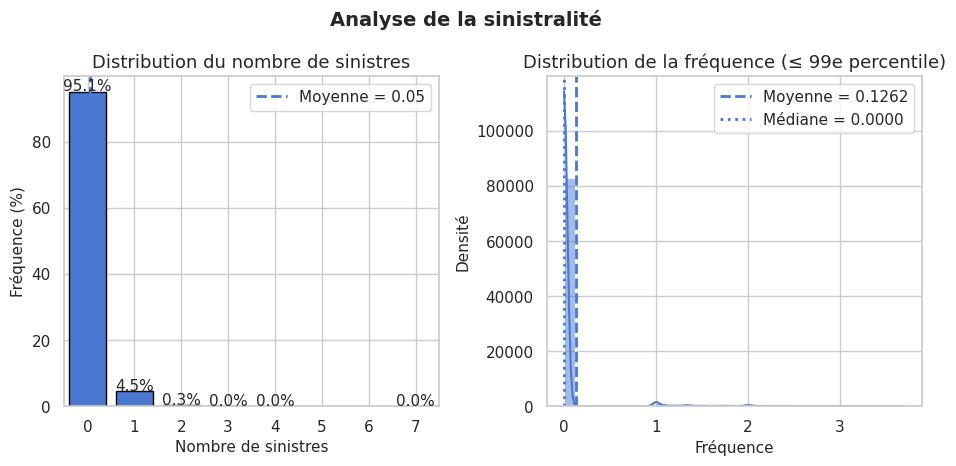

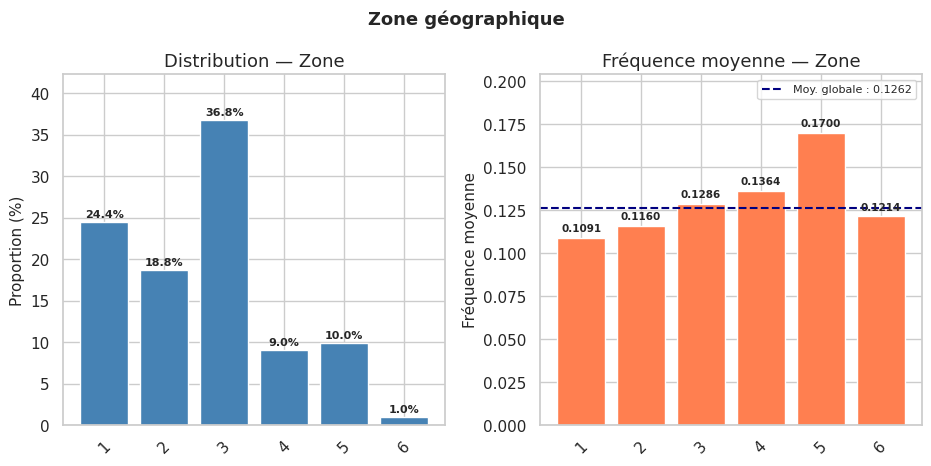

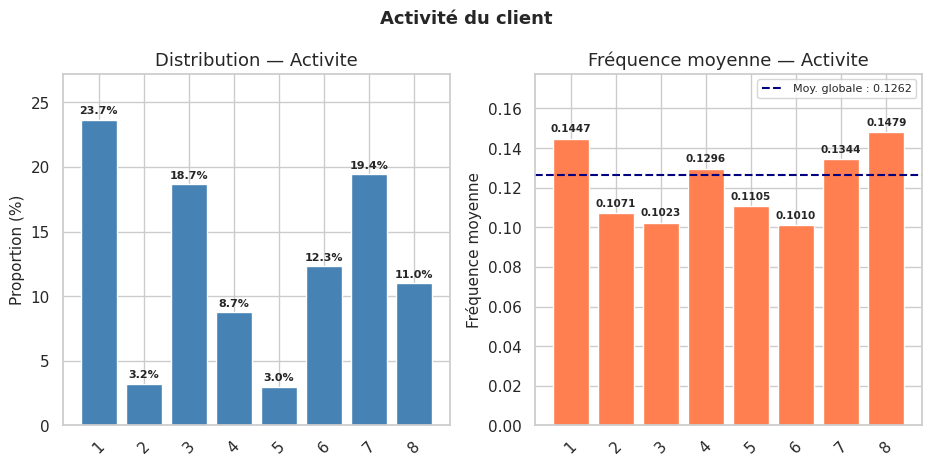

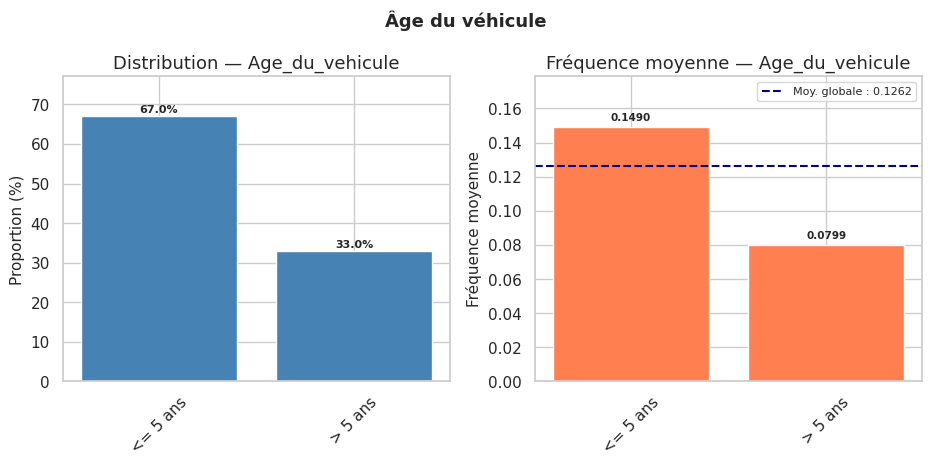

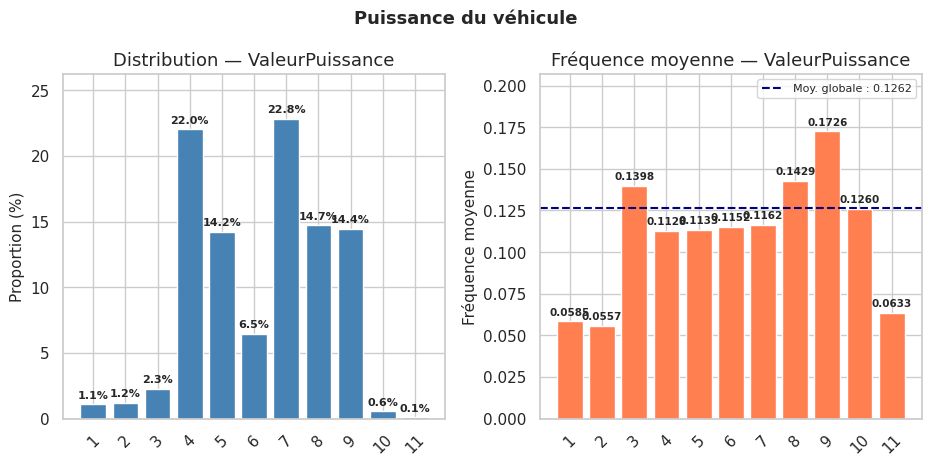

...

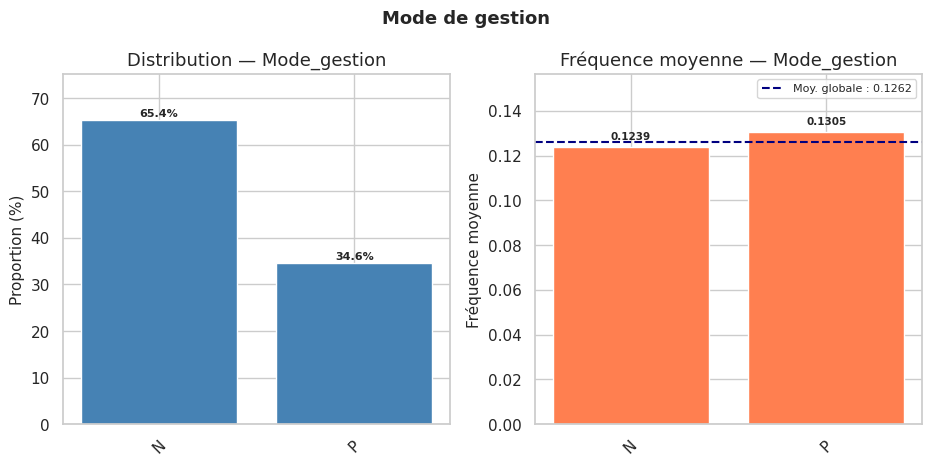

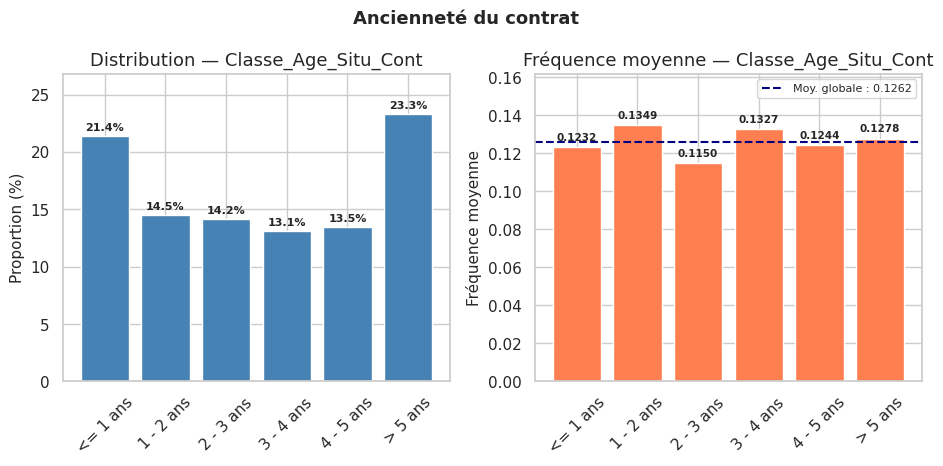

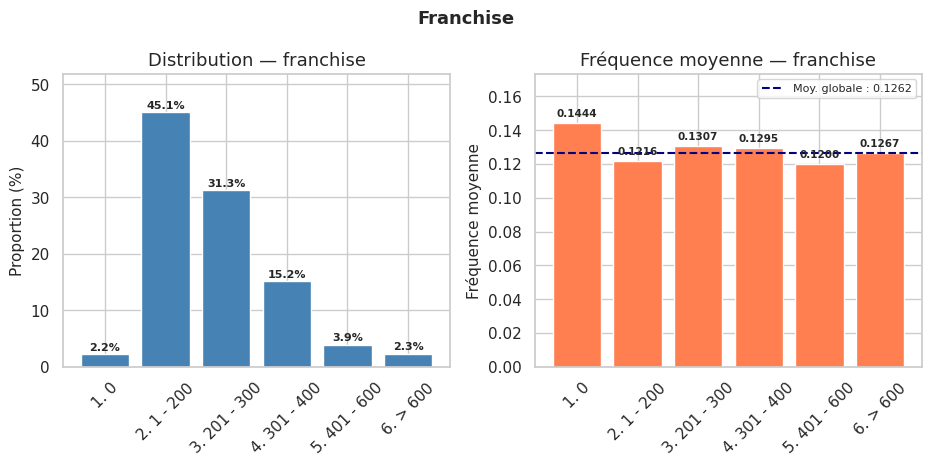

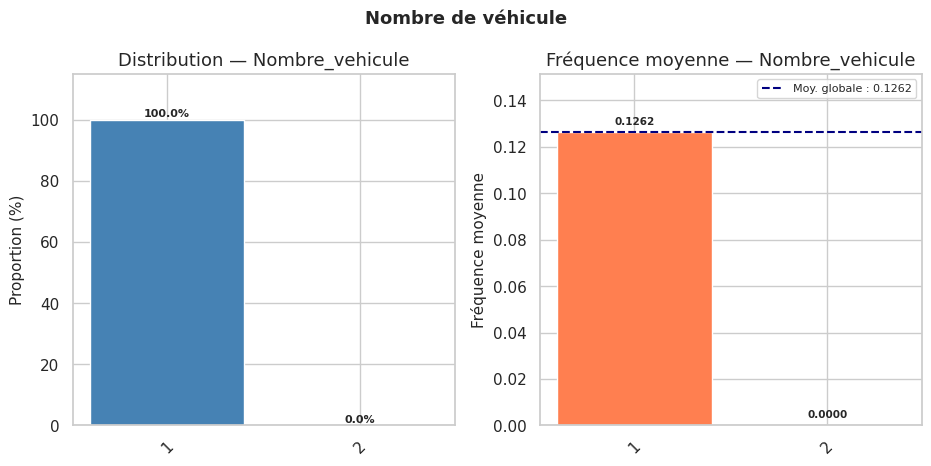

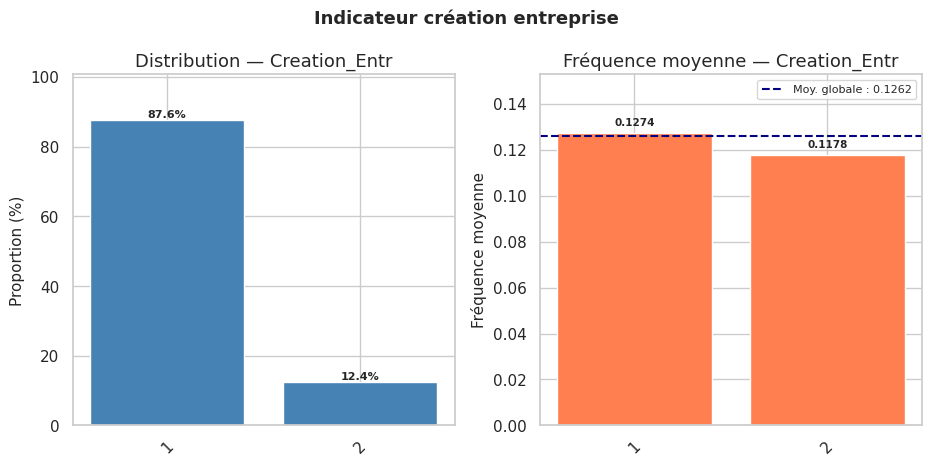

In [ ]:
data = data[data['Exposition_au_risque'] > 0].copy()
data['Frequence'] = data['nombre_de_sinistre'] / data['Exposition_au_risque']

# Référence unique utilisée partout
FREQ_MOYENNE_GLOBALE = data['Frequence'].mean()  # = 0.1262
print(f"  Fréquence globale : {FREQ_MOYENNE_GLOBALE:.4f}")


fig, axes = plt.subplots(1, 2, figsize=(24*cm, 12*cm))

# Graphique 1 : Distribution du nombre de sinistres
vc_sin   = data['nombre_de_sinistre'].value_counts().sort_index()
freq_pct = vc_sin.values / len(data) * 100
axes[0].bar(vc_sin.index, freq_pct, edgecolor='black')
for i, v in enumerate(freq_pct):
    axes[0].text(vc_sin.index[i], v + 0.3, f"{v:.1f}%", ha='center')
axes[0].axvline(data['nombre_de_sinistre'].mean(), linestyle='--', linewidth=2,
                label=f"Moyenne = {data['nombre_de_sinistre'].mean():.2f}")
axes[0].set_title("Distribution du nombre de sinistres")
axes[0].set_xlabel("Nombre de sinistres")
axes[0].set_ylabel("Fréquence (%)")
axes[0].set_xlim(-0.5, min(10, vc_sin.index.max()) + 0.5)
axes[0].legend()

# Graphique 2 : Distribution de la fréquence (≤ 99e percentile)
q99           = data['Frequence'].quantile(0.99)
freq_filtered = data['Frequence'][data['Frequence'] <= q99]

sns.histplot(freq_filtered, bins=30, kde=True, ax=axes[1])

axes[1].axvline(FREQ_MOYENNE_GLOBALE, linestyle='--', linewidth=2,
                label=f"Moyenne = {FREQ_MOYENNE_GLOBALE:.4f}")
axes[1].axvline(freq_filtered.median(), linestyle=':', linewidth=2,
                label=f"Médiane = {freq_filtered.median():.4f}")
axes[1].set_title("Distribution de la fréquence (≤ 99e percentile)")
axes[1].set_xlabel("Fréquence")
axes[1].set_ylabel("Densité")
axes[1].legend()

plt.suptitle("Analyse de la sinistralité", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("target_distribution_clean.png", dpi=300)
plt.show()


def plot_cat_vs_freq(col, title, figsize=(24*cm, 12*cm)):
    if col not in data.columns:
        return
    fig, axes = plt.subplots(1, 2, figsize=figsize)

    prop = data[col].value_counts(normalize=True).sort_index() * 100
    bars = axes[0].bar(prop.index.astype(str), prop.values,
                       color='steelblue', edgecolor='white')
    for bar, val in zip(bars, prop.values):
        axes[0].text(bar.get_x() + bar.get_width()/2,
                     bar.get_height() + 0.3, f"{val:.1f}%",
                     ha='center', va='bottom', fontsize=8, fontweight='bold')
    axes[0].set_ylim(0, prop.values.max() * 1.15)
    axes[0].set_title(f"Distribution — {col}")
    axes[0].set_ylabel("Proportion (%)")
    axes[0].tick_params(axis='x', rotation=45)

    freq_mean = (data.groupby(col)['Frequence']
                     .mean()
                     .sort_index()
                     .reset_index())
    bars2 = axes[1].bar(freq_mean[col].astype(str), freq_mean['Frequence'],
                        color='coral', edgecolor='white')
    # même référence 0.1262 partout
    axes[1].axhline(FREQ_MOYENNE_GLOBALE, color='navy', linestyle='--',
                    linewidth=1.5,
                    label=f"Moy. globale : {FREQ_MOYENNE_GLOBALE:.4f}")
    for bar, val in zip(bars2, freq_mean['Frequence'].values):
        axes[1].text(bar.get_x() + bar.get_width()/2,
                     bar.get_height() + FREQ_MOYENNE_GLOBALE * 0.02,
                     f"{val:.4f}", ha='center', va='bottom',
                     fontsize=7.5, fontweight='bold')
    axes[1].set_ylim(0, freq_mean['Frequence'].max() * 1.20)
    axes[1].set_title(f"Fréquence moyenne — {col}")
    axes[1].set_ylabel("Fréquence moyenne")
    axes[1].tick_params(axis='x', rotation=45)
    axes[1].legend(fontsize=8)

    plt.suptitle(title, fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f"plot_{col}.png", dpi=150)
    plt.show()


for col, title in [
    ('Zone',                 "Zone géographique"),
    ('Activite',             "Activité du client"),
    ('Age_du_vehicule',      "Âge du véhicule"),
    ('ValeurPuissance',      "Puissance du véhicule"),
    ('Fractionnement',       "Fractionnement de la prime"),
    ('FORMULE',              "Formule / Type de contrat"),
    ('Type_Apporteur',       "Type d'apporteur"),
    ('Segment',              "Segment (taille flotte)"),
    ('Mode_gestion',         "Mode de gestion"),
    ('Classe_Age_Situ_Cont', "Ancienneté du contrat"),
    ('franchise',            "Franchise"),
    ('Nombre_vehicule',      "Nombre de véhicule"),
    ('Creation_Entr',        "Indicateur création entreprise"),
]:
    plot_cat_vs_freq(col, title)

## **ANALYSE INFÉRENTIELLE — TEST KHI-DEUX**


  4. TEST KHI-DEUX

  Nombre de variables testées : 13
            Variable   Chi2       p-value  DDL  V de Cramer Significatif
        Mode_gestion 607.03 4.952320e-134    1       0.0834          Oui
     Age_du_vehicule 344.46  6.827005e-77    1       0.0628          Oui
            Activite 152.81  1.042870e-29    7       0.0419          Oui
     ValeurPuissance 140.47  3.372443e-25   10       0.0401          Oui
                Zone 139.24  2.595956e-28    5       0.0400          Oui
      Type_Apporteur  84.18  5.241753e-19    2       0.0311          Oui
Classe_Age_Situ_Cont  43.69  2.673177e-08    5       0.0224          Oui
             FORMULE  41.54  5.019533e-09    3       0.0218          Oui
      Fractionnement  39.27  2.974125e-09    2       0.0212          Oui
           franchise  21.95  5.359831e-04    5       0.0159          Oui
       Creation_Entr  16.26  5.509019e-05    1       0.0137          Oui
             Segment  14.13  1.701857e-04    1       0.0127         

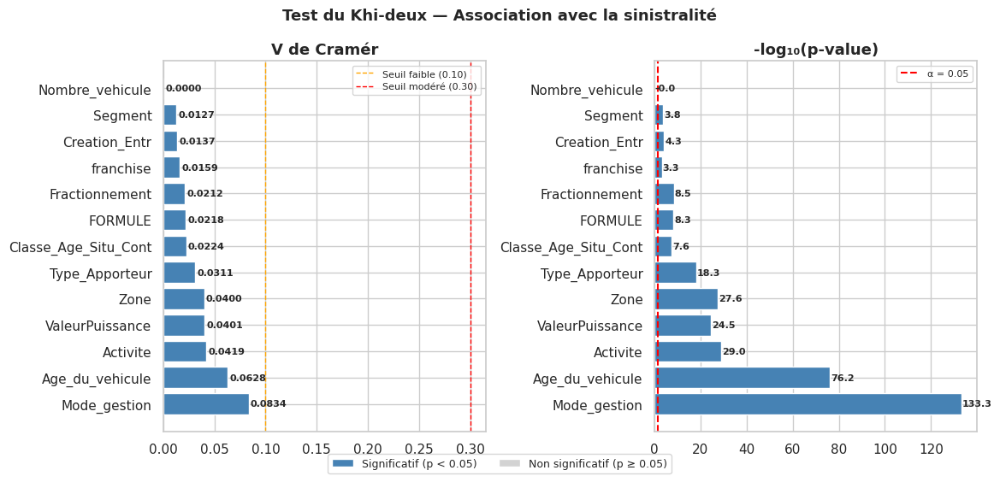

  Mode_gestion              V=0.0834 → FAIBLE  Oui
  Age_du_vehicule           V=0.0628 → FAIBLE  Oui
  Activite                  V=0.0419 → FAIBLE  Oui
  ValeurPuissance           V=0.0401 → FAIBLE  Oui
  Zone                      V=0.0400 → FAIBLE  Oui
  Type_Apporteur            V=0.0311 → FAIBLE  Oui
  Classe_Age_Situ_Cont      V=0.0224 → FAIBLE  Oui
  FORMULE                   V=0.0218 → FAIBLE  Oui
  Fractionnement            V=0.0212 → FAIBLE  Oui
  franchise                 V=0.0159 → FAIBLE  Oui
  Creation_Entr             V=0.0137 → FAIBLE  Oui
  Segment                   V=0.0127 → FAIBLE  Oui
  Nombre_vehicule           V=0.0000 → FAIBLE  Non


In [ ]:

# ══════════════════════════════════════════════════════════════════
# ANALYSE INFÉRENTIELLE — TEST KHI-DEUX
# ══════════════════════════════════════════════════════════════════

print("\n" + "="*60)
print("  4. TEST KHI-DEUX")
print("="*60)

data['Sinistre_flag'] = (data['Frequence'] > 0).astype(int)

cat_vars_khi = [c for c in [
    'Zone', 'Activite', 'Age_du_vehicule', 'Fractionnement', 'FORMULE',
    'Type_Apporteur', 'Mode_gestion', 'Classe_Age_Situ_Cont',
    'franchise', 'Nombre_vehicule', 'Segment', 'ValeurPuissance',
    'Creation_Entr'
] if c in data.columns]

def khi_deux_test(col, target='Sinistre_flag'):
    contingency = pd.crosstab(data[col], data[target])
    chi2, p_value, dof, _ = chi2_contingency(contingency)
    n = contingency.sum().sum()
    k = min(contingency.shape) - 1
    v_cramer = np.sqrt(chi2 / (n * k))
    return chi2, p_value, dof, v_cramer

results_khi = []
for col in cat_vars_khi:
    try:
        chi2, p_val, dof, v_cramer = khi_deux_test(col)
        results_khi.append({'Variable': col, 'Chi2': round(chi2, 2),
                            'p-value': p_val, 'DDL': dof,
                            'V de Cramer': round(v_cramer, 4),
                            'Significatif': 'Oui' if p_val < 0.05 else 'Non'})
    except Exception as e:
        print(f"  Erreur sur {col} : {e}")

results_df = (pd.DataFrame(results_khi)
                .sort_values('V de Cramer', ascending=False)
                .reset_index(drop=True))

print(f"\n  Nombre de variables testées : {len(results_khi)}")
print(results_df.to_string(index=False))

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(30*cm, 14*cm))
colors_khi = ['steelblue' if p < 0.05 else 'lightgray'
               for p in results_df['p-value']]

bars = axes[0].barh(results_df['Variable'], results_df['V de Cramer'],
                    color=colors_khi, edgecolor='white')
for bar, val in zip(bars, results_df['V de Cramer']):
    axes[0].text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
                 f"{val:.4f}", va='center', fontsize=8, fontweight='bold')
axes[0].axvline(x=0.10, color='orange', linestyle='--', linewidth=1,
                label='Seuil faible (0.10)')
axes[0].axvline(x=0.30, color='red',    linestyle='--', linewidth=1,
                label='Seuil modéré (0.30)')
axes[0].set_title("V de Cramér", fontweight='bold')
axes[0].legend(fontsize=8)

log_pval = -np.log10(results_df['p-value'].clip(1e-300))
bars2 = axes[1].barh(results_df['Variable'], log_pval,
                     color=colors_khi, edgecolor='white')
axes[1].axvline(x=1.30, color='red', linestyle='--', linewidth=1.5,
                label='α = 0.05')
axes[1].set_title("-log₁₀(p-value)", fontweight='bold')
axes[1].legend(fontsize=8)
for bar, val in zip(bars2, log_pval):
    axes[1].text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
                 f"{val:.1f}", va='center', fontsize=8, fontweight='bold')

legend_els = [mpatches.Patch(facecolor='steelblue', label='Significatif (p < 0.05)'),
              mpatches.Patch(facecolor='lightgray', label='Non significatif (p ≥ 0.05)')]
fig.legend(handles=legend_els, loc='lower center', ncol=2,
           fontsize=9, frameon=True, bbox_to_anchor=(0.5, -0.02))
plt.suptitle("Test du Khi-deux — Association avec la sinistralité",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("khi_deux_results.png", dpi=150, bbox_inches='tight')
plt.show()

for _, row in results_df.iterrows():
    v = row['V de Cramer']
    force = "FORTE" if v >= 0.30 else ("MODEREE" if v >= 0.10 else "FAIBLE")
    print(f"  {row['Variable']:<25} V={v:.4f} → {force}  {row['Significatif']}")

data.drop(columns=['Sinistre_flag'], inplace=True)

# **REGRESSION DE GLM POISSON**

In [ ]:
# ══════════════════════════════════════════════════════════════════
#  5. OHE + SPLIT 80/20 (commun GLM et NN)
# ══════════════════════════════════════════════════════════════════
print("\n" + "="*60)
print("  5. OHE + SPLIT 80/20")
print("="*60)

ordinal_vars = [c for c in [
    'Classe_Age_Situ_Cont', 'Age_du_vehicule',
    'Segment', 'ValeurPuissance', 'Nombre_vehicule'
] if c in data.columns]

nominal_vars = [c for c in [
    'Mode_gestion', 'Zone', 'Fractionnement', 'franchise',
    'FORMULE', 'Activite', 'Type_Apporteur', 'Creation_Entr'
] if c in data.columns]

# Modalités de référence
# Nominales → modalité avec la plus grande exposition
# Ordinales → première catégorie
references = {}
for col in nominal_vars:
    references[col] = data.groupby(col)['Exposition_au_risque'].sum().idxmax()
for col in ordinal_vars:
    references[col] = data[col].cat.categories[0]

print("\n  Modalités de référence :")
for col, ref in references.items():
    tag = "[NOM]" if col in nominal_vars else "[ORD]"
    print(f"    {tag} {col:<25} → '{ref}'")

all_vars     = ordinal_vars + nominal_vars
all_existing = [c for c in all_vars if c in data.columns]

X_dummies = pd.get_dummies(data[all_existing], drop_first=False, dtype=float)
for col, ref in references.items():
    ref_col = f"{col}_{ref}"
    if ref_col in X_dummies.columns:
        X_dummies.drop(columns=[ref_col], inplace=True)

print(f"\n  Shape X après OHE : {X_dummies.shape}")

# Y_pair = [Fréquence, Exposition] — selon le prof
freq_all  = data['Frequence'].values.astype(float)
expo_all  = data['Exposition_au_risque'].values.astype(float)
Y_pair    = np.stack([freq_all, expo_all], axis=1).astype("float32")

print(f"  Y_pair shape : {Y_pair.shape}")
print(f"  Y[:,0] = Fréquence  — moy. = {freq_all.mean():.4f}")
print(f"  Y[:,1] = Exposition — moy. = {expo_all.mean():.4f}")

# Split 80/20
X_raw = X_dummies.values.astype("float32")
idx   = np.arange(len(data))

(X_train, X_val,
 Y_train, Y_val,
 idx_train, idx_val) = train_test_split(
    X_raw, Y_pair, idx, test_size=0.2, random_state=SEED)

freq_train  = Y_train[:, 0];  freq_val  = Y_val[:, 0]
expo_train  = Y_train[:, 1];  expo_val  = Y_val[:, 1]
freq_moy_tr = np.average(freq_train, weights=expo_train)
freq_moy_va = np.average(freq_val,   weights=expo_val)

print(f"\n  Train : {len(X_train):>7,} obs — fréq. moy. pondérée = {freq_moy_tr:.4f}")
print(f"  Val   : {len(X_val):>7,} obs — fréq. moy. pondérée = {freq_moy_va:.4f}")


# ══════════════════════════════════════════════════════════════════
#  6. GLM POISSON
#     6a. statsmodels — pour résumé complet et interprétation
#     6b. TweedieRegressor sklearn — pour comparaison avec NN
# ══════════════════════════════════════════════════════════════════
print("\n" + "="*60)
print("  6. GLM POISSON")
print("="*60)

# ── 6a. statsmodels — avec offset log(Exposition) ──
log_expo_train = np.log(expo_train)
log_expo_val   = np.log(expo_val)

X_train_sm = sm.add_constant(pd.DataFrame(X_train, columns=X_dummies.columns).astype(float))
X_val_sm   = sm.add_constant(pd.DataFrame(X_val,   columns=X_dummies.columns).astype(float))
X_val_sm   = X_val_sm.reindex(columns=X_train_sm.columns, fill_value=0)

glm_sm = sm.GLM(
    freq_train * expo_train,
    X_train_sm,
    family = sm.families.Poisson(link=sm.families.links.Log()),
    offset = log_expo_train
)
glm_sm_results = glm_sm.fit()
print(glm_sm_results.summary())

# Coefficients interprétables
coef_table = pd.DataFrame({
    'Coefficient': glm_sm_results.params,
    'exp(coef)':   np.exp(glm_sm_results.params),
    'p-value':     glm_sm_results.pvalues
}).round(4)
coef_table['Significatif'] = coef_table['p-value'].apply(
    lambda p: '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else '')))

print("\n── TOP 15 coefficients (|coef| décroissant) ──")
print(coef_table.reindex(
    coef_table['Coefficient'].abs().sort_values(ascending=False).index
).head(15).to_string())


  5. OHE + SPLIT 80/20

  Modalités de référence :
    [NOM] Mode_gestion              → 'P'
    [NOM] Zone                      → '3'
    [NOM] Fractionnement            → 'T'
    [NOM] franchise                 → '2. 1 - 200'
    [NOM] FORMULE                   → '3'
    [NOM] Activite                  → '1'
    [NOM] Type_Apporteur            → '1'
    [NOM] Creation_Entr             → '1'
    [ORD] Classe_Age_Situ_Cont      → '<= 1 ans'
    [ORD] Age_du_vehicule           → '<= 5 ans'
    [ORD] Segment                   → '1'
    [ORD] ValeurPuissance           → '1'
    [ORD] Nombre_vehicule           → '1'

  Shape X après OHE : (87228, 44)
  Y_pair shape : (87228, 2)
  Y[:,0] = Fréquence  — moy. = 0.1262
  Y[:,1] = Exposition — moy. = 0.4418

  Train :  69,782 obs — fréq. moy. pondérée = 0.1202
  Val   :  17,446 obs — fréq. moy. pondérée = 0.1119

  6. GLM POISSON
                 Generalized Linear Model Regression Results                  
Dep. Variable:                      

In [ ]:
glm = TweedieRegressor(power=1, alpha=0.0, link='log', max_iter=500)
glm.fit(X_train, Y_train[:, 0], sample_weight=Y_train[:, 1])

ypred_glm_tr = glm.predict(X_train)
ypred_glm_va = glm.predict(X_val)

md_glm_tr = mean_poisson_deviance(Y_train[:, 0], ypred_glm_tr,
                                   sample_weight=Y_train[:, 1])
md_glm_va = mean_poisson_deviance(Y_val[:, 0],   ypred_glm_va,
                                   sample_weight=Y_val[:, 1])
dev_glm_tr = md_glm_tr * expo_train.sum()
dev_glm_va = md_glm_va * expo_val.sum()

print(f"\n  GLM (sklearn) — intercept : {glm.intercept_:.4f} → exp = {np.exp(glm.intercept_):.4f}")
print(f"\n  ── Entraînement ──")
print(f"  Déviance moyenne train   : {md_glm_tr:.6f}")
print(f"  Déviance totale  train   : {dev_glm_tr:.2f}")
print(f"  Fréq. moy. observée train : {freq_moy_tr:.4f}")  # ← AJOUT
print(f"  Fréq. moy. prédite  train : {np.average(ypred_glm_tr, weights=expo_train):.4f}")  # ← AJOUT
print(f"\n  ── Validation ──")
print(f"  Déviance moyenne val     : {md_glm_va:.6f}")
print(f"  Déviance totale  val     : {dev_glm_va:.2f}")
print(f"  Fréq. moy. observée val  : {freq_moy_va:.4f}")
print(f"  Fréq. moy. prédite  val  : {np.average(ypred_glm_va, weights=expo_val):.4f}")


  GLM (sklearn) — intercept : -1.7734 → exp = 0.1698

  ── Entraînement ──
  Déviance moyenne train   : 0.662716
  Déviance totale  train   : 20448.29
  Fréq. moy. observée train : 0.1202
  Fréq. moy. prédite  train : 0.1203

  ── Validation ──
  Déviance moyenne val     : 0.623126
  Déviance totale  val     : 4787.44
  Fréq. moy. observée val  : 0.1119
  Fréq. moy. prédite  val  : 0.1199


# **RESEAUX DE NEURONNES**


  7. RÉSEAUX DE NEURONES
  Dimension input : 44  (variables OHE, valeurs 0/1)

  Entraînement : NN1_Simple
  Epochs : 97
  Dev. moy. train : 0.655805  |  val : 0.625415
  Fréq. prédite val : 0.1289  (obs: 0.1119)

  Entraînement : NN2_L2_Dropout
  Epochs : 107
  Dev. moy. train : 0.652183  |  val : 0.625668
  Fréq. prédite val : 0.1282  (obs: 0.1119)

  Entraînement : NN3_Deep
  Epochs : 102
  Dev. moy. train : 0.647285  |  val : 0.626481
  Fréq. prédite val : 0.1341  (obs: 0.1119)

  Entraînement : NN4_Tanh_L1L2
  Epochs : 117
  Dev. moy. train : 0.660596  |  val : 0.622334
  Fréq. prédite val : 0.1134  (obs: 0.1119)


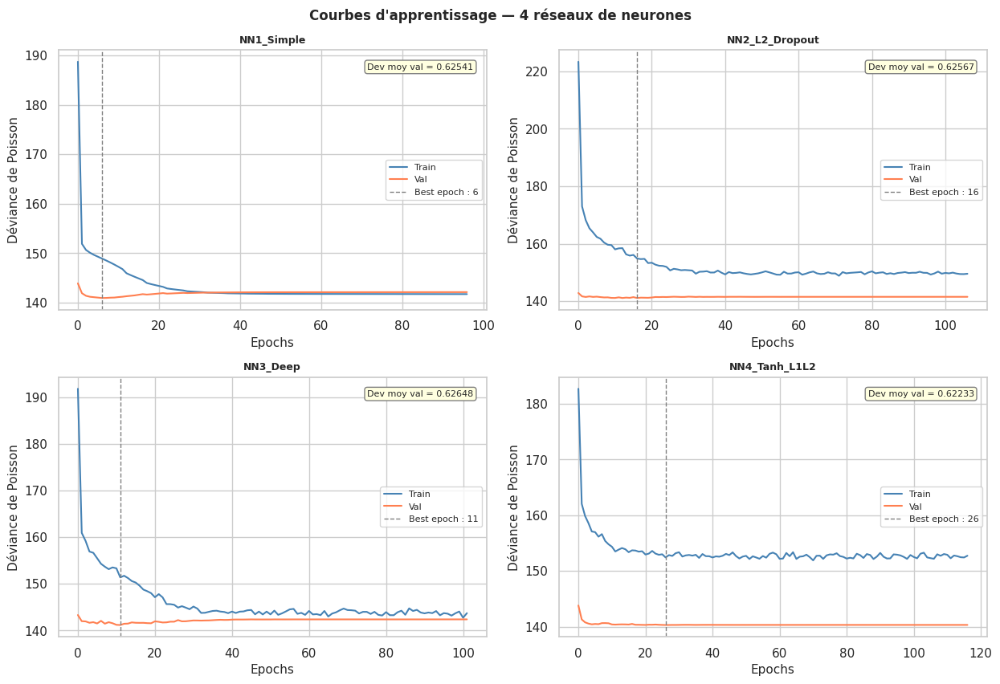


  TABLEAU COMPARATIF — GLM + 4 NN  (trié par Dev_Moy_Val ↑)
        Modele  Dev_Moy_Train  Dev_Moy_Val  Dev_Tot_Train  Dev_Tot_Val
 NN4_Tanh_L1L2       0.660596     0.622334   20382.902344  4781.364258
   GLM_Poisson       0.662716     0.623126   20448.292969  4787.442383
    NN1_Simple       0.655805     0.625415   20235.070312  4805.030762
NN2_L2_Dropout       0.652183     0.625668   20123.316406  4806.974121
      NN3_Deep       0.647285     0.626481   19972.162109  4813.226074

 Meilleur NN : NN4_Tanh_L1L2


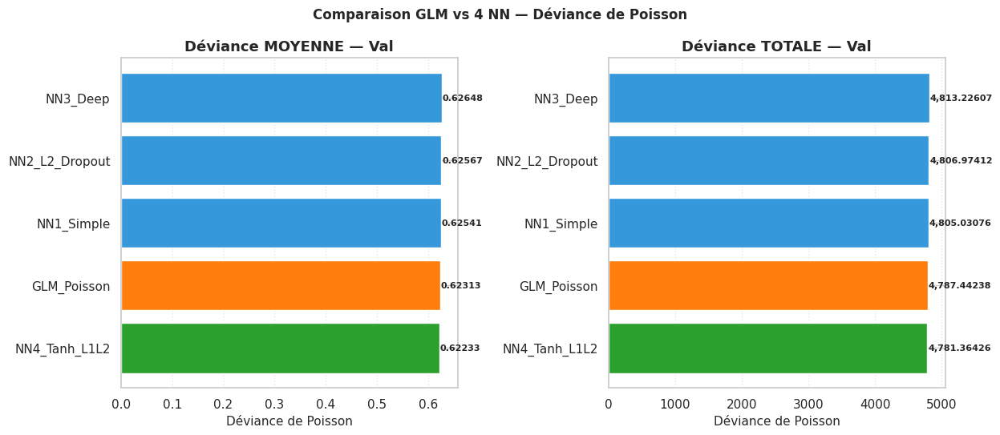

In [ ]:

# ══════════════════════════════════════════════════════════════════
#  7. RÉSEAUX DE NEURONES
# ══════════════════════════════════════════════════════════════════
print("\n" + "="*60)
print("  7. RÉSEAUX DE NEURONES")
print("="*60)

# ── Loss custom — Déviance de Poisson (code exact du prof) ──
def Poisson_deviance_loss(y_true, y_pred):
    """
    y_true[:,0] = fréquence observée
    y_true[:,1] = exposition (offset)
    y_pred      = fréquence prédite (1 neurone sortie)
    """
    y    = y_true[:, 0]
    e    = y_true[:, 1]
    yhat = y_pred[:, 0]

    lny  = keras.ops.log(y)
    lny  = keras.ops.where(keras.ops.equal(y, 0),
                            keras.ops.zeros_like(y), lny)

    lnyhat = keras.ops.log(yhat)
    lnyhat = keras.ops.where(keras.ops.less_equal(yhat, 0),
                              keras.ops.zeros_like(yhat), lnyhat)

    devia = keras.ops.sum(2 * e * (y * lny - y * lnyhat - y + yhat))
    return devia


INPUT_DIM = X_train.shape[1]
print(f"  Dimension input : {INPUT_DIM}  (variables OHE, valeurs 0/1)")

def build_nn1(input_dim):
    """NN1 — Simple [64→32→16] ReLU, sans régularisation. Baseline."""
    return keras.Sequential([
        keras.Input(shape=(input_dim,)),
        layers.Dense(64, activation="relu"),
        layers.Dense(32, activation="relu"),
        layers.Dense(16, activation="relu"),
        layers.Dense(1,  activation="exponential")
    ], name="NN1_Simple")


def build_nn2(input_dim):
    """NN2 — [64→32→16] ReLU + L2 + Dropout(0.3)."""
    return keras.Sequential([
        keras.Input(shape=(input_dim,)),
        layers.Dense(64, activation="relu",
                     kernel_regularizer=regularizers.l2(1e-3)),
        layers.Dropout(0.3),
        layers.Dense(32, activation="relu",
                     kernel_regularizer=regularizers.l2(1e-3)),
        layers.Dropout(0.3),
        layers.Dense(16, activation="relu",
                     kernel_regularizer=regularizers.l2(1e-3)),
        layers.Dropout(0.3),
        layers.Dense(1,  activation="exponential")
    ], name="NN2_L2_Dropout")


def build_nn3(input_dim):
    """NN3 — Profonde [128→64→32→16] + Dropout."""
    return keras.Sequential([
        keras.Input(shape=(input_dim,)),
        layers.Dense(128, activation="relu"),
        layers.Dropout(0.2),
        layers.Dense(64,  activation="relu"),
        layers.Dropout(0.2),
        layers.Dense(32,  activation="relu"),
        layers.Dropout(0.2),
        layers.Dense(16,  activation="relu"),
        layers.Dropout(0.2),
        layers.Dense(1,   activation="exponential")
    ], name="NN3_Deep")


def build_nn4(input_dim):
    return keras.Sequential([
        keras.Input(shape=(input_dim,)),
        layers.Dense(64, activation="tanh",
                     kernel_regularizer=regularizers.l1_l2(l1=1e-4, l2=1e-4)),
        layers.Dense(32, activation="tanh",
                     kernel_regularizer=regularizers.l1_l2(l1=1e-4, l2=1e-4)),
        layers.Dropout(0.3),
        layers.Dense(16, activation="tanh"),
        layers.Dropout(0.3),
        layers.Dense(1,  activation="exponential")
    ], name="NN4_Tanh_L1L2")


def make_callbacks():
    return [
        EarlyStopping(monitor='val_loss', patience=90,
                      restore_best_weights=True, verbose=0),
        ReduceLROnPlateau(monitor='val_loss', patience=5,
                          factor=0.5, min_lr=1e-6, verbose=0)
    ]


builders  = [build_nn1, build_nn2, build_nn3, build_nn4]
nn_names  = ["NN1_Simple", "NN2_L2_Dropout", "NN3_Deep", "NN4_Tanh_L1L2"]
results_nn = []
histories  = {}

for name, builder in zip(nn_names, builders):
    print(f"\n{'='*50}\n  Entraînement : {name}\n{'='*50}")
    model = builder(INPUT_DIM)
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=8e-4),
                  loss=Poisson_deviance_loss)
    history = model.fit(X_train, Y_train,
                        validation_data=(X_val, Y_val),
                        epochs=300, batch_size=512,
                        callbacks=make_callbacks(), verbose=0)
    histories[name] = history

    pred_tr = model.predict(X_train, verbose=0).ravel()
    pred_va = model.predict(X_val,   verbose=0).ravel()

    md_nn_tr = mean_poisson_deviance(freq_train, pred_tr, sample_weight=expo_train)
    md_nn_va = mean_poisson_deviance(freq_val,   pred_va, sample_weight=expo_val)

    print(f"  Epochs : {len(history.history['loss'])}")
    print(f"  Dev. moy. train : {md_nn_tr:.6f}  |  val : {md_nn_va:.6f}")
    print(f"  Fréq. prédite val : {np.average(pred_va, weights=expo_val):.4f}"
          f"  (obs: {freq_moy_va:.4f})")

    results_nn.append({
        'Modele': name,
        'md_tr': md_nn_tr, 'md_va': md_nn_va,
        'dev_tr': md_nn_tr * expo_train.sum(),
        'dev_va': md_nn_va * expo_val.sum(),
        'pred_tr': pred_tr, 'pred_va': pred_va,
        'model': model,
    })

# ── Courbes d'apprentissage ──
fig, axes = plt.subplots(2, 2, figsize=(32*cm, 22*cm))
axes = axes.ravel()
for i, r in enumerate(results_nn):
    ax   = axes[i]
    hist = histories[r['Modele']]
    ax.plot(hist.history['loss'],     color='steelblue', linewidth=1.5, label='Train')
    ax.plot(hist.history['val_loss'], color='coral',     linewidth=1.5, label='Val')
    best_ep = int(np.argmin(hist.history['val_loss']))
    ax.axvline(x=best_ep, color='gray', linestyle='--', linewidth=1,
               label=f'Best epoch : {best_ep}')
    ax.set_title(r['Modele'], fontweight='bold', fontsize=9)
    ax.set_xlabel("Epochs"); ax.set_ylabel("Déviance de Poisson")
    ax.legend(fontsize=8)
    ax.annotate(f"Dev moy val = {r['md_va']:.5f}",
                xy=(0.97, 0.95), xycoords='axes fraction',
                ha='right', va='top', fontsize=8,
                bbox=dict(boxstyle='round', fc='lightyellow', ec='gray'))
plt.suptitle("Courbes d'apprentissage — 4 réseaux de neurones",
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig("learning_curves.png", dpi=150)
plt.show()

# ── Tableau comparatif GLM + 4 NN ──
rows_sum = [{'Modele': 'GLM_Poisson',
              'Dev_Moy_Train': md_glm_tr, 'Dev_Moy_Val': md_glm_va,
              'Dev_Tot_Train': dev_glm_tr, 'Dev_Tot_Val': dev_glm_va}]
for r in results_nn:
    rows_sum.append({'Modele': r['Modele'],
                     'Dev_Moy_Train': r['md_tr'], 'Dev_Moy_Val': r['md_va'],
                     'Dev_Tot_Train': r['dev_tr'], 'Dev_Tot_Val': r['dev_va']})

summary_df = (pd.DataFrame(rows_sum)
                .sort_values('Dev_Moy_Val')
                .reset_index(drop=True))

print("\n" + "="*70)
print("  TABLEAU COMPARATIF — GLM + 4 NN  (trié par Dev_Moy_Val ↑)")
print("="*70)
print(summary_df.to_string(index=False))

best_nn = min(results_nn, key=lambda r: r['md_va'])
print(f"\n Meilleur NN : {best_nn['Modele']}")


# ── Graphique déviances comparées ──
fig, axes = plt.subplots(1, 2, figsize=(32*cm, 14*cm))
palette_sum = ['#ff7f0e' if m == 'GLM_Poisson' else
               ('#2ca02c' if m == best_nn['Modele'] else '#3498db')
               for m in summary_df['Modele']]

for ax, col_nm, title_nm in zip(
    axes,
    ['Dev_Moy_Val', 'Dev_Tot_Val'],
    ['Déviance MOYENNE — Val', 'Déviance TOTALE — Val']
):
    bars = ax.barh(summary_df['Modele'], summary_df[col_nm],
                   color=palette_sum, edgecolor='white')
    for bar, val in zip(bars, summary_df[col_nm]):
        ax.text(bar.get_width() * 1.002,
                bar.get_y() + bar.get_height()/2,
                f"{val:,.5f}", va='center', fontsize=8, fontweight='bold')
    ax.set_title(title_nm, fontweight='bold')
    ax.set_xlabel("Déviance de Poisson")
    ax.xaxis.grid(True, linestyle=':', alpha=0.5)
    ax.set_axisbelow(True)

plt.suptitle("Comparaison GLM vs 4 NN — Déviance de Poisson",
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig("deviance_comparison.png", dpi=150)
plt.show()

### **Comparaison des sous groupes**


  8. SECTION 1.1 — COMPARAISON PAR SOUS-GROUPES


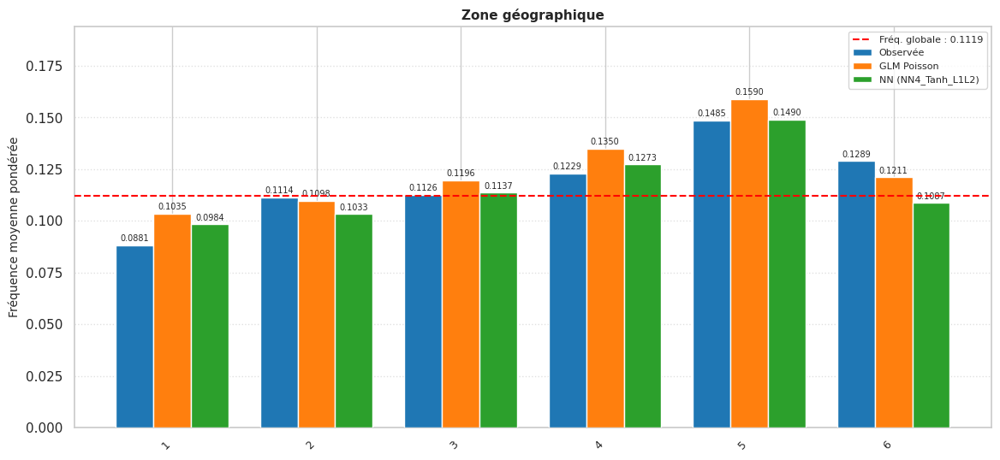

  subgroup_Zone.png


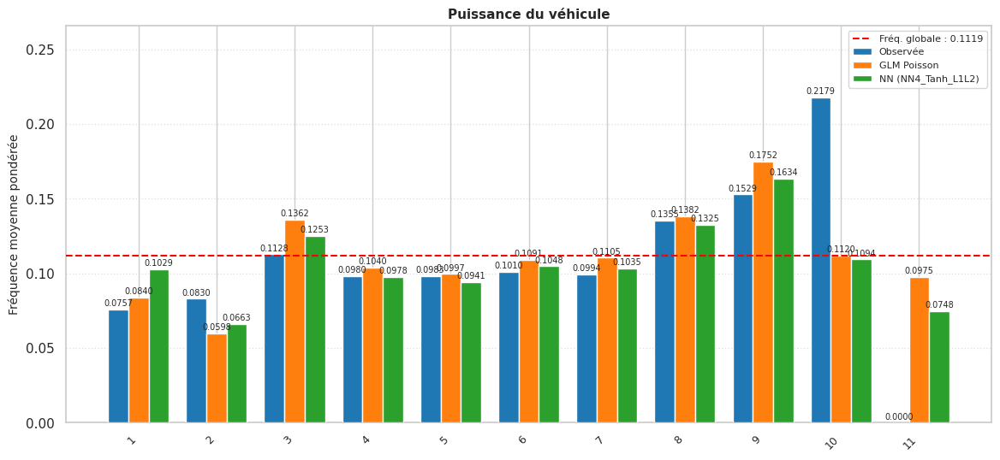

  subgroup_ValeurPuissance.png


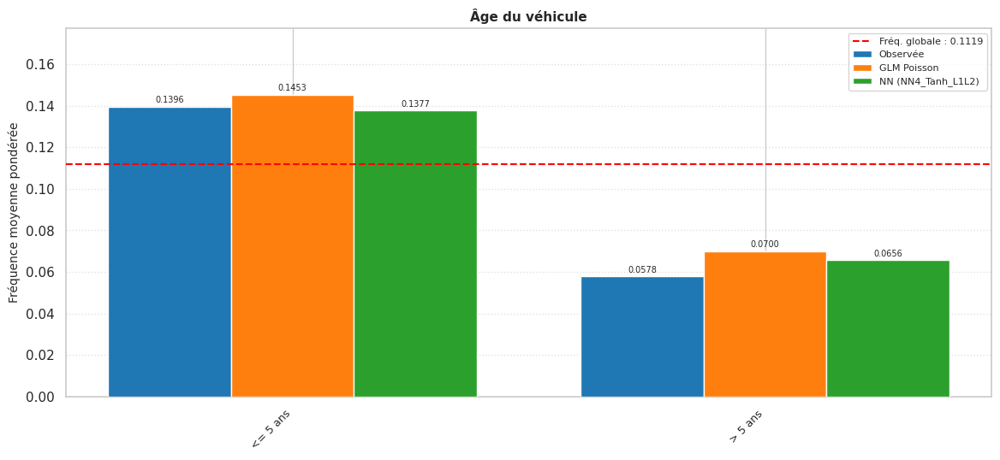

  subgroup_Age_du_vehicule.png


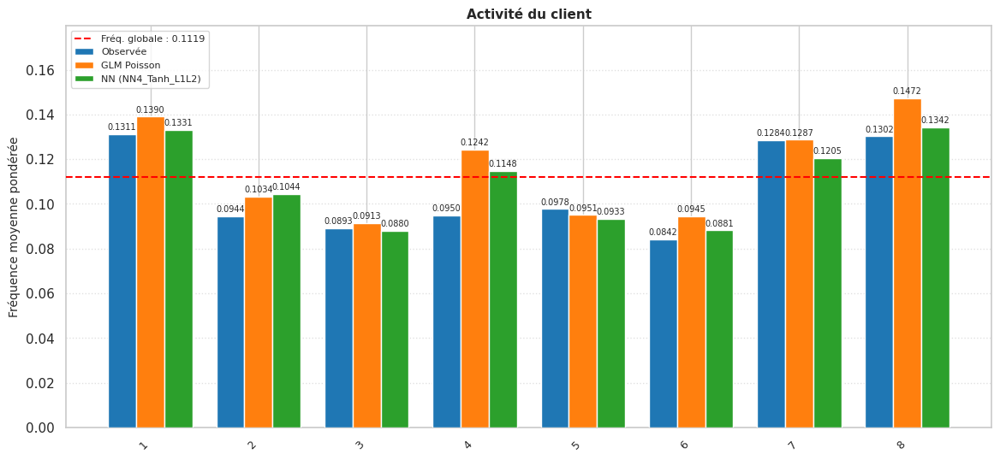

  subgroup_Activite.png


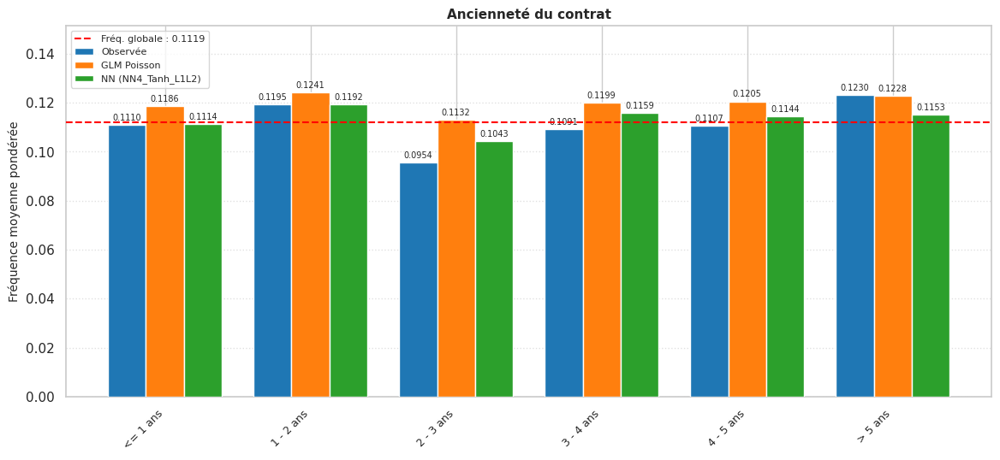

  subgroup_Classe_Age_Situ_Cont.png


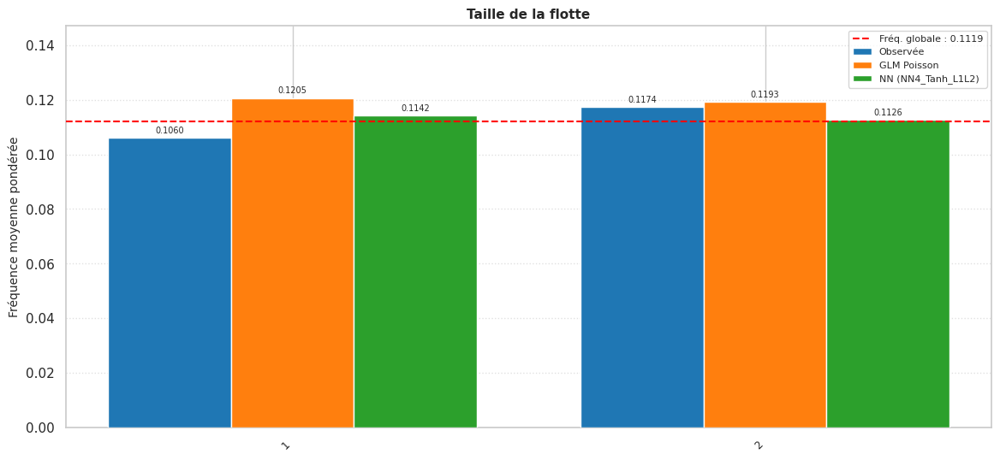

  subgroup_Segment.png


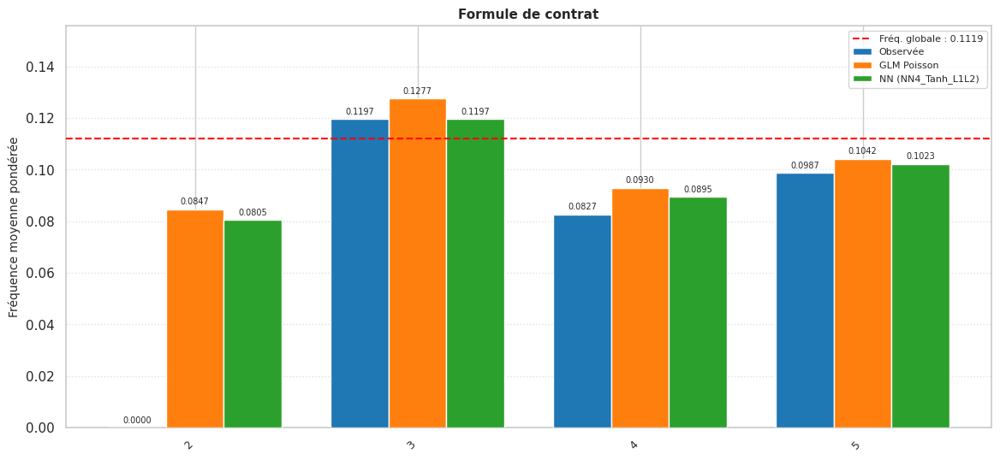

  subgroup_FORMULE.png


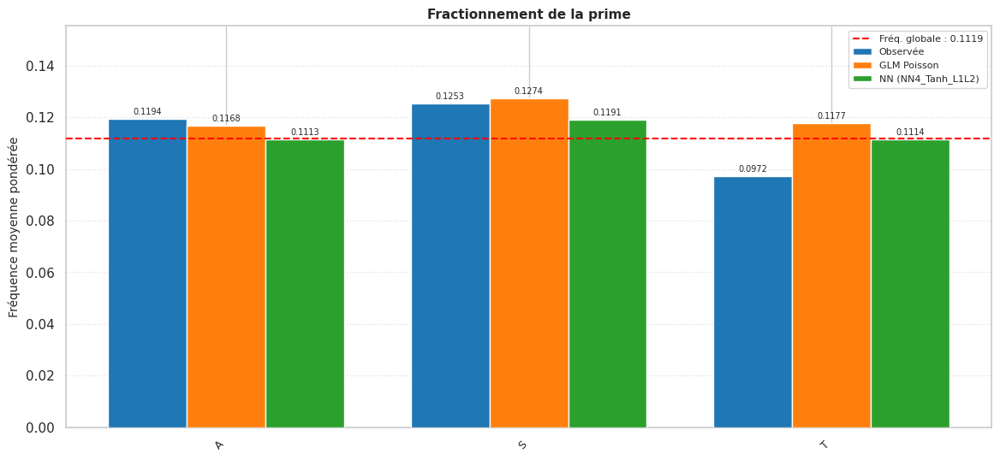

  subgroup_Fractionnement.png


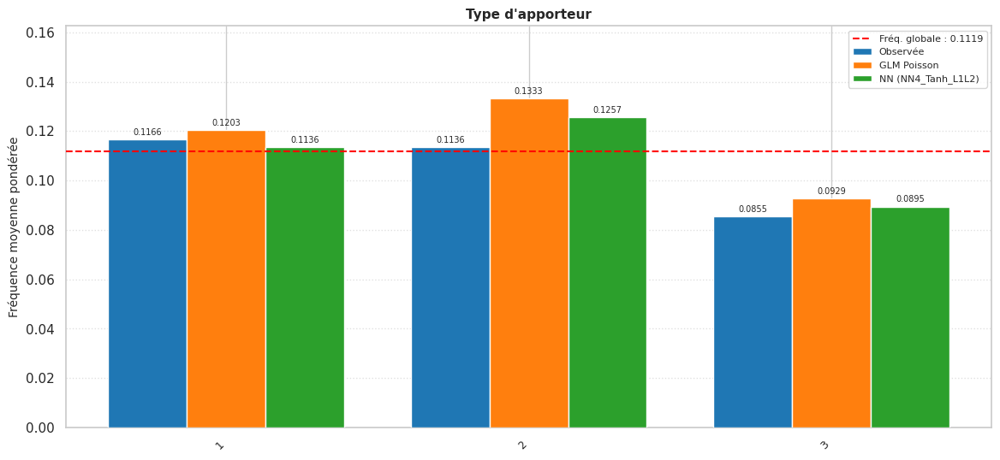

  subgroup_Type_Apporteur.png
  1_1_subgroups_GLM.png
  1_1_subgroups_NN.png


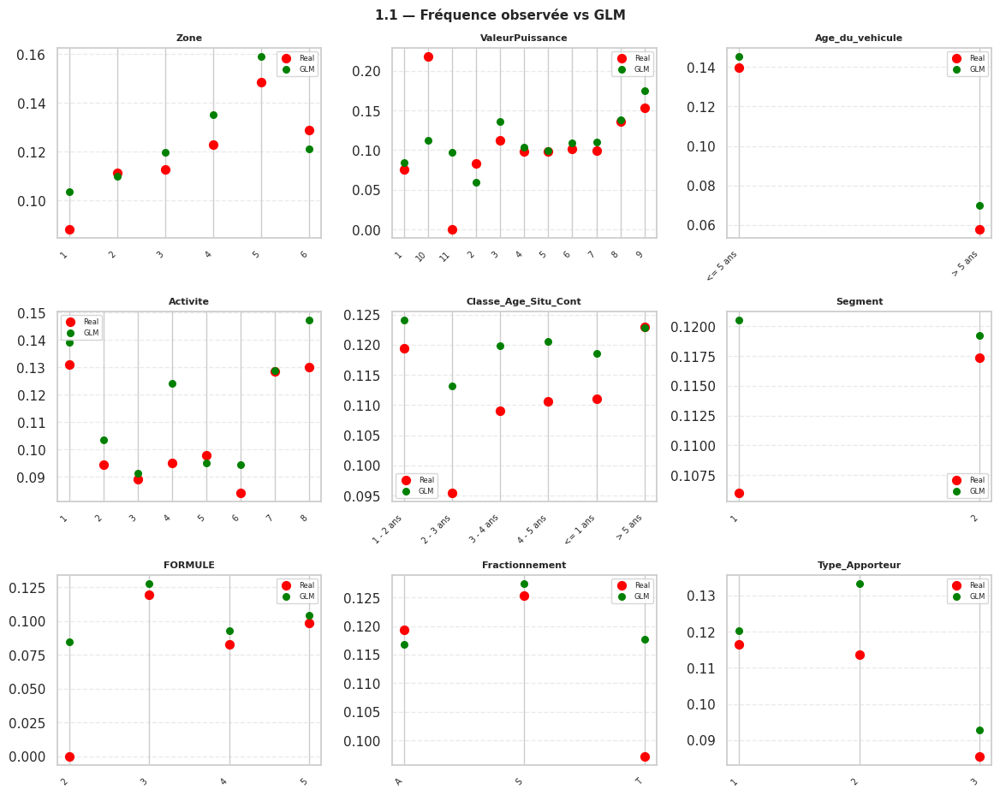

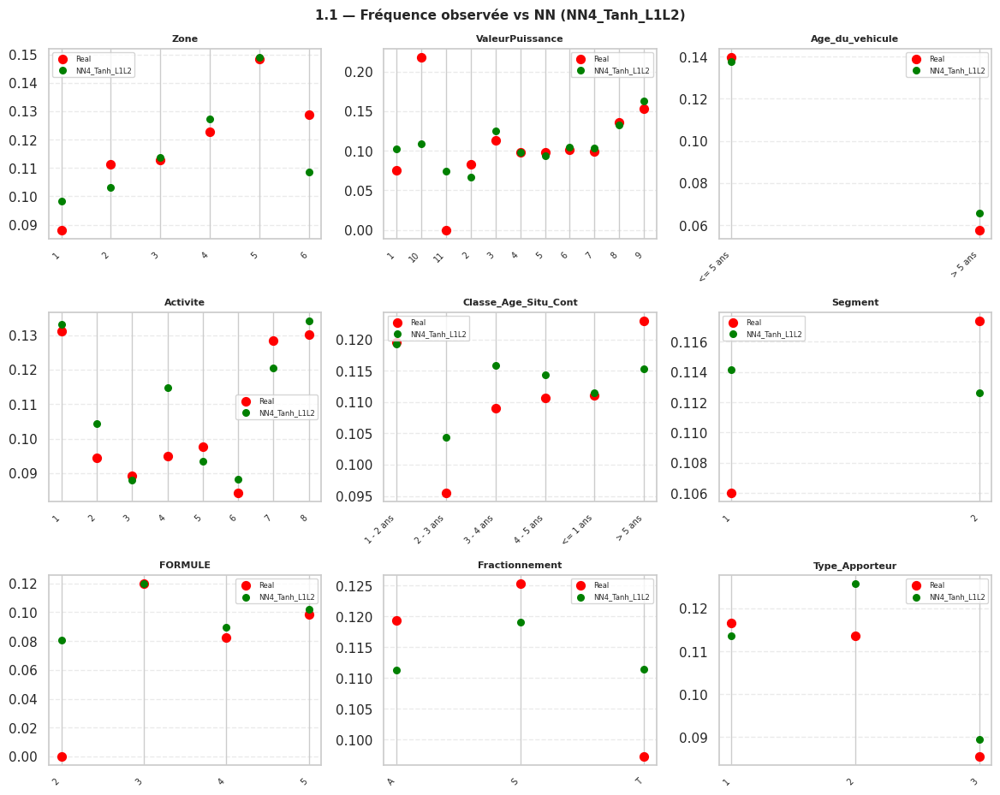

In [ ]:

# ══════════════════════════════════════════════════════════════════
#  8. COMPARAISON PAR SOUS-GROUPES (Section 1.1)
# ══════════════════════════════════════════════════════════════════
print("\n" + "="*60)
print("  8. SECTION 1.1 — COMPARAISON PAR SOUS-GROUPES")
print("="*60)

val_df = data.iloc[idx_val].copy().reset_index(drop=True)
val_df['Freq_Obs'] = freq_val
val_df['Freq_GLM'] = ypred_glm_va
val_df['Freq_NN']  = best_nn['pred_va']

model_names = ['GLM'] + [r['Modele'] for r in results_nn]
model_cols  = ['Freq_GLM'] + [f"Freq_{r['Modele']}" for r in results_nn]
for r in results_nn:
    val_df[f"Freq_{r['Modele']}"] = r['pred_va']

freq_glob = np.average(freq_val, weights=expo_val)

def wavg(s, w):
    w = np.asarray(w, float); s = np.asarray(s, float)
    return np.average(s, weights=w) if w.sum() > 0 else np.nan


def compare_subgroup(col, title, figsize=(30*cm, 14*cm)):
    if col not in val_df.columns:
        return
    tab = (val_df.groupby(col, observed=True)
                 .apply(lambda g: pd.Series({
                     'Observée': wavg(g['Freq_Obs'], g['Exposition_au_risque']),
                     'GLM'     : wavg(g['Freq_GLM'], g['Exposition_au_risque']),
                     'NN'      : wavg(g['Freq_NN'],  g['Exposition_au_risque']),
                     'Expo'    : g['Exposition_au_risque'].sum(),
                 })).reset_index())

    labels = tab[col].astype(str).tolist()
    x = np.arange(len(labels)); w = 0.26

    fig, ax = plt.subplots(figsize=figsize)
    b1 = ax.bar(x - w, tab['Observée'], width=w, color='#1f77b4',
                edgecolor='white', label='Observée',     zorder=3)
    b2 = ax.bar(x,     tab['GLM'],      width=w, color='#ff7f0e',
                edgecolor='white', label='GLM Poisson', zorder=3)
    b3 = ax.bar(x + w, tab['NN'],       width=w, color='#2ca02c',
                edgecolor='white', label=f'NN ({best_nn["Modele"]})', zorder=3)

    for bars_set in (b1, b2, b3):
        for bar in bars_set:
            h = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2,
                    h + freq_glob * 0.01, f"{h:.4f}",
                    ha='center', va='bottom', fontsize=7)

    ax.axhline(y=freq_glob, color='red', linestyle='--', linewidth=1.5,
               zorder=5, label=f'Fréq. globale : {freq_glob:.4f}')
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=9)
    ax.set_ylabel("Fréquence moyenne pondérée", fontsize=10)
    ax.set_title(title, fontweight='bold', fontsize=11)
    ax.legend(fontsize=8)
    ax.set_ylim(0, tab[['Observée','GLM','NN']].values.max() * 1.22)
    ax.yaxis.grid(True, linestyle=':', alpha=0.6)
    ax.set_axisbelow(True)
    plt.tight_layout()
    plt.savefig(f"subgroup_{col}.png", dpi=150)
    plt.show()
    print(f"  subgroup_{col}.png")


sous_groupes = {
    'Zone': "Zone géographique", 'ValeurPuissance': "Puissance du véhicule",
    'Age_du_vehicule': "Âge du véhicule", 'Activite': "Activité du client",
    'Classe_Age_Situ_Cont': "Ancienneté du contrat",
    'Segment': "Taille de la flotte", 'FORMULE': "Formule de contrat",
    'Fractionnement': "Fractionnement de la prime",
    'Type_Apporteur': "Type d'apporteur",
}

for col, title in sous_groupes.items():
    compare_subgroup(col, title)

def wavg(s, w):
    w = np.asarray(w, float); s = np.asarray(s, float)
    return np.average(s, weights=w) if w.sum() > 0 else np.nan

def compare_subgroup_scatter(col, ax_glm, ax_nn):
    if col not in val_df.columns:
        return
    tmp = val_df.copy(); tmp[col] = tmp[col].astype(str)
    tab = (tmp.groupby(col, observed=True)
              .apply(lambda g: pd.Series({
                  'Observée': wavg(g['Freq_Obs'], g['Exposition_au_risque']),
                  'GLM'     : wavg(g['Freq_GLM'], g['Exposition_au_risque']),
                  'NN'      : wavg(g['Freq_NN'],  g['Exposition_au_risque']),
              })).reset_index())
    labels = tab[col].astype(str).tolist()
    x      = np.arange(len(labels))

    ax_glm.scatter(x, tab['Observée'], color='red',   s=50, zorder=4, label='Real')
    ax_glm.scatter(x, tab['GLM'],      color='green', s=30, zorder=4, label='GLM')
    ax_glm.set_xticks(x); ax_glm.set_xticklabels(labels, rotation=45,
                                                   ha='right', fontsize=7)
    ax_glm.set_title(col, fontsize=8, fontweight='bold')
    ax_glm.legend(fontsize=6); ax_glm.yaxis.grid(True, linestyle='--', alpha=0.4)
    ax_glm.set_axisbelow(True)

    ax_nn.scatter(x, tab['Observée'], color='red',   s=50, zorder=4, label='Real')
    ax_nn.scatter(x, tab['NN'],       color='green', s=30, zorder=4,
                  label=best_nn['Modele'])
    ax_nn.set_xticks(x); ax_nn.set_xticklabels(labels, rotation=45,
                                                 ha='right', fontsize=7)
    ax_nn.set_title(col, fontsize=8, fontweight='bold')
    ax_nn.legend(fontsize=6); ax_nn.yaxis.grid(True, linestyle='--', alpha=0.4)
    ax_nn.set_axisbelow(True)


cols_ok = [c for c in sous_groupes if c in val_df.columns]
n       = len(cols_ok); ncols_sg = 3; nrows_sg = int(np.ceil(n / ncols_sg))

fig_glm, axes_glm = plt.subplots(nrows_sg, ncols_sg,
                                   figsize=(ncols_sg*10*cm, nrows_sg*8*cm))
fig_nn,  axes_nn  = plt.subplots(nrows_sg, ncols_sg,
                                   figsize=(ncols_sg*10*cm, nrows_sg*8*cm))
axes_glm = np.array(axes_glm).ravel()
axes_nn  = np.array(axes_nn).ravel()

for i, col in enumerate(cols_ok):
    compare_subgroup_scatter(col, axes_glm[i], axes_nn[i])
for j in range(len(cols_ok), len(axes_glm)):
    axes_glm[j].set_visible(False); axes_nn[j].set_visible(False)

fig_glm.suptitle("1.1 — Fréquence observée vs GLM", fontsize=11, fontweight='bold')
fig_glm.tight_layout(); fig_glm.savefig("1_1_subgroups_GLM.png", dpi=150)
fig_glm.show(); print("  1_1_subgroups_GLM.png")

fig_nn.suptitle(f"1.1 — Fréquence observée vs NN ({best_nn['Modele']})",
                fontsize=11, fontweight='bold')
fig_nn.tight_layout(); fig_nn.savefig("1_1_subgroups_NN.png", dpi=150)
fig_nn.show(); print("  1_1_subgroups_NN.png")



### **AJUSTEMENT DU BIAIS — BALANCE PROPERTY**


  9. AJUSTEMENT DU BIAIS — BALANCE PROPERTY

  Calibration 'Classe_Age_Situ_Cont' :
    GLM : {'<= 1 ans': '0.936', '1 - 2 ans': '0.963', '2 - 3 ans': '0.843', '3 - 4 ans': '0.910', '4 - 5 ans': '0.918', '> 5 ans': '1.002'}
    NN  : {'<= 1 ans': '0.997', '1 - 2 ans': '1.002', '2 - 3 ans': '0.915', '3 - 4 ans': '0.941', '4 - 5 ans': '0.968', '> 5 ans': '1.067'}

  Calibration 'Creation_Entr' :
    GLM : {1: '0.977', 2: '1.141'}
    NN  : {1: '0.981', 2: '1.114'}

  Calibration 'Mode_gestion' :
    GLM : {'N': '0.983', 'P': '1.015'}
    NN  : {'N': '0.990', 'P': '1.009'}

  Calibration 'Zone' :
    GLM : {1: '0.911', 2: '1.087', 3: '1.012', 4: '0.974', 5: '0.996', 6: '1.138'}
    NN  : {1: '0.906', 2: '1.092', 3: '1.005', 4: '0.977', 5: '1.007', 6: '1.202'}

  Calibration 'Segment' :
    GLM : {1: '0.950', 2: '1.046'}
    NN  : {1: '0.945', 2: '1.051'}

  Calibration 'Fractionnement' :
    GLM : {'A': '1.091', 'S': '1.041', 'T': '0.894'}
    NN  : {'A': '1.083', 'S': '1.054', 'T': '0.8

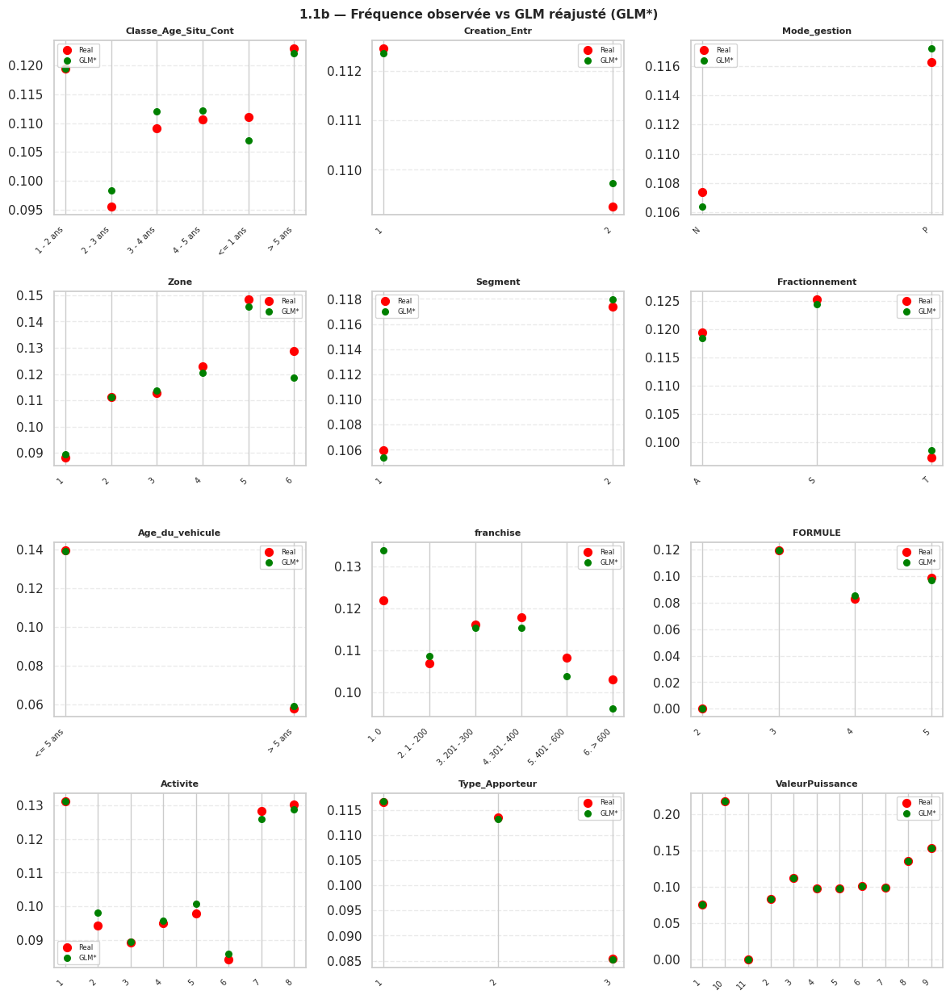

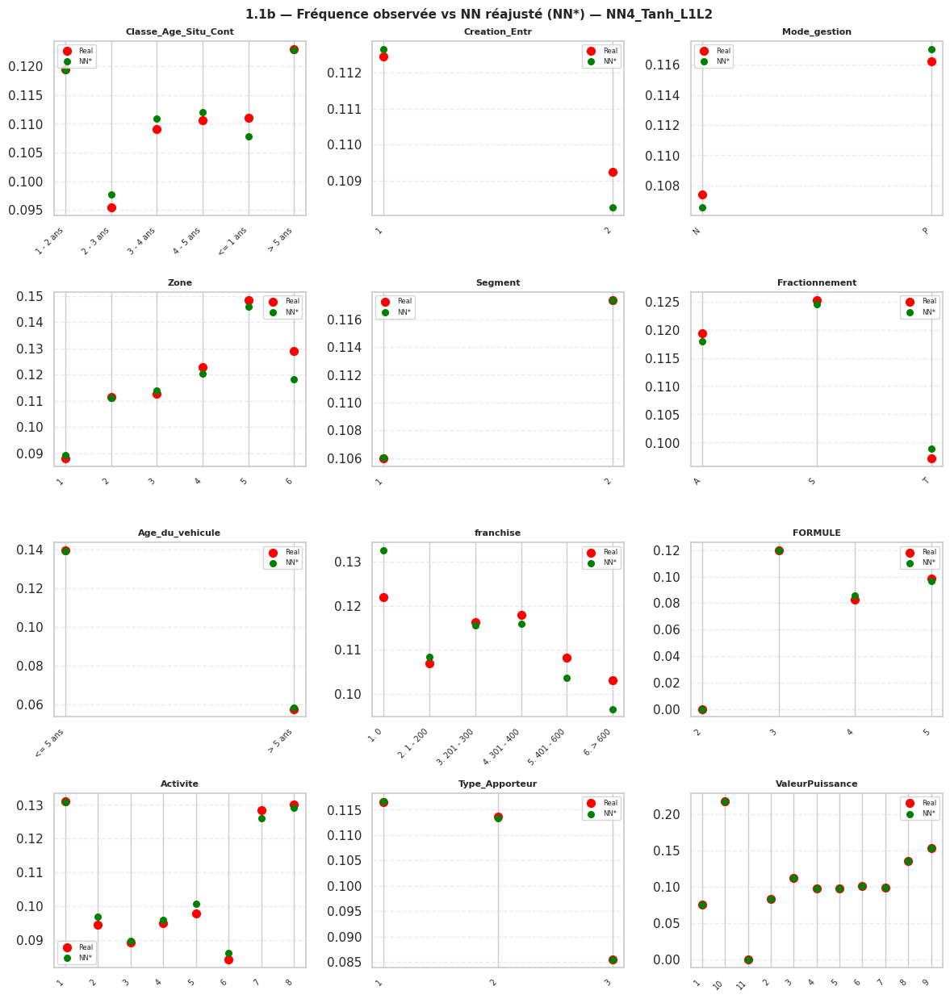

In [ ]:
print("\n" + "="*60)
print("  9. AJUSTEMENT DU BIAIS — BALANCE PROPERTY")
print("="*60)

val_df['Freq_GLM_corr'] = val_df['Freq_GLM'].copy()
val_df['Freq_NN_corr']  = val_df['Freq_NN'].copy()

def balance_group(df, pred_col, group_col, eps=1e-9):
    stats = (df.groupby(group_col, observed=True)
               .apply(lambda g: pd.Series({
                   'obs' : wavg(g['Freq_Obs'], g['Exposition_au_risque']),
                   'pred': wavg(g[pred_col],   g['Exposition_au_risque'])
               })))
    stats['factor'] = stats['obs'] / stats['pred'].clip(lower=eps)
    mapping = {str(k): v for k, v in stats['factor'].to_dict().items()}
    df[pred_col] = (df[pred_col]
                    * df[group_col].astype(str).map(mapping).fillna(1.0))
    return stats

calib_groups = [c for c in [
    'Classe_Age_Situ_Cont', 'Creation_Entr', 'Mode_gestion', 'Zone',
    'Segment', 'Fractionnement', 'Age_du_vehicule', 'franchise',
    'FORMULE', 'Activite', 'Type_Apporteur', 'ValeurPuissance'
] if c in val_df.columns]

for g in calib_groups:
    s_glm = balance_group(val_df, 'Freq_GLM_corr', g)
    s_nn  = balance_group(val_df, 'Freq_NN_corr',  g)
    print(f"\n  Calibration '{g}' :")
    print(f"    GLM : { {k: f'{v:.3f}' for k,v in s_glm['factor'].to_dict().items()} }")
    print(f"    NN  : { {k: f'{v:.3f}' for k,v in s_nn['factor'].to_dict().items()} }")

val_df['Freq_GLM_corr'] = val_df['Freq_GLM_corr'].clip(lower=1e-9)
val_df['Freq_NN_corr']  = val_df['Freq_NN_corr'].clip(lower=1e-9)

md_glm_corr = mean_poisson_deviance(
    freq_val, val_df['Freq_GLM_corr'].values, sample_weight=expo_val)
md_nn_corr  = mean_poisson_deviance(
    freq_val, val_df['Freq_NN_corr'].values,  sample_weight=expo_val)

print(f"\n  GLM : avant = {md_glm_va:.6f}  →  après = {md_glm_corr:.6f}")
print(f"  NN  : avant = {best_nn['md_va']:.6f}  →  après = {md_nn_corr:.6f}")

recap_bias = pd.DataFrame([
    {'Modele': 'GLM_Poisson', 'Dev_avant': md_glm_va,
     'Dev_après': md_glm_corr, 'Δ': md_glm_va - md_glm_corr},
    {'Modele': best_nn['Modele'], 'Dev_avant': best_nn['md_va'],
     'Dev_après': md_nn_corr, 'Δ': best_nn['md_va'] - md_nn_corr},
])
print("\n  DÉVIANCE AVANT / APRÈS CORRECTION")
print(recap_bias.round(6).to_string(index=False))

# Scatter plots après ajustement
def compare_bias_scatter(col, ax_glm, ax_nn):
    if col not in val_df.columns:
        return
    tmp = val_df.copy(); tmp[col] = tmp[col].astype(str)
    tab = (tmp.groupby(col, observed=True)
              .apply(lambda g: pd.Series({
                  'Observée': wavg(g['Freq_Obs'],      g['Exposition_au_risque']),
                  'GLM_corr': wavg(g['Freq_GLM_corr'], g['Exposition_au_risque']),
                  'NN_corr' : wavg(g['Freq_NN_corr'],  g['Exposition_au_risque']),
              })).reset_index())
    labels = tab[col].astype(str).tolist()
    x      = np.arange(len(labels))

    ax_glm.scatter(x, tab['Observée'],  color='red',   s=50, zorder=4, label='Real')
    ax_glm.scatter(x, tab['GLM_corr'], color='green', s=30, zorder=4, label='GLM*')
    ax_glm.set_xticks(x); ax_glm.set_xticklabels(labels, rotation=45,
                                                   ha='right', fontsize=7)
    ax_glm.set_title(col, fontsize=8, fontweight='bold')
    ax_glm.legend(fontsize=6); ax_glm.yaxis.grid(True, linestyle='--', alpha=0.4)
    ax_glm.set_axisbelow(True)

    ax_nn.scatter(x, tab['Observée'],  color='red',   s=50, zorder=4, label='Real')
    ax_nn.scatter(x, tab['NN_corr'],   color='green', s=30, zorder=4, label='NN*')
    ax_nn.set_xticks(x); ax_nn.set_xticklabels(labels, rotation=45,
                                                 ha='right', fontsize=7)
    ax_nn.set_title(col, fontsize=8, fontweight='bold')
    ax_nn.legend(fontsize=6); ax_nn.yaxis.grid(True, linestyle='--', alpha=0.4)
    ax_nn.set_axisbelow(True)


n_cal  = len(calib_groups)
ncols  = min(3, n_cal); nrows_c = int(np.ceil(n_cal / ncols))

fig_bc_glm, axes_bc_glm = plt.subplots(nrows_c, ncols,
                                         figsize=(ncols*10*cm, nrows_c*8*cm))
fig_bc_nn,  axes_bc_nn  = plt.subplots(nrows_c, ncols,
                                         figsize=(ncols*10*cm, nrows_c*8*cm))
axes_bc_glm = np.array(axes_bc_glm).ravel()
axes_bc_nn  = np.array(axes_bc_nn).ravel()

for i, col in enumerate(calib_groups):
    compare_bias_scatter(col, axes_bc_glm[i], axes_bc_nn[i])
for j in range(n_cal, len(axes_bc_glm)):
    axes_bc_glm[j].set_visible(False); axes_bc_nn[j].set_visible(False)

fig_bc_glm.suptitle("1.1b — Fréquence observée vs GLM réajusté (GLM*)",
                     fontsize=11, fontweight='bold')
fig_bc_glm.tight_layout(); fig_bc_glm.savefig("1_1b_bias_GLM.png", dpi=150)
fig_bc_glm.show(); print("  1_1b_bias_GLM.png")

fig_bc_nn.suptitle(f"1.1b — Fréquence observée vs NN réajusté (NN*) — {best_nn['Modele']}",
                    fontsize=11, fontweight='bold')
fig_bc_nn.tight_layout(); fig_bc_nn.savefig("1_1b_bias_NN.png", dpi=150)
fig_bc_nn.show(); print("  1_1b_bias_NN.png")

best_nn['model'].save_weights("best_nn.weights.h5")
print(f"\n  Poids sauvegardés : best_nn.weights.h5  ({best_nn['Modele']})")




  10. PDP — PARTIAL DEPENDENCE PLOTS
  Variables nominales : ['Mode_gestion', 'Zone', 'Fractionnement', 'franchise', 'FORMULE', 'Activite', 'Type_Apporteur', 'Creation_Entr', 'Nombre_vehicule', 'Age_du_vehicule', 'Classe_Age_Situ_Cont', 'Segment', 'ValeurPuissance']
  Variables ordinales : ['ValeurPuissance']
  Fréquence globale   : 0.111936

── PDP nominales (grille 4×3) ──
  ✓ Mode_gestion
  ✓ Zone
  ✓ Fractionnement
  ✓ franchise
  ✓ FORMULE
  ✓ Activite
  ✓ Type_Apporteur
  ✓ Creation_Entr
  ✓ Nombre_vehicule
  ✓ Age_du_vehicule
  ✓ Classe_Age_Situ_Cont
  ✓ Segment
  ✓ ValeurPuissance


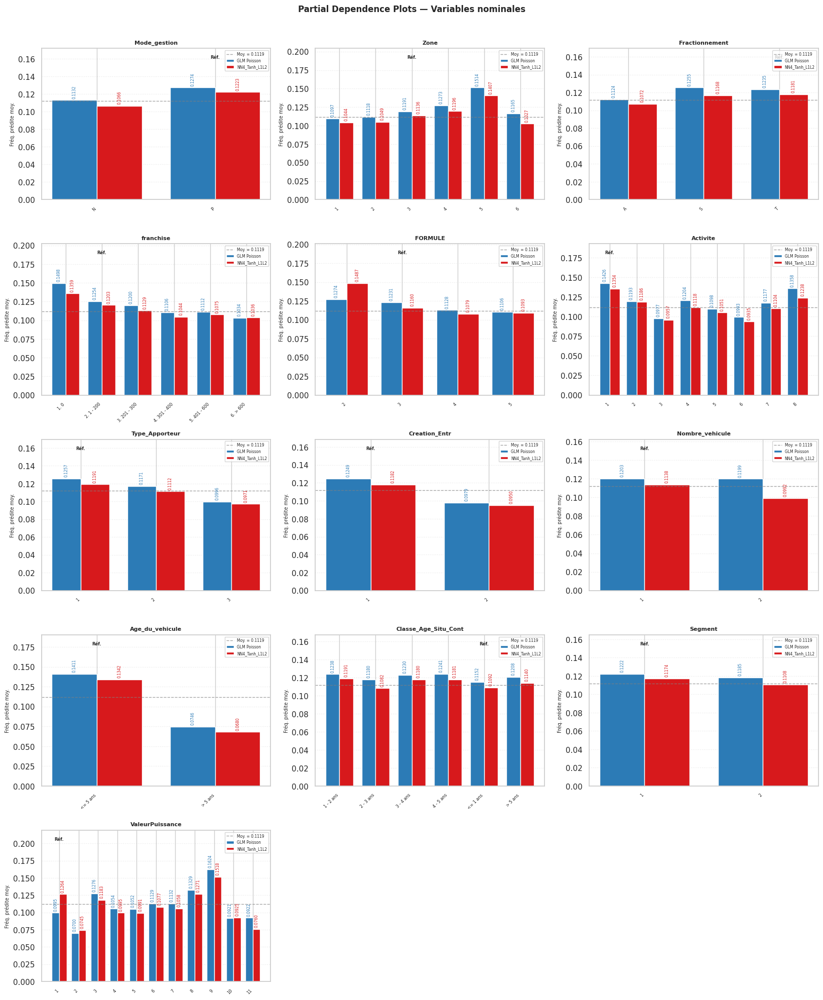

  → pdp_nominales_grid_p1.png


In [ ]:

# ══════════════════════════════════════════════════════════════════
#  10. PDP — PARTIAL DEPENDENCE PLOTS (Section 1.2)
# ══════════════════════════════════════════════════════════════════
print("\n" + "="*60)
print("  10. PDP — PARTIAL DEPENDENCE PLOTS")
print("="*60)

class KerasWrapper(BaseEstimator, RegressorMixin):
    def __init__(self, keras_model):
        self.keras_model = keras_model
    def fit(self, X, y, **kwargs): return self
    def predict(self, X):
        return self.keras_model.predict(
            np.array(X, dtype="float32"), verbose=0).ravel()
    def score(self, X, y, sample_weight=None):
        pred = np.clip(self.predict(X), 1e-9, None)
        return -mean_poisson_deviance(y, pred, sample_weight=sample_weight)

kr            = KerasWrapper(best_nn['model'])
feature_names = list(X_dummies.columns)

# Variables pour PDP

cat_nominales = [c for c in [
    'Mode_gestion', 'Zone', 'Fractionnement', 'franchise', 'FORMULE',
    'Activite', 'Type_Apporteur', 'Creation_Entr',
    'Nombre_vehicule', 'Age_du_vehicule', 'Classe_Age_Situ_Cont', "Segment","ValeurPuissance"
] if c in data.columns]

ordinal_auto = [c for c in ["ValeurPuissance"] if c in data.columns]

print(f"  Variables nominales : {cat_nominales}")
print(f"  Variables ordinales : {ordinal_auto}")
print(f"  Fréquence globale   : {freq_glob:.6f}")


def parse_numeric_modalite(x):
    try: return float(x)
    except: return np.nan

def sort_modalites_nominales(df):
    vals_num = df["Modalite"].apply(parse_numeric_modalite)
    if vals_num.notna().all():
        df = df.assign(sort_key=vals_num).sort_values("sort_key")
    else:
        df = df.assign(sort_key=df["Modalite"].astype(str)).sort_values("sort_key")
    return df.drop(columns="sort_key").reset_index(drop=True)


# ── PDP nominales : barplot GLM vs NN ──
def pdp_ohe_var(model_predict_fn, X, var_name,
                feature_names, references, weights=None):
    """Calcule PDP pour variable catégorielle nominale."""
    ohe_cols = [(i, f) for i, f in enumerate(feature_names)
                if f.startswith(f"{var_name}_")]
    if not ohe_cols:
        return None

    ohe_idx = [i for i, _ in ohe_cols]
    X_mod   = X.copy().astype("float32")
    results = []

    # Modalité de référence (toutes OHE à 0)
    ref_mod = str(references.get(var_name, "ref"))
    X_mod[:, ohe_idx] = 0
    preds   = model_predict_fn(X_mod)
    pdp_ref = np.average(preds, weights=weights) if weights is not None else preds.mean()
    results.append({"Modalite": ref_mod, "PDP": pdp_ref, "Reference": 1})

    for col_idx, col_name in ohe_cols:
        modalite = col_name.replace(f"{var_name}_", "")
        X_mod[:, ohe_idx] = 0
        X_mod[:, col_idx] = 1
        preds   = model_predict_fn(X_mod)
        pdp_val = np.average(preds, weights=weights) if weights is not None else preds.mean()
        results.append({"Modalite": modalite, "PDP": pdp_val, "Reference": 0})

    df = pd.DataFrame(results)
    return sort_modalites_nominales(df)


# ── PDP ordinales : points + interpolation ──
def pdp_ohe_discret(model_predict_fn, X, var_name,
                    feature_names, references, weights=None):
    """Calcule PDP pour variable catégorielle ordinale (numérique)."""
    ohe_cols = [(i, f) for i, f in enumerate(feature_names)
                if f.startswith(f"{var_name}_")]
    if not ohe_cols:
        return None

    ohe_idx = [i for i, _ in ohe_cols]
    X_mod   = X.copy().astype("float32")
    results = []

    ref_mod = str(references.get(var_name, "ref"))
    X_mod[:, ohe_idx] = 0
    preds   = model_predict_fn(X_mod)
    pdp_ref = np.average(preds, weights=weights) if weights is not None else preds.mean()
    results.append({"Modalite": ref_mod, "PDP": pdp_ref, "Reference": 1})

    for col_idx, col_name in ohe_cols:
        modalite = col_name.replace(f"{var_name}_", "")
        X_mod[:, ohe_idx] = 0
        X_mod[:, col_idx] = 1
        preds   = model_predict_fn(X_mod)
        pdp_val = np.average(preds, weights=weights) if weights is not None else preds.mean()
        results.append({"Modalite": modalite, "PDP": pdp_val, "Reference": 0})

    df = pd.DataFrame(results)
    df["x_num"] = df["Modalite"].apply(parse_numeric_modalite)
    df = df.sort_values(["x_num", "Modalite"], na_position="last").reset_index(drop=True)
    return df


def draw_pdp_nominale_ax(ax, var_name, pdp_glm, pdp_nn):
    """Barplot GLM vs NN pour variable nominale."""
    tab = pdp_glm.rename(columns={"PDP": "GLM"}).merge(
        pdp_nn[["Modalite", "PDP"]].rename(columns={"PDP": "NN"}),
        on="Modalite", how="inner")
    tab   = sort_modalites_nominales(tab)
    x     = np.arange(len(tab))
    width = 0.38

    bars_glm = ax.bar(x - width/2, tab["GLM"], width=width,
                      label="GLM Poisson", color="#2c7bb6")
    bars_nn  = ax.bar(x + width/2, tab["NN"],  width=width,
                      label=best_nn["Modele"],  color="#d7191c")
    ax.axhline(freq_glob, linestyle="--", linewidth=1.0, alpha=0.7,
               color="gray", label=f"Moy. = {freq_glob:.4f}")

    y_max  = max(tab["GLM"].max(), tab["NN"].max())
    offset = y_max * 0.015
    for bar in bars_glm:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + offset,
                f"{h:.4f}", ha='center', va='bottom',
                fontsize=5.5, rotation=90, color="#2c7bb6")
    for bar in bars_nn:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + offset,
                f"{h:.4f}", ha='center', va='bottom',
                fontsize=5.5, rotation=90, color="#d7191c")

    # Marquer la référence
    ref_rows = pdp_glm[pdp_glm["Reference"] == 1]
    if len(ref_rows) > 0:
        ref_mod = ref_rows["Modalite"].iloc[0]
        if ref_mod in tab["Modalite"].values:
            ref_idx = list(tab["Modalite"]).index(ref_mod)
            ax.text(ref_idx, y_max * 1.25, "Réf.", ha="center",
                    va="bottom", fontsize=6, fontweight="bold")

    ax.set_xticks(x)
    ax.set_xticklabels(tab["Modalite"].astype(str), rotation=45,
                       ha="right", fontsize=6)
    ax.set_ylabel("Fréq. prédite moy.", fontsize=7)
    ax.set_title(var_name, fontsize=8, fontweight="bold")
    ax.set_ylim(0, y_max * 1.35)
    ax.yaxis.grid(True, linestyle=":", alpha=0.4)
    ax.set_axisbelow(True)
    ax.legend(fontsize=5.5, loc="upper right")


def draw_pdp_ordinale_ax(ax, var_name, glm_pts, nn_pts, n_points=200):
    """Courbe lissée GLM vs NN pour variable ordinale."""
    glm_num = glm_pts[glm_pts["x_num"].notna()].copy()
    nn_num  = nn_pts[nn_pts["x_num"].notna()].copy()

    if len(glm_num) < 2 or len(nn_num) < 2:
        ax.set_visible(False)
        return

    x_min = min(glm_num["x_num"].min(), nn_num["x_num"].min())
    x_max = max(glm_num["x_num"].max(), nn_num["x_num"].max())
    x_grid = np.linspace(x_min, x_max, n_points)
    y_glm  = np.interp(x_grid, glm_num["x_num"].values, glm_num["PDP"].values)
    y_nn   = np.interp(x_grid, nn_num["x_num"].values,  nn_num["PDP"].values)

    ax.plot(x_grid, y_glm, linewidth=1.8, color="#2c7bb6", label="GLM Poisson")
    ax.plot(x_grid, y_nn,  linewidth=1.8, linestyle="--",
            color="#d7191c", label=best_nn["Modele"])
    ax.scatter(glm_num["x_num"], glm_num["PDP"], s=25, zorder=4, color="#2c7bb6")
    ax.scatter(nn_num["x_num"],  nn_num["PDP"],  s=25, marker="s", zorder=4, color="#d7191c")

    y_max = max(glm_num["PDP"].max(), nn_num["PDP"].max())
    for _, row in glm_num.iterrows():
        ax.text(row["x_num"], row["PDP"] + y_max * 0.012,
                f"{row['PDP']:.4f}", ha="center", va="bottom",
                fontsize=5.5, color="#2c7bb6")
    for _, row in nn_num.iterrows():
        ax.text(row["x_num"], row["PDP"] + y_max * 0.012,
                f"{row['PDP']:.4f}", ha="center", va="bottom",
                fontsize=5.5, color="#d7191c")

    ax.axhline(freq_glob, linestyle=":", linewidth=1.0, alpha=0.7,
               color="gray", label=f"Moy. = {freq_glob:.4f}")
    ax.set_xlabel(var_name, fontsize=7)
    ax.set_ylabel("Fréq. prédite moy.", fontsize=7)
    ax.set_title(var_name, fontsize=8, fontweight="bold")
    ax.legend(fontsize=5.5, loc="upper right")
    ax.yaxis.grid(True, linestyle=":", alpha=0.4)
    ax.set_axisbelow(True)


def plot_pdp_nominales_grid(vars_list, n_rows=4, n_cols=3):
    n_vars = len(vars_list); n_per_page = n_rows * n_cols
    n_pages = int(np.ceil(n_vars / n_per_page))
    all_pdp = {}

    for page in range(n_pages):
        vars_page = vars_list[page * n_per_page: (page + 1) * n_per_page]
        fig, axes = plt.subplots(n_rows, n_cols,
                                  figsize=(n_cols * 14 * cm, n_rows * 10 * cm))
        axes_flat = axes.flatten()

        for k, var in enumerate(vars_page):
            ax      = axes_flat[k]
            pdp_glm = pdp_ohe_var(glm.predict, X_train.copy(), var,
                                   feature_names, references, weights=expo_train)
            pdp_nn  = pdp_ohe_var(kr.predict,  X_train.copy(), var,
                                   feature_names, references, weights=expo_train)
            if pdp_glm is None or pdp_nn is None:
                ax.set_visible(False)
                print(f"  Aucune dummy pour {var}")
                continue
            draw_pdp_nominale_ax(ax, var, pdp_glm, pdp_nn)
            all_pdp[var] = {"GLM": pdp_glm, "NN": pdp_nn}
            print(f"  ✓ {var}")

        for k in range(len(vars_page), n_rows * n_cols):
            axes_flat[k].set_visible(False)

        title_suffix = f" (page {page+1}/{n_pages})" if n_pages > 1 else ""
        fig.suptitle("Partial Dependence Plots — Variables nominales" + title_suffix,
                     fontsize=12, fontweight="bold", y=1.01)
        fig.tight_layout()
        fname = f"pdp_nominales_grid_p{page+1}.png"
        fig.savefig(fname, dpi=200, bbox_inches="tight")
        plt.show()
        print(f"  → {fname}")

    return all_pdp


def plot_pdp_ordinales_grid(vars_list, n_cols=3):
    n_vars = len(vars_list)
    if n_vars == 0:
        return {}
    n_rows = int(np.ceil(n_vars / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols,
                              figsize=(n_cols * 14 * cm, n_rows * 10 * cm),
                              squeeze=False)
    axes_flat = axes.flatten()
    all_pdp   = {}

    for k, var in enumerate(vars_list):
        ax          = axes_flat[k]
        pdp_glm_raw = pdp_ohe_discret(glm.predict, X_train.copy(), var,
                                       feature_names, references, weights=expo_train)
        pdp_nn_raw  = pdp_ohe_discret(kr.predict,  X_train.copy(), var,
                                       feature_names, references, weights=expo_train)
        if pdp_glm_raw is None or pdp_nn_raw is None:
            ax.set_visible(False)
            continue
        draw_pdp_ordinale_ax(ax, var, pdp_glm_raw, pdp_nn_raw)
        all_pdp[var] = {"GLM": pdp_glm_raw, "NN": pdp_nn_raw}
        print(f"  ✓ {var}")

    for k in range(n_vars, n_rows * n_cols):
        axes_flat[k].set_visible(False)

    fig.suptitle("Partial Dependence Plots — Variables ordinales",
                 fontsize=12, fontweight="bold", y=1.01)
    fig.tight_layout()
    fig.savefig("pdp_ordinales_grid.png", dpi=200, bbox_inches="tight")
    plt.show()
    print("  → pdp_ordinales_grid.png")
    return all_pdp


print("\n── PDP nominales (grille 4×3) ──")
pdp_nominales = plot_pdp_nominales_grid(cat_nominales, n_rows=5, n_cols=3)

#print("\n── PDP ordinales ──")
#pdp_ordinales = plot_pdp_ordinales_grid(ordinal_auto, n_cols=3)


  11. ICE — INDIVIDUAL CONDITIONAL EXPECTATION

  ICE individuels par variable :


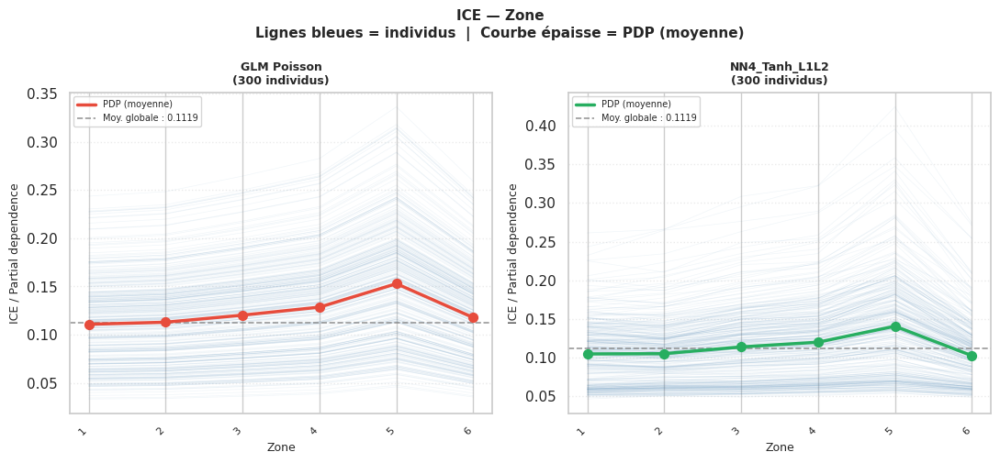

  ice_Zone.png


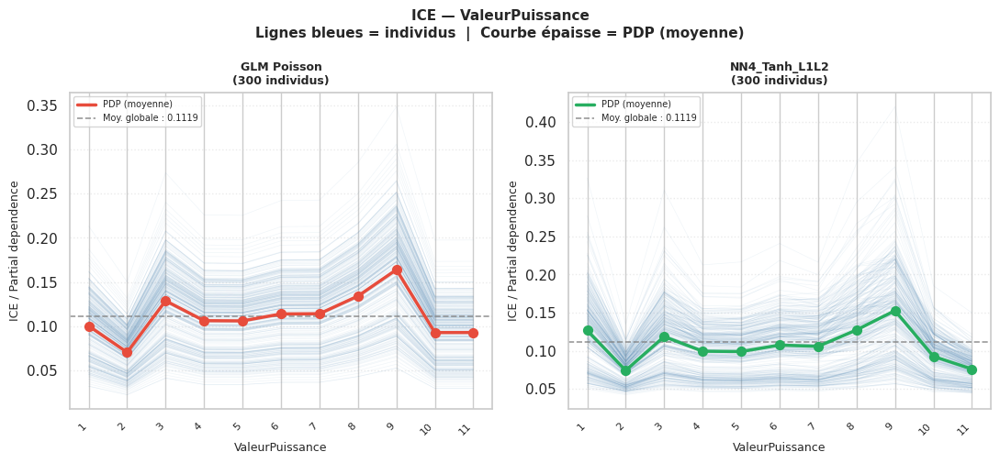

  ice_ValeurPuissance.png


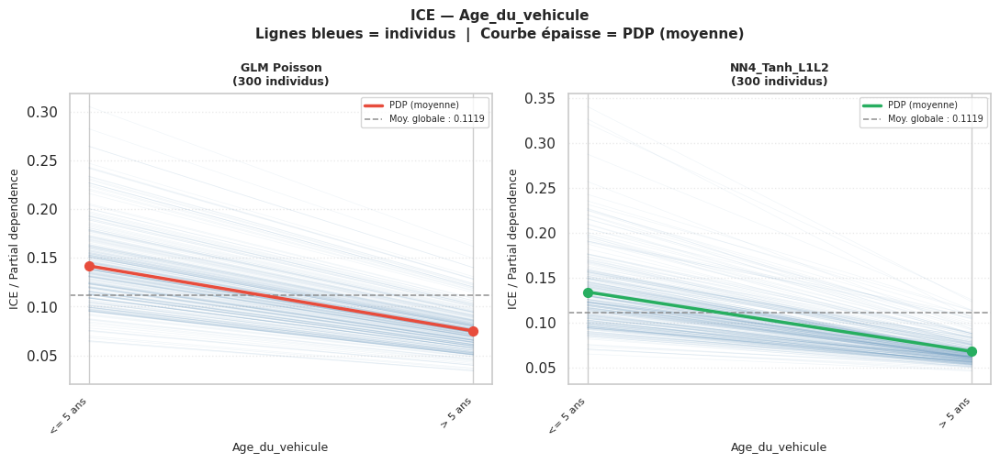

  ice_Age_du_vehicule.png


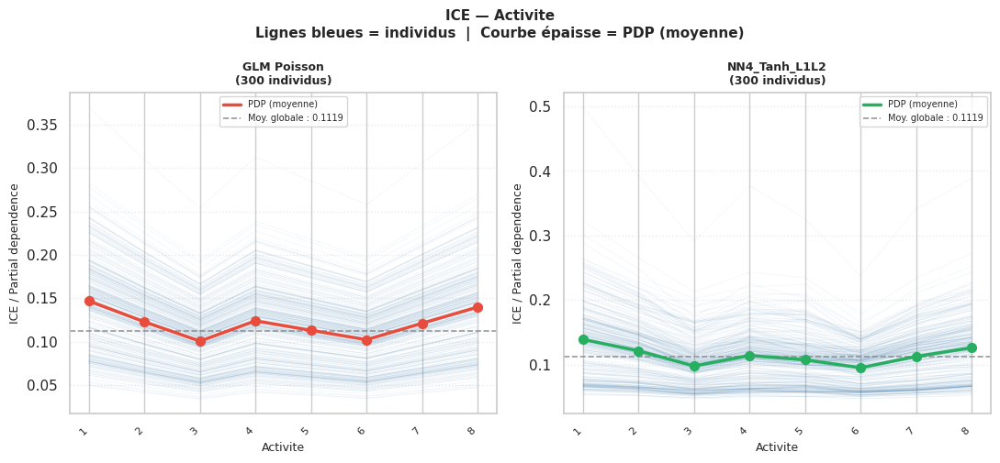

  ice_Activite.png


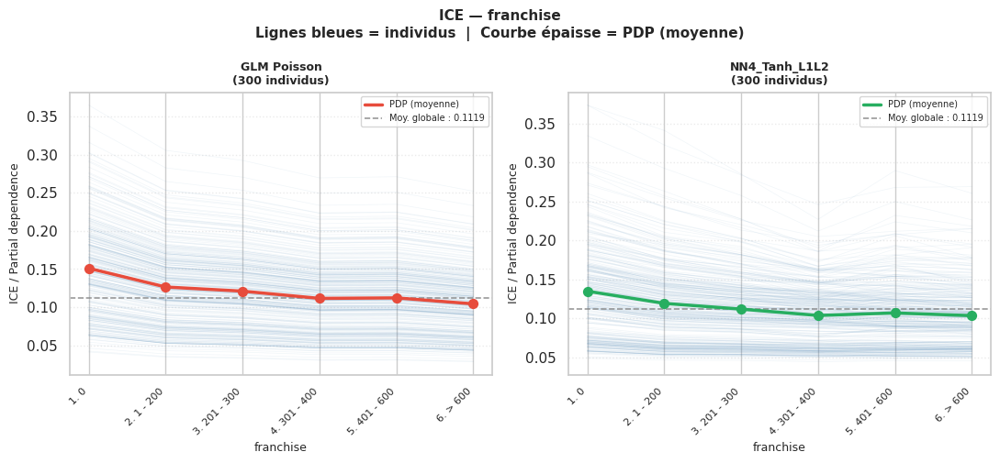

  ice_franchise.png


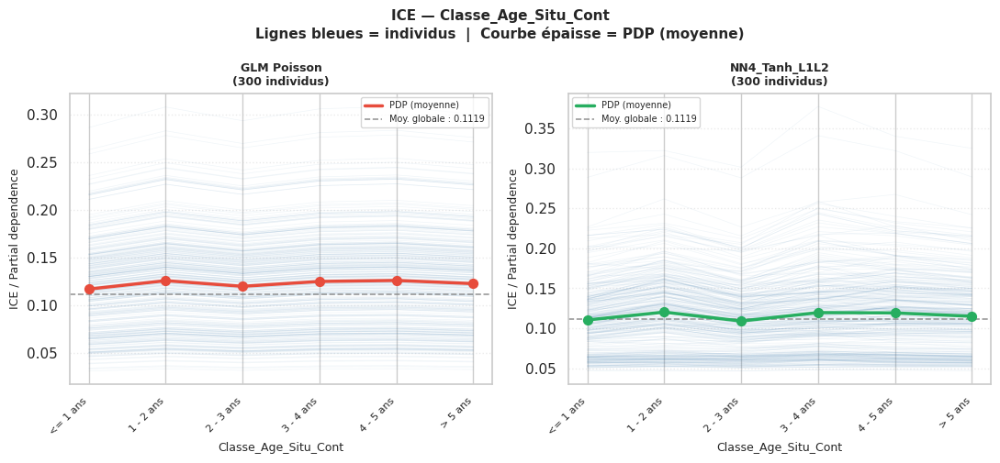

  ice_Classe_Age_Situ_Cont.png


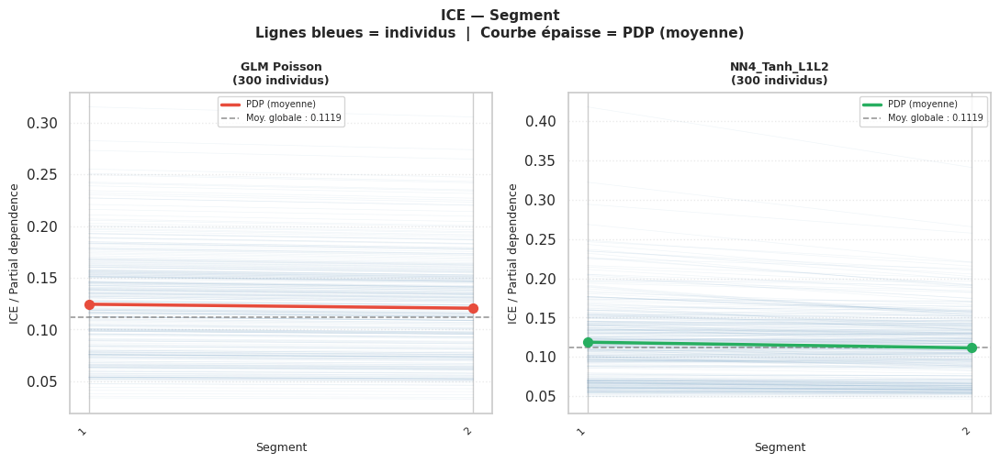

  ice_Segment.png


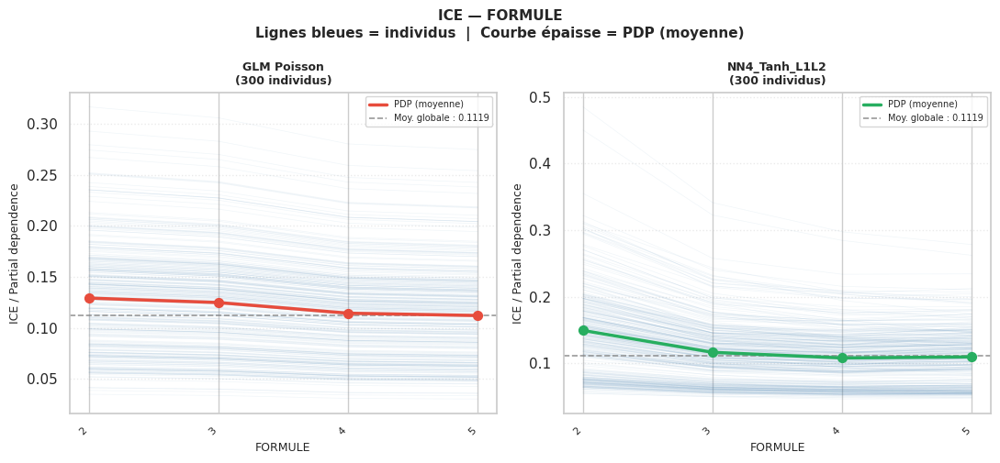

  ice_FORMULE.png


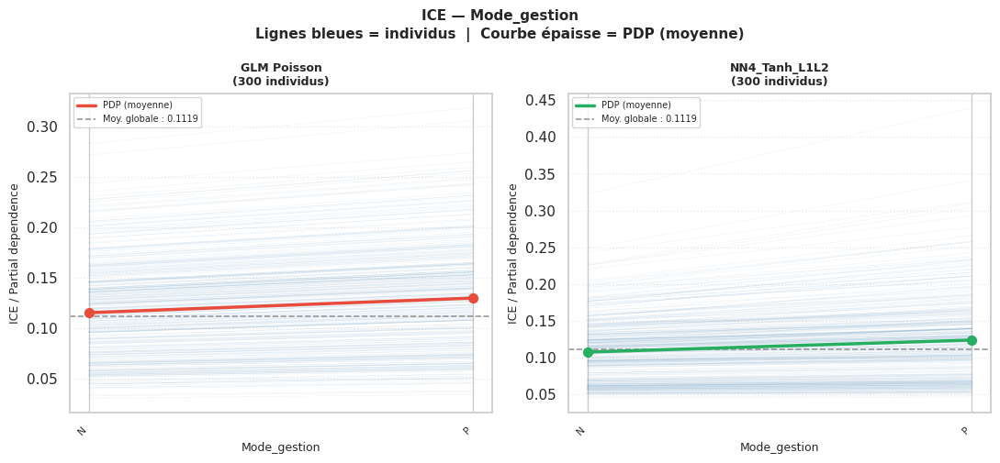

  ice_Mode_gestion.png


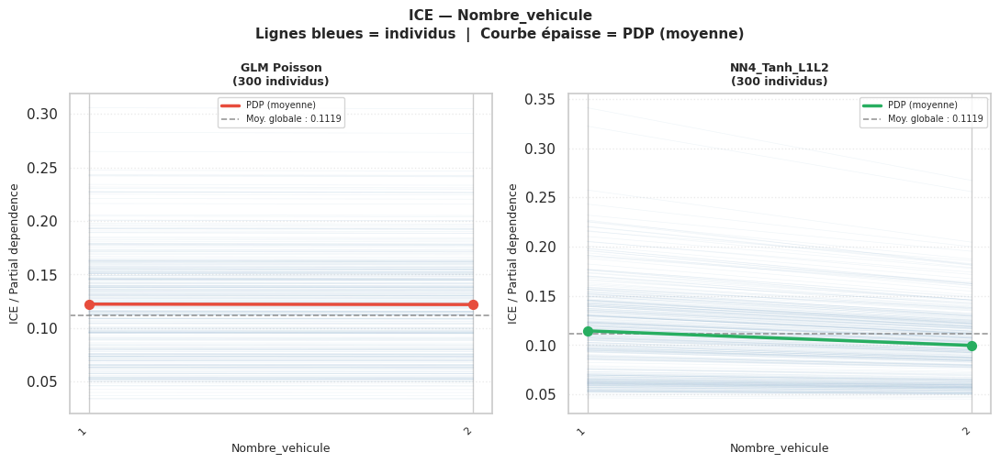

  ice_Nombre_vehicule.png


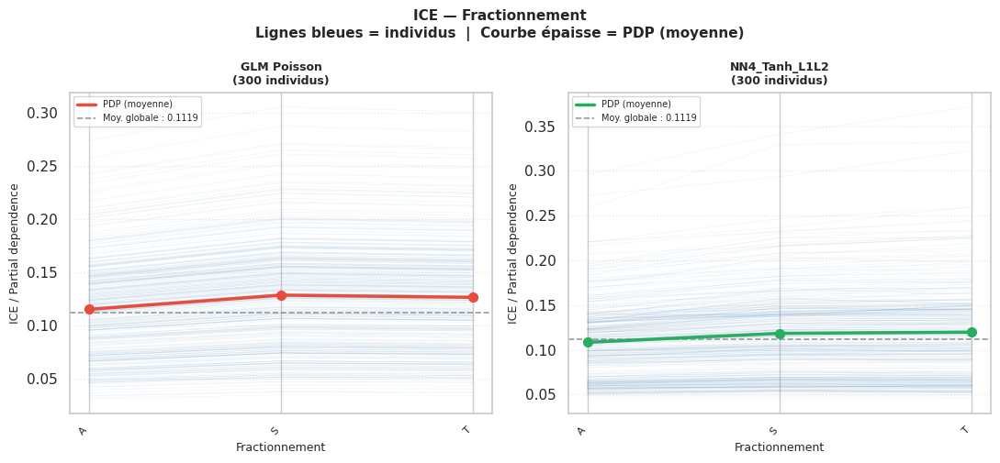

  ice_Fractionnement.png


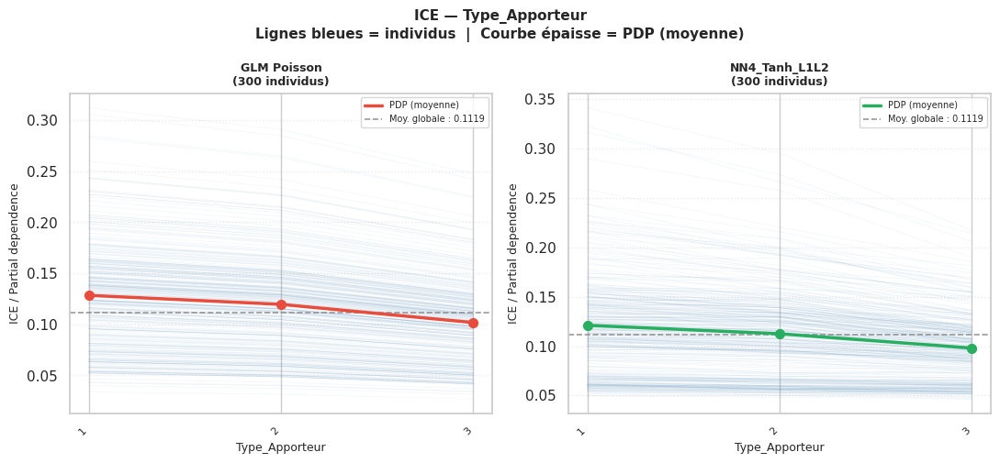

  ice_Type_Apporteur.png


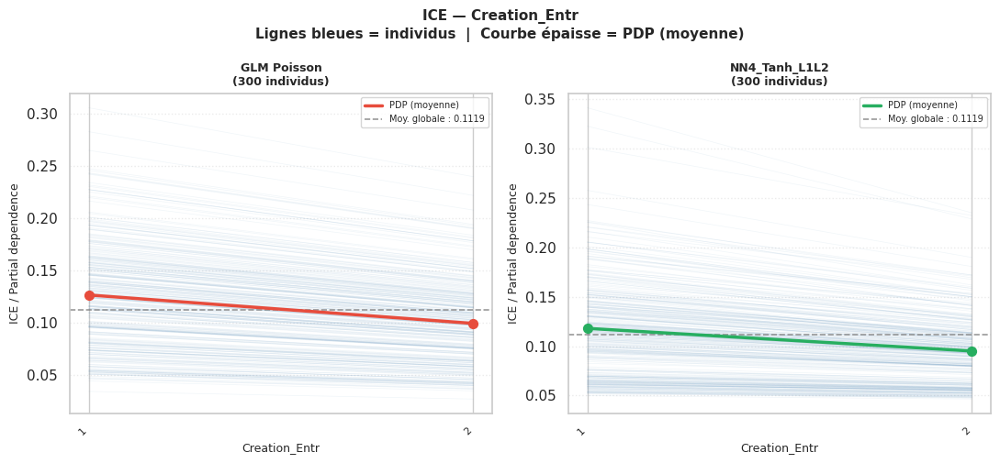

  ice_Creation_Entr.png

  Figure récapitulative GLM...


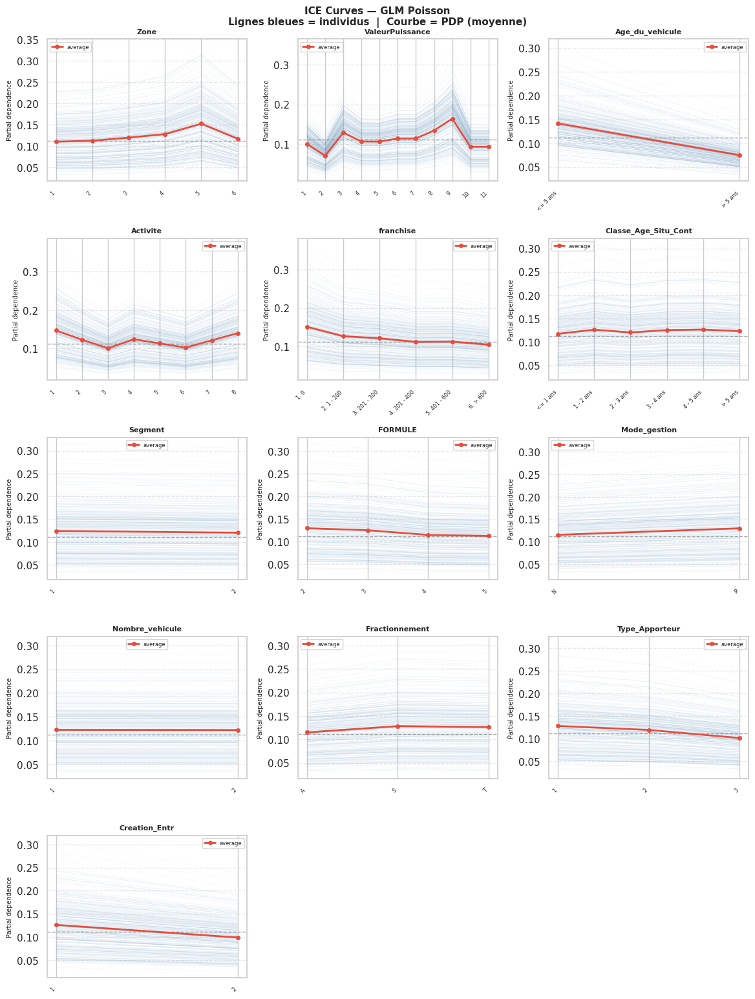

  ice_recap_GLM Poisson.png

  Figure récapitulative NN...


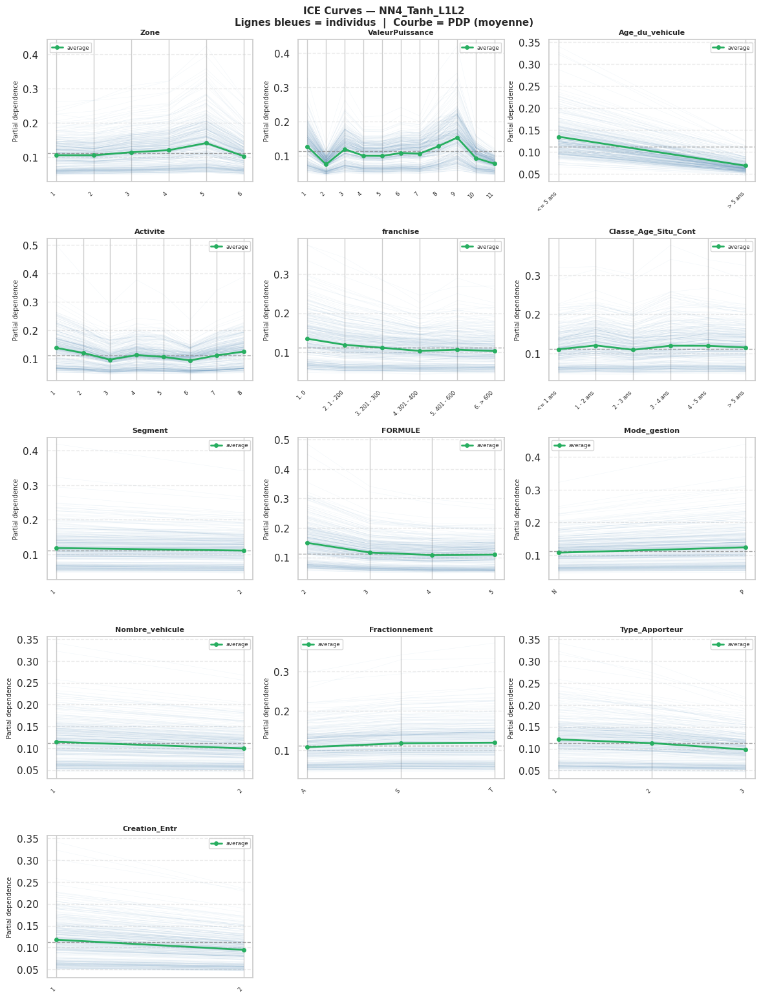

  ice_recap_NN4_Tanh_L1L2.png


In [ ]:
# ══════════════════════════════════════════════════════════════════
#  11. ICE — INDIVIDUAL CONDITIONAL EXPECTATION (Section 1.2b)
# ══════════════════════════════════════════════════════════════════

print("\n" + "="*60)
print("  11. ICE — INDIVIDUAL CONDITIONAL EXPECTATION")
print("="*60)

"""
ICE — Goldstein et al. (2015) :
  ICE^(i)(v) = f(v, x_C^(i))

Pour chaque individu i et chaque modalité v :
  1. Fixer x_S = v
  2. Garder x_C^(i) à sa valeur réelle
  3. Calculer f(v, x_C^(i))
  4. Tracer une courbe par individu

PDP = moyenne des ICE : D_S(v) = (1/n) Σᵢ ICE^(i)(v)
"""

def compute_ice_ohe(model_predict_fn, X, var_name,
                    feature_names, references,
                    weights=None, n_sample=500, seed=42):
    """
    ICE pour variable catégorielle OHE.
    Retourne ice_matrix (n_sample, n_modalites), modalites, pdp, sample_idx, w_sample
    """
    ohe_cols = [(i, f) for i, f in enumerate(feature_names)
                if f.startswith(f"{var_name}_")]
    if not ohe_cols:
        return None, None, None, None, None

    ohe_idx = [i for i, _ in ohe_cols]

    rng        = np.random.RandomState(seed)
    sample_idx = rng.choice(X.shape[0], size=min(n_sample, X.shape[0]), replace=False)
    X_sample   = X[sample_idx].copy().astype("float32")
    w_sample   = weights[sample_idx] if weights is not None else None

    ref_mod        = str(references.get(var_name, "ref"))
    all_modalities = [(None, ref_mod, True)]
    for col_idx, col_name in ohe_cols:
        all_modalities.append((col_idx, col_name.replace(f"{var_name}_", ""), False))

    if var_name in ordinal_vars:
        cat_order      = [str(c) for c in data[var_name].cat.categories]
        all_modalities = sorted(all_modalities,
                                key=lambda x: cat_order.index(x[1])
                                if x[1] in cat_order else 999)
    else:
        try:
            all_modalities = sorted(all_modalities, key=lambda x: float(x[1]))
        except ValueError:
            all_modalities = sorted(all_modalities, key=lambda x: x[1])

    modalites  = [m[1] for m in all_modalities]
    ice_matrix = np.zeros((len(sample_idx), len(modalites)), dtype=float)
    X_mod      = X_sample.copy()

    for j, (col_idx, modalite, is_ref) in enumerate(all_modalities):
        X_mod[:, ohe_idx] = 0
        if not is_ref:
            X_mod[:, col_idx] = 1
        ice_matrix[:, j] = model_predict_fn(X_mod)

    pdp = (np.average(ice_matrix, axis=0, weights=w_sample)
           if w_sample is not None else ice_matrix.mean(axis=0))

    return ice_matrix, modalites, pdp, sample_idx, w_sample


def plot_ice(var_name, figsize=(28*cm, 13*cm), n_sample=300, alpha_ice=0.08):
    """ICE plot GLM et NN côte à côte."""
    ice_glm, mod_glm, pdp_glm, _, _ = compute_ice_ohe(
        glm.predict, X_train.copy(), var_name,
        feature_names, references, weights=expo_train, n_sample=n_sample)
    ice_nn, mod_nn, pdp_nn, _, _ = compute_ice_ohe(
        kr.predict, X_train.copy(), var_name,
        feature_names, references, weights=expo_train, n_sample=n_sample)

    if ice_glm is None:
        print(f"  {var_name} — pas de colonnes OHE")
        return

    fig, axes = plt.subplots(1, 2, figsize=figsize)
    for ax, ice_mat, modalites, pdp, label, color in [
        (axes[0], ice_glm, mod_glm, pdp_glm, 'GLM Poisson', '#e74c3c'),
        (axes[1], ice_nn,  mod_nn,  pdp_nn,  best_nn['Modele'], '#27ae60'),
    ]:
        x = np.arange(len(modalites))
        for i in range(ice_mat.shape[0]):
            ax.plot(x, ice_mat[i, :], color='steelblue',
                    linewidth=0.5, alpha=alpha_ice, zorder=1)
        ax.plot(x, pdp, color=color, linewidth=2.5, zorder=4, label='PDP (moyenne)')
        ax.scatter(x, pdp, color=color, s=50, zorder=5)
        ax.axhline(y=freq_glob, color='gray', linestyle='--', linewidth=1.2,
                   alpha=0.8, label=f'Moy. globale : {freq_glob:.4f}')
        ax.set_xticks(x)
        ax.set_xticklabels(modalites, rotation=45, ha='right', fontsize=8)
        ax.set_ylabel("ICE / Partial dependence", fontsize=9)
        ax.set_xlabel(var_name, fontsize=9)
        ax.set_title(f"{label}\n({ice_mat.shape[0]} individus)",
                     fontsize=9, fontweight='bold')
        ax.legend(fontsize=7)
        ax.yaxis.grid(True, linestyle=':', alpha=0.4)
        ax.set_axisbelow(True)

    plt.suptitle(f"ICE — {var_name}\n"
                 "Lignes bleues = individus  |  Courbe épaisse = PDP (moyenne)",
                 fontsize=11, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f"ice_{var_name}.png", dpi=150)
    plt.show()
    print(f"  ice_{var_name}.png")


def plot_ice_recap(vars_list, model_fn, model_label, color,
                   n_sample=300, alpha_ice=0.07):
    """Grille récapitulative ICE pour un modèle."""
    vars_ok = [v for v in vars_list if v in data.columns]
    n       = len(vars_ok); ncols = 3; nrows = int(np.ceil(n / ncols))

    fig, axes = plt.subplots(nrows, ncols,
                              figsize=(ncols * 10 * cm, nrows * 8 * cm))
    axes = np.array(axes).ravel()

    for i, var in enumerate(vars_ok):
        ax = axes[i]
        ice_mat, modalites, pdp, _, _ = compute_ice_ohe(
            model_fn, X_train.copy(), var,
            feature_names, references, weights=expo_train, n_sample=n_sample)
        if ice_mat is None:
            ax.set_visible(False); continue

        x = np.arange(len(modalites))
        for k in range(ice_mat.shape[0]):
            ax.plot(x, ice_mat[k, :], color='steelblue',
                    linewidth=0.4, alpha=alpha_ice, zorder=1)
        ax.plot(x, pdp, color=color, linewidth=2, marker='o',
                markersize=4, zorder=4, label='average')
        ax.axhline(y=freq_glob, color='gray', linestyle='--',
                   linewidth=1, alpha=0.7)
        ax.set_xticks(x)
        ax.set_xticklabels(modalites, rotation=45, ha='right', fontsize=6)
        ax.set_title(var, fontsize=8, fontweight='bold')
        ax.set_ylabel("Partial dependence", fontsize=7)
        ax.legend(fontsize=6)
        ax.yaxis.grid(True, linestyle='--', alpha=0.4)
        ax.set_axisbelow(True)

    for j in range(len(vars_ok), len(axes)):
        axes[j].set_visible(False)

    fig.suptitle(f"ICE Curves — {model_label}\n"
                 "Lignes bleues = individus  |  Courbe = PDP (moyenne)",
                 fontsize=11, fontweight='bold')
    fig.tight_layout()
    fig.savefig(f"ice_recap_{model_label.replace(' ','_')}.png", dpi=150)
    plt.show()
    print(f"  ice_recap_{model_label}.png")


ice_vars = [c for c in [
    'Zone', 'ValeurPuissance', 'Age_du_vehicule', 'Activite','franchise',
    'Classe_Age_Situ_Cont', 'Segment', 'FORMULE','Mode_gestion', 'Nombre_vehicule',
    'Fractionnement', 'Type_Apporteur', 'Creation_Entr'
] if c in data.columns]

print("\n  ICE individuels par variable :")
for var in ice_vars:
    plot_ice(var, n_sample=300)

print("\n  Figure récapitulative GLM...")
plot_ice_recap(ice_vars, glm.predict, 'GLM Poisson', '#e74c3c', n_sample=300)

print("\n  Figure récapitulative NN...")
plot_ice_recap(ice_vars, kr.predict, best_nn['Modele'], '#27ae60', n_sample=300)




In [ ]:
data.columns

Index(['Classe_Age_Situ_Cont', 'Creation_Entr', 'Mode_gestion', 'Zone',
       'Segment', 'Fractionnement', 'Exposition_au_risque', 'Age_du_vehicule',
       'franchise', 'Nombre_vehicule', 'FORMULE', 'Num_contrat', 'Activite',
       'Type_Apporteur', 'ValeurPuissance', 'nombre_de_sinistre', 'Frequence'],
      dtype='object')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 9.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done

  12. LIME & SHAPLEY VALUES

  Police id=50612 :
    Fréquence obs : 0.0000
    Exposition    : 1.0000
    Sinistres     : 0

  Police id=16863 :
    Fréquence obs : 14.2857
    Exposition    : 0.2100
    Sinistres     : 3
  id=50612 → dans X_train (position 69087)
  id=16863 → dans X_train (position 33107)

  Police 50612 — GLM : 0.1293  |  NN : 0.1165  |  Obs : 0.0
  Police 16863 — GLM : 0.2118  |  NN : 0.2094  |  Obs : 14.285714285714286

  Calcul SHAP ...
  Waterfall SHAP — GLM et NN :


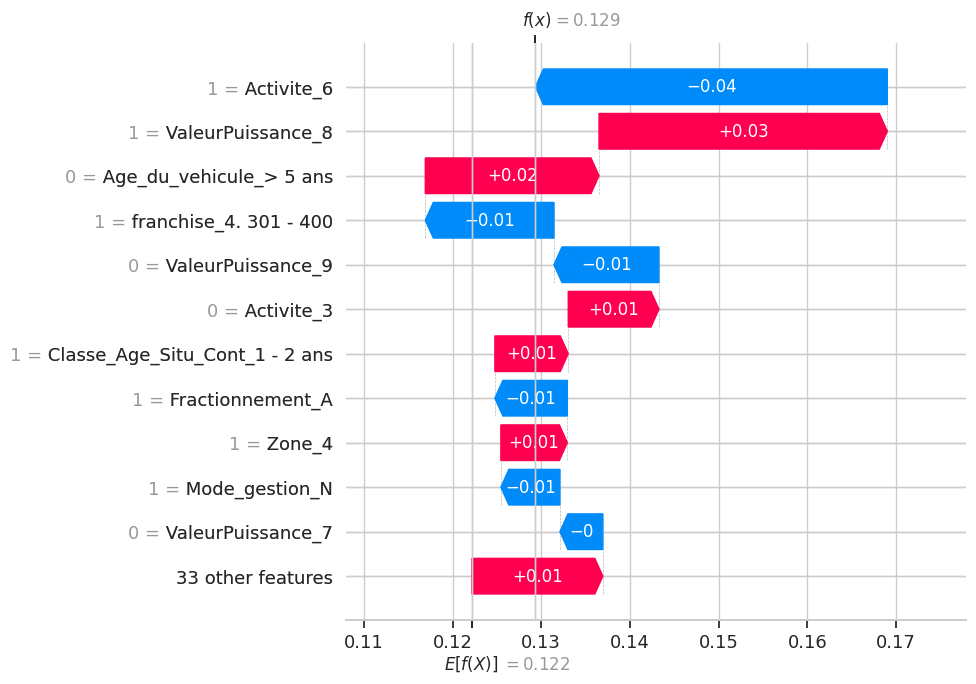

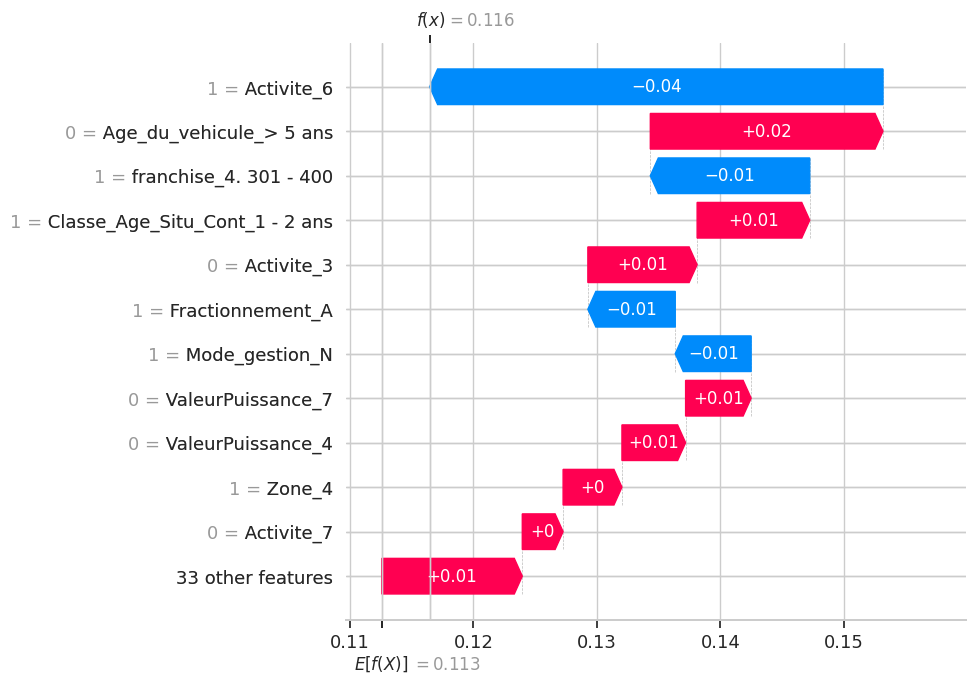

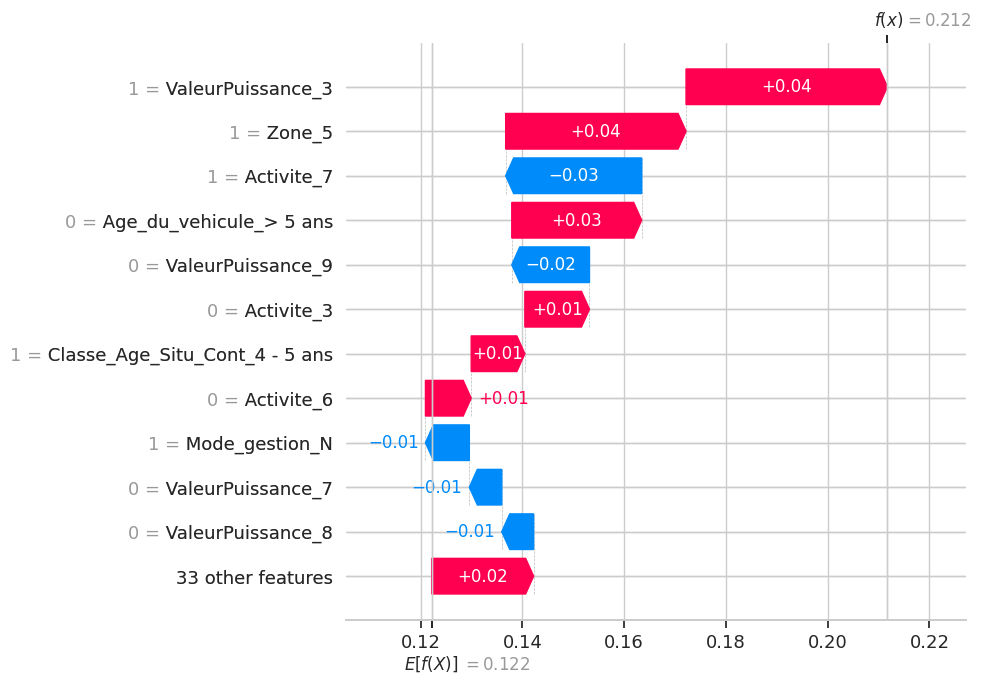

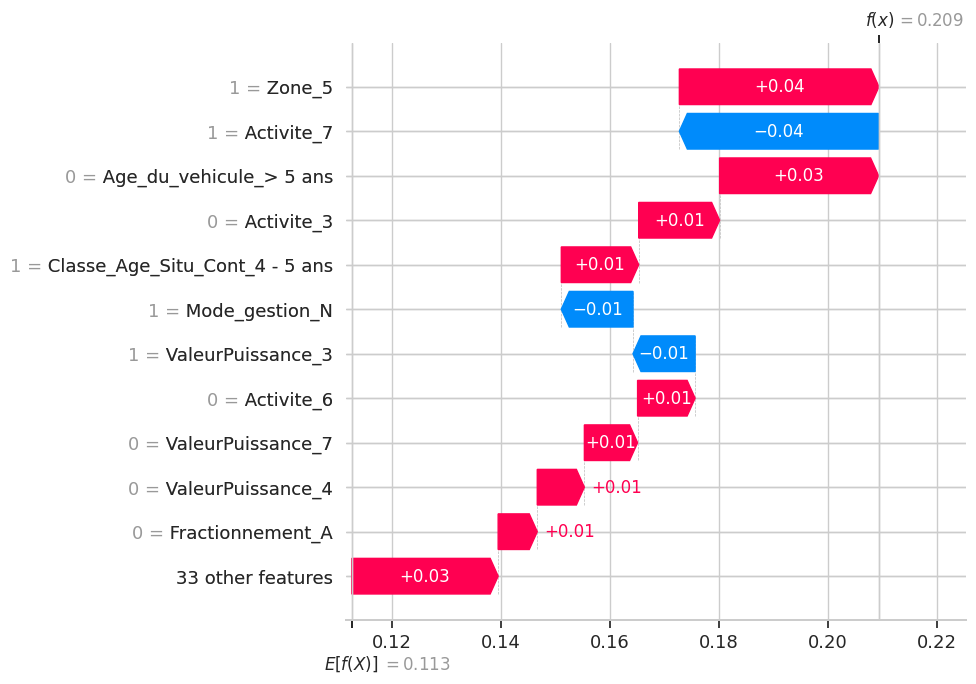


  Police 50612 :


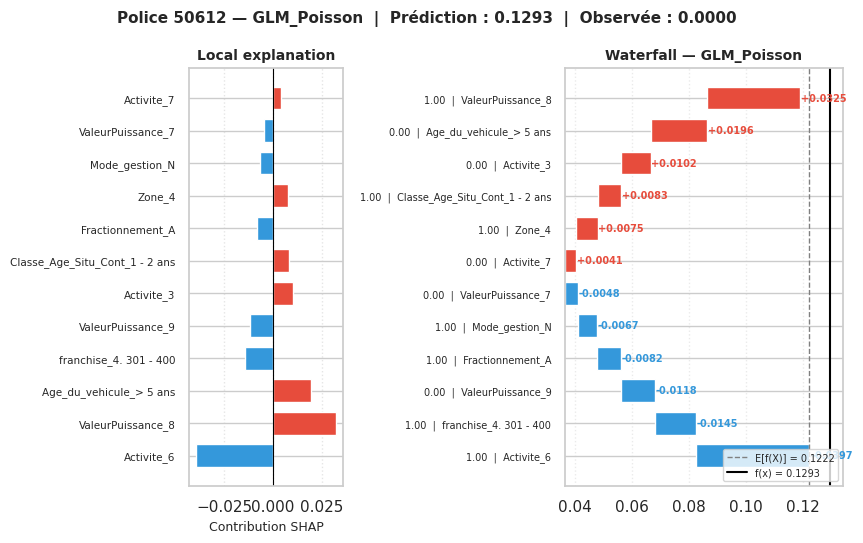

  shap_GLM_Poisson_police50612.png


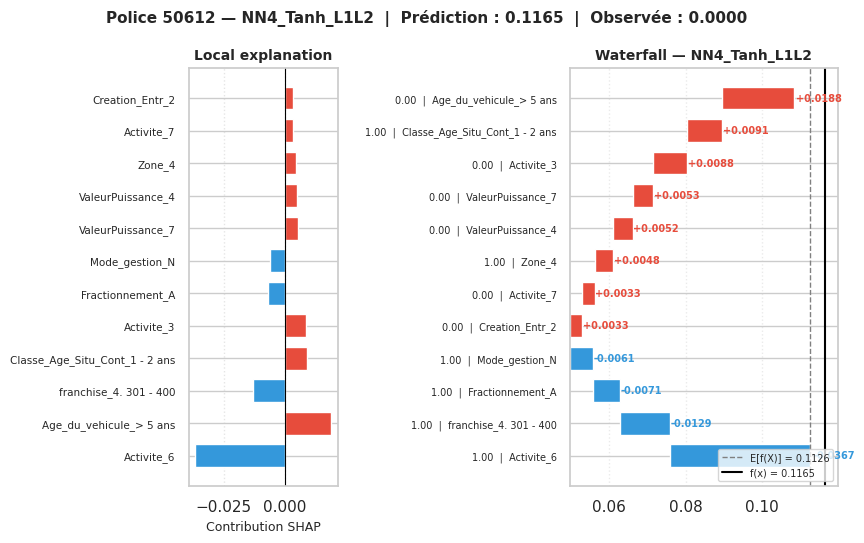

  shap_NN4_Tanh_L1L2_police50612.png

  Police 16863 :


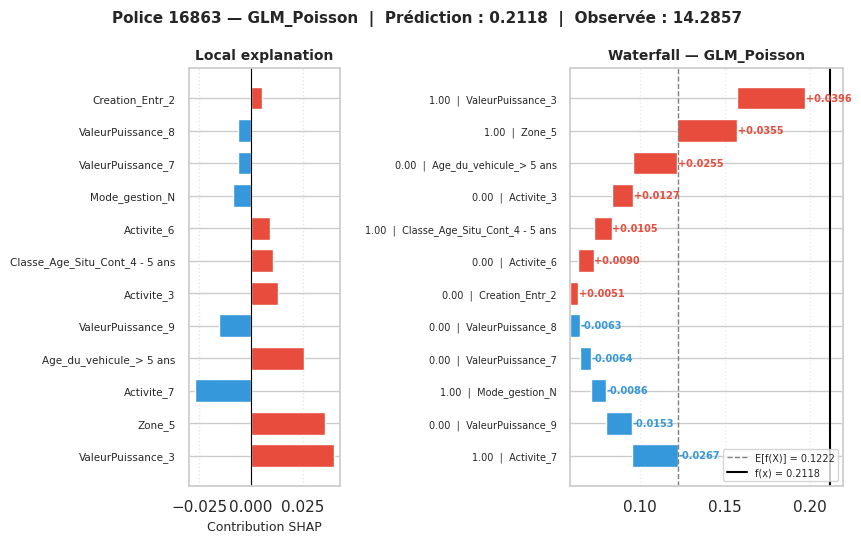

  shap_GLM_Poisson_police16863.png


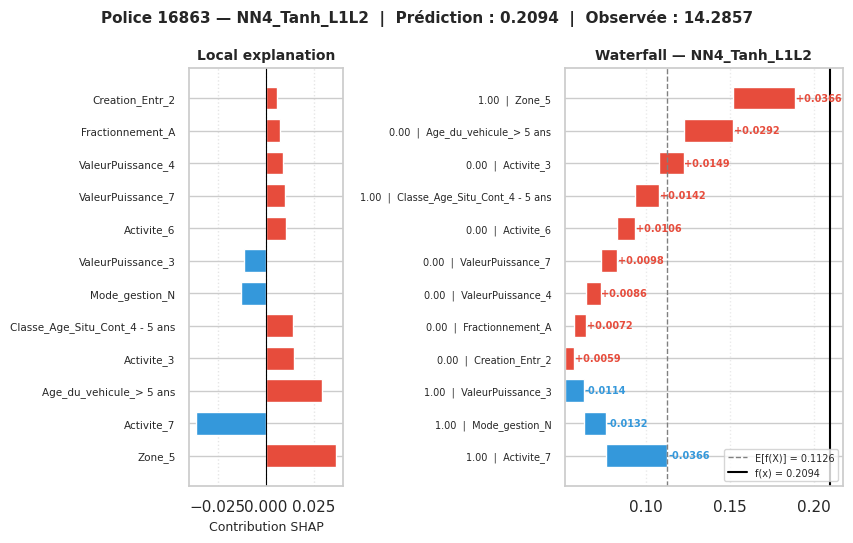

  shap_NN4_Tanh_L1L2_police16863.png

  Calcul LIME ...

  Police 50612 :


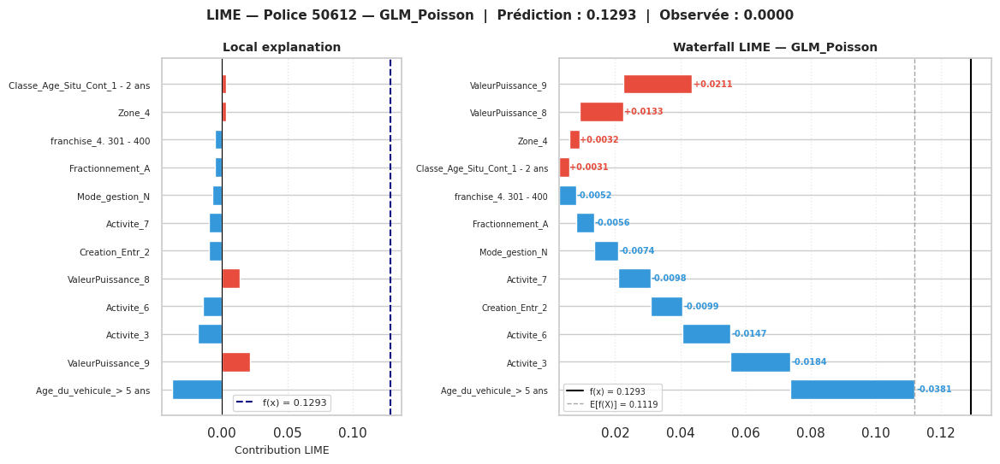

  lime_GLM_Poisson_police50612.png


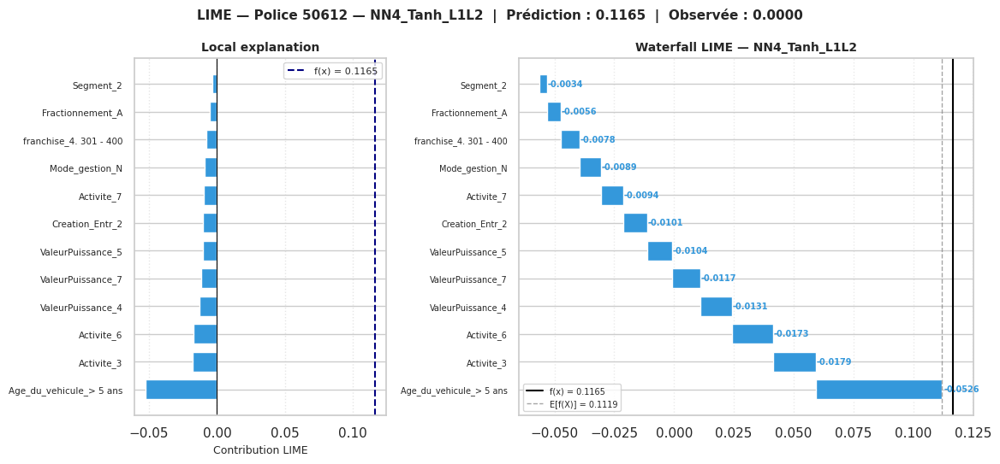

  lime_NN4_Tanh_L1L2_police50612.png

  Police 16863 :


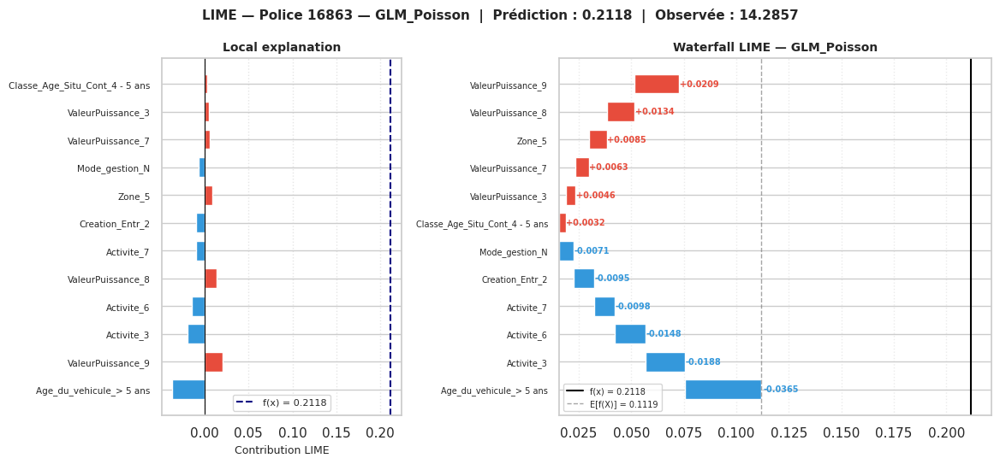

  lime_GLM_Poisson_police16863.png


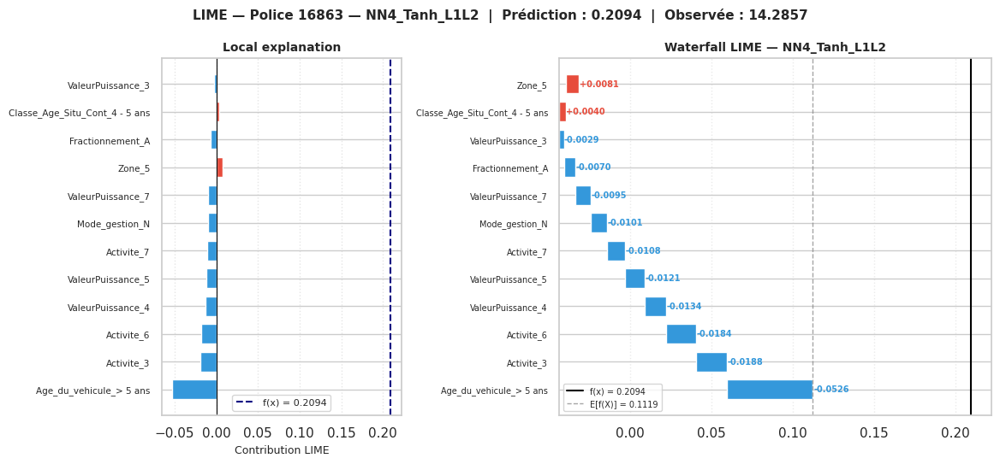

  lime_NN4_Tanh_L1L2_police16863.png

  Tableau résumé — deux polices :
 Police  Freq_Obs  Freq_GLM  Freq_NN
  50612  0.000000    0.1293   0.1165
  16863 14.285714    0.2118   0.2094


█████████████████████████████████████████████████████████████████
  PARTIE 2 — APPRENTISSAGE NON SUPERVISÉ
█████████████████████████████████████████████████████████████████


In [ ]:
# ══════════════════════════════════════════════════════════════════
#  12. LIME & SHAPLEY VALUES (Section 1.3)
#      Polices analysées : 50612 et 16863
# ══════════════════════════════════════════════════════════════════
!pip install lime shap --quiet
import shap
import lime
import lime.lime_tabular

print("\n" + "="*60)
print("  12. LIME & SHAPLEY VALUES")
print("="*60)

TARGET_IDS = [50612, 16863]

for tid in TARGET_IDS:
    if tid in data.index:
        row = data.loc[tid]
        print(f"\n  Police id={tid} :")
        print(f"    Fréquence obs : {row['Frequence']:.4f}")
        print(f"    Exposition    : {row['Exposition_au_risque']:.4f}")
        print(f"    Sinistres     : {row['nombre_de_sinistre']}")
    else:
        print(f"\n  [ERREUR] Police id={tid} introuvable dans data.index")

for tid in TARGET_IDS:
    matches = np.where(idx_val == tid)[0]
    if len(matches) > 0:
        print(f"  id={tid} → position {matches[0]} dans X_val")
    else:
        matches_tr = np.where(idx_train == tid)[0]
        if len(matches_tr) > 0:
            print(f"  id={tid} → dans X_train (position {matches_tr[0]})")


def get_policy_vector(policy_id):
    matches_val = np.where(idx_val   == policy_id)[0]
    matches_tr  = np.where(idx_train == policy_id)[0]
    if len(matches_val) > 0:
        return X_val[matches_val[0]], 'val', matches_val[0]
    elif len(matches_tr) > 0:
        return X_train[matches_tr[0]], 'train', matches_tr[0]
    elif policy_id in data.index:
        row_data = data.loc[policy_id]
        x_dum = pd.get_dummies(
            pd.DataFrame([row_data[all_existing]]),
            drop_first=False, dtype=float)
        for col, ref in references.items():
            ref_col = f"{col}_{ref}"
            if ref_col in x_dum.columns:
                x_dum.drop(columns=[ref_col], inplace=True)
        x_dum = x_dum.reindex(columns=X_dummies.columns, fill_value=0)
        return x_dum.values[0].astype("float32"), 'computed', 0
    else:
        print(f"  [ERREUR] Police {policy_id} introuvable.")
        return None, None, None


x_50612, src1, _ = get_policy_vector(50612)
x_16863, src2, _ = get_policy_vector(16863)

freq_pred_glm_50612 = glm.predict(x_50612.reshape(1, -1))[0]
freq_pred_nn_50612  = kr.predict(x_50612.reshape(1, -1))[0]
freq_pred_glm_16863 = glm.predict(x_16863.reshape(1, -1))[0]
freq_pred_nn_16863  = kr.predict(x_16863.reshape(1, -1))[0]

def get_obs_freq(policy_id):
    return data.loc[policy_id, 'Frequence'] if policy_id in data.index else None

freq_obs_50612 = get_obs_freq(50612)
freq_obs_16863 = get_obs_freq(16863)

print(f"\n  Police 50612 — GLM : {freq_pred_glm_50612:.4f}  |  NN : {freq_pred_nn_50612:.4f}"
      f"  |  Obs : {freq_obs_50612}")
print(f"  Police 16863 — GLM : {freq_pred_glm_16863:.4f}  |  NN : {freq_pred_nn_16863:.4f}"
      f"  |  Obs : {freq_obs_16863}")

# ── SHAP ──
print("\n  Calcul SHAP ...")
X_100 = shap.utils.sample(X_train, 100, random_state=SEED)

explainer_glm_shap = shap.Explainer(glm.predict, X_100, feature_names=feature_names)
explainer_nn_shap  = shap.Explainer(kr.predict,  X_100, feature_names=feature_names)

shap_glm_50612 = explainer_glm_shap(x_50612.reshape(1, -1))
shap_glm_16863 = explainer_glm_shap(x_16863.reshape(1, -1))
shap_nn_50612  = explainer_nn_shap(x_50612.reshape(1, -1))
shap_nn_16863  = explainer_nn_shap(x_16863.reshape(1, -1))

print("  Waterfall SHAP — GLM et NN :")
shap.plots.waterfall(shap_glm_50612[0], max_display=12)
shap.plots.waterfall(shap_nn_50612[0],  max_display=12)
shap.plots.waterfall(shap_glm_16863[0], max_display=12)
shap.plots.waterfall(shap_nn_16863[0],  max_display=12)


def plot_shap_custom(shap_values, policy_id, model_name,
                     freq_pred, freq_obs=None, max_display=12,
                     figsize=(22*cm, 14*cm)):
    """Waterfall SHAP custom avec barplot local et waterfall cumulatif."""
    sv     = shap_values.values[0]
    base_v = shap_values.base_values[0]
    order  = np.argsort(np.abs(sv))[::-1][:max_display]

    top_sv  = sv[order]
    top_fn  = [feature_names[i] for i in order]
    top_val = shap_values.data[0][order]

    # Tri pour waterfall : croissant
    wf_order = np.argsort(top_sv)
    wsv  = top_sv[wf_order]
    wfn  = [top_fn[i] for i in wf_order]
    wval = top_val[wf_order]
    colors_wf = ['#e74c3c' if v > 0 else '#3498db' for v in wsv]

    fig, axes = plt.subplots(1, 2, figsize=figsize,
                              gridspec_kw={'width_ratios': [1, 1.8]})

    # Panneau gauche : barplot local
    ax1   = axes[0]
    y_pos = np.arange(len(top_sv))[::-1]
    ax1.barh(y_pos, top_sv[::-1],
             color=['#e74c3c' if v > 0 else '#3498db' for v in top_sv[::-1]],
             edgecolor='white', height=0.7)
    ax1.set_yticks(y_pos)
    ax1.set_yticklabels(top_fn[::-1], fontsize=7.5)
    ax1.axvline(0, color='black', linewidth=0.8)
    ax1.set_xlabel("Contribution SHAP", fontsize=9)
    ax1.set_title("Local explanation", fontsize=10, fontweight='bold')
    ax1.xaxis.grid(True, linestyle=':', alpha=0.5)
    ax1.set_axisbelow(True)

    # Panneau droit : waterfall cumulatif
    ax2 = axes[1]
    starts = []; cumul = base_v
    for v in wsv:
        starts.append(cumul); cumul += v
    ends = np.array(starts) + wsv
    y_wf = np.arange(len(wsv))

    for i, (st, v, c) in enumerate(zip(starts, wsv, colors_wf)):
        ax2.barh(y_wf[i], v, left=st, color=c, edgecolor='white', height=0.7)
        txt = f"+{v:.4f}" if v > 0 else f"{v:.4f}"
        ax2.text(max(st, ends[i]) + abs(v) * 0.02, i, txt,
                 va='center', ha='left', fontsize=7, fontweight='bold',
                 color='#e74c3c' if v > 0 else '#3498db')

    wlabels = [f"{wval[i]:.2f}  |  {wfn[i]}" for i in range(len(wsv))]
    ax2.set_yticks(y_wf)
    ax2.set_yticklabels(wlabels, fontsize=7)
    ax2.axvline(base_v,    color='gray',  linewidth=1.0, linestyle='--',
                label=f"E[f(X)] = {base_v:.4f}")
    ax2.axvline(freq_pred, color='black', linewidth=1.5,
                label=f"f(x) = {freq_pred:.4f}")
    ax2.set_title(f"Waterfall — {model_name}", fontsize=10, fontweight='bold')
    ax2.legend(fontsize=7, loc='lower right')
    ax2.xaxis.grid(True, linestyle=':', alpha=0.4)
    ax2.set_axisbelow(True)

    titre = f"Police {policy_id} — {model_name}  |  Prédiction : {freq_pred:.4f}"
    if freq_obs is not None:
        titre += f"  |  Observée : {freq_obs:.4f}"
    plt.suptitle(titre, fontsize=11, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f"shap_{model_name}_police{policy_id}.png", dpi=150)
    plt.show()
    print(f"  shap_{model_name}_police{policy_id}.png")


print("\n  Police 50612 :")
plot_shap_custom(shap_glm_50612, 50612, 'GLM_Poisson',
                 freq_pred_glm_50612, freq_obs_50612)
plot_shap_custom(shap_nn_50612, 50612, best_nn['Modele'],
                 freq_pred_nn_50612, freq_obs_50612)

print("\n  Police 16863 :")
plot_shap_custom(shap_glm_16863, 16863, 'GLM_Poisson',
                 freq_pred_glm_16863, freq_obs_16863)
plot_shap_custom(shap_nn_16863, 16863, best_nn['Modele'],
                 freq_pred_nn_16863, freq_obs_16863)

# ── LIME ──
print("\n  Calcul LIME ...")
explainer_lime = lime.lime_tabular.LimeTabularExplainer(
    training_data         = X_train.astype("float32"),
    feature_names         = feature_names,
    mode                  = 'regression',
    discretize_continuous = False,
    random_state          = SEED)


def plot_lime_custom(policy_vec, policy_id, model_predict, model_name,
                     freq_pred, freq_obs=None, num_features=12,
                     figsize=(30*cm, 14*cm)):
    """LIME barplot + waterfall cumulatif style prof."""
    exp = explainer_lime.explain_instance(
        data_row   = policy_vec.astype("float64"),
        predict_fn = lambda X: model_predict(X.astype("float32")),
        num_features=num_features, num_samples=5000)

    contrib    = exp.as_list()
    c_names    = [c[0] for c in contrib]
    c_vals     = np.array([c[1] for c in contrib])
    colors_bar = ['#e74c3c' if v > 0 else '#3498db' for v in c_vals]

    # Tri pour waterfall
    sort_idx  = np.argsort(c_vals)
    sv_sorted = c_vals[sort_idx]
    fn_sorted = [c_names[i] for i in sort_idx]

    fig, axes = plt.subplots(1, 2, figsize=figsize,
                              gridspec_kw={'width_ratios': [1, 1.8]})

    # Panneau gauche
    ax1 = axes[0]
    y_pos = np.arange(len(c_vals))[::-1]
    ax1.barh(y_pos, c_vals[::-1], color=colors_bar[::-1],
             edgecolor='white', height=0.7)
    ax1.set_yticks(y_pos)
    ax1.set_yticklabels(c_names[::-1], fontsize=7.5)
    ax1.axvline(0, color='black', linewidth=0.8)
    ax1.axvline(freq_pred, color='navy', linestyle='--', linewidth=1.5,
                label=f"f(x) = {freq_pred:.4f}")
    ax1.set_xlabel("Contribution LIME", fontsize=9)
    ax1.set_title("Local explanation", fontsize=10, fontweight='bold')
    ax1.legend(fontsize=8)
    ax1.xaxis.grid(True, linestyle=':', alpha=0.5)
    ax1.set_axisbelow(True)

    # Panneau droit : waterfall
    ax2 = axes[1]
    starts = []; cumul = freq_glob
    for v in sv_sorted:
        starts.append(cumul); cumul += v
    ends   = np.array(starts) + sv_sorted
    colors_wf = ['#e74c3c' if v > 0 else '#3498db' for v in sv_sorted]
    y_wf   = np.arange(len(sv_sorted))

    for i, (st, v, c) in enumerate(zip(starts, sv_sorted, colors_wf)):
        ax2.barh(y_wf[i], v, left=st, color=c, edgecolor='white', height=0.7)
        txt = f"+{v:.4f}" if v > 0 else f"{v:.4f}"
        ax2.text(max(st, ends[i]) + abs(v) * 0.02, i, txt,
                 va='center', ha='left', fontsize=7,
                 color='#e74c3c' if v > 0 else '#3498db',
                 fontweight='bold')

    wlabels = [f"{fn_sorted[i]}" for i in range(len(sv_sorted))]
    ax2.set_yticks(y_wf); ax2.set_yticklabels(wlabels, fontsize=7)
    ax2.axvline(freq_pred, color='black', linewidth=1.5,
                label=f"f(x) = {freq_pred:.4f}")
    ax2.axvline(freq_glob, color='gray', linewidth=1, linestyle='--',
                alpha=0.7, label=f"E[f(X)] = {freq_glob:.4f}")
    ax2.set_title(f"Waterfall LIME — {model_name}", fontsize=10, fontweight='bold')
    ax2.legend(fontsize=7)
    ax2.xaxis.grid(True, linestyle=':', alpha=0.4)
    ax2.set_axisbelow(True)

    titre = f"LIME — Police {policy_id} — {model_name}  |  Prédiction : {freq_pred:.4f}"
    if freq_obs is not None:
        titre += f"  |  Observée : {freq_obs:.4f}"
    plt.suptitle(titre, fontsize=11, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f"lime_{model_name}_police{policy_id}.png", dpi=150)
    plt.show()
    print(f"  lime_{model_name}_police{policy_id}.png")


print("\n  Police 50612 :")
plot_lime_custom(x_50612, 50612, glm.predict, 'GLM_Poisson',
                 freq_pred_glm_50612, freq_obs_50612)
plot_lime_custom(x_50612, 50612, kr.predict,  best_nn['Modele'],
                 freq_pred_nn_50612,  freq_obs_50612)

print("\n  Police 16863 :")
plot_lime_custom(x_16863, 16863, glm.predict, 'GLM_Poisson',
                 freq_pred_glm_16863, freq_obs_16863)
plot_lime_custom(x_16863, 16863, kr.predict,  best_nn['Modele'],
                 freq_pred_nn_16863,  freq_obs_16863)

print("\n  Tableau résumé — deux polices :")
print(pd.DataFrame([
    {'Police': 50612, 'Freq_Obs': freq_obs_50612,
     'Freq_GLM': round(freq_pred_glm_50612, 4),
     'Freq_NN':  round(freq_pred_nn_50612,  4)},
    {'Police': 16863, 'Freq_Obs': freq_obs_16863,
     'Freq_GLM': round(freq_pred_glm_16863, 4),
     'Freq_NN':  round(freq_pred_nn_16863,  4)},
]).to_string(index=False))


# ══════════════════════════════════════════════════════════════════
#  ────────────────  PARTIE 2 ─────────────────
#  APPRENTISSAGE NON SUPERVISÉ
#  AE, VAE, K-Means, Comparaison déviance
# ══════════════════════════════════════════════════════════════════
print("\n\n" + "█"*65)
print("  PARTIE 2 — APPRENTISSAGE NON SUPERVISÉ")
print("█"*65)



## **Variable importantes dans le meilleurs modles de Deep Learning**


  PFI — GLM Poisson  (n_repeats=10)
  ✅ GLM PFI terminé.

  PFI — NN4_Tanh_L1L2  (n_repeats=10)
  ✅ NN PFI terminé.

  PFI — GLM (trié par importance décroissante) :
            Variable  Importance     Std        Ref
     Age_du_vehicule     0.02086 0.00266   <= 5 ans
     ValeurPuissance     0.01010 0.00192          1
            Activite     0.00852 0.00235          1
                Zone     0.00254 0.00105          3
        Mode_gestion     0.00153 0.00032          P
           franchise     0.00133 0.00076 2. 1 - 200
      Type_Apporteur     0.00080 0.00076          1
             FORMULE     0.00077 0.00058          3
Classe_Age_Situ_Cont     0.00053 0.00042   <= 1 ans
       Creation_Entr     0.00035 0.00079          1
     Nombre_vehicule     0.00000 0.00000          1
      Fractionnement    -0.00019 0.00046          T
             Segment    -0.00021 0.00014          1

  PFI — NN4_Tanh_L1L2 (trié par importance décroissante) :
            Variable  Importance     Std     

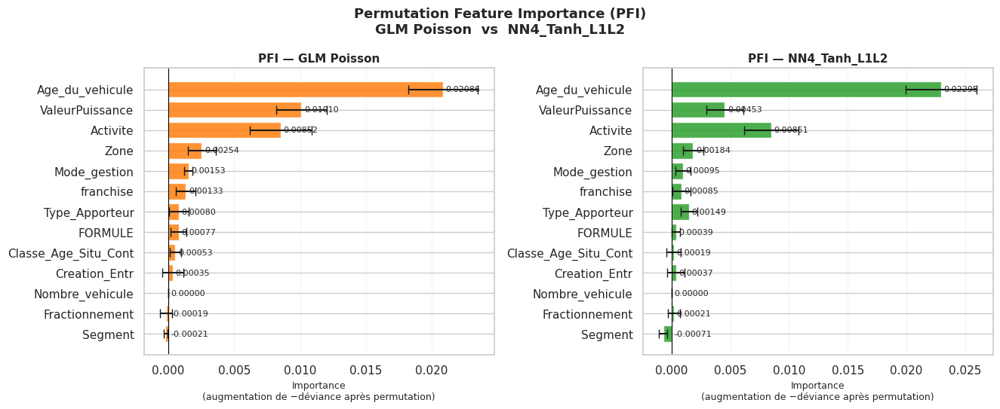

  ✅ pfi_glm_vs_nn.png


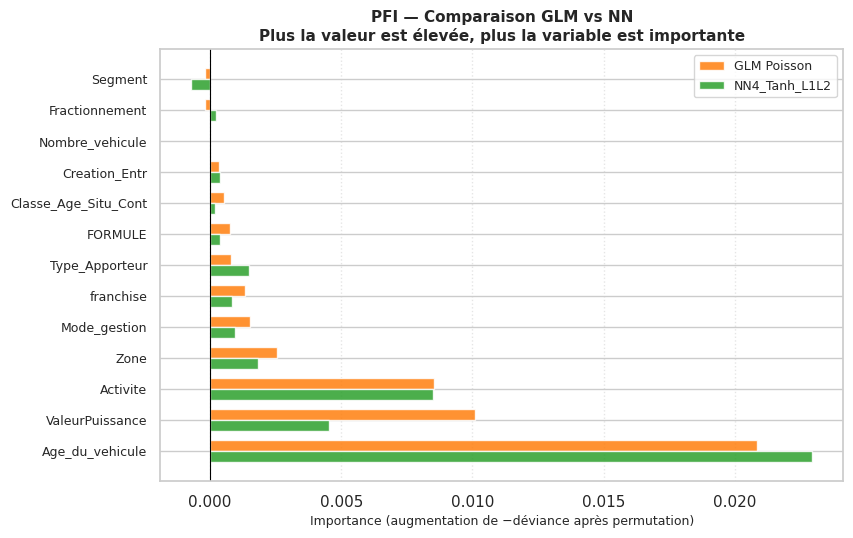

  ✅ pfi_comparaison.png

  TABLEAU RÉCAPITULATIF — PFI GLM vs NN
  (Modalité de référence = encodée comme vecteur nul)
            Variable   PFI_GLM        Ref    PFI_NN
     Age_du_vehicule  0.020859   <= 5 ans  0.022950
     ValeurPuissance  0.010096          1  0.004533
            Activite  0.008525          1  0.008506
                Zone  0.002544          3  0.001838
        Mode_gestion  0.001527          P  0.000954
           franchise  0.001326 2. 1 - 200  0.000853
      Type_Apporteur  0.000800          1  0.001486
             FORMULE  0.000773          3  0.000390
Classe_Age_Situ_Cont  0.000532   <= 1 ans  0.000191
       Creation_Entr  0.000347          1  0.000372
     Nombre_vehicule  0.000000          1  0.000000
      Fractionnement -0.000187          T  0.000214
             Segment -0.000208          1 -0.000713


In [ ]:
# ══════════════════════════════════════════════════════════════
#  PERMUTATION FEATURE IMPORTANCE (PFI)
#  Slides du prof : sklearn.inspection.permutation_importance
#
#  FIX : n_jobs=1 (évite BrokenProcessPool avec loss custom Keras)
#  Variables OHE (44 colonnes) → regroupées par variable d'origine
# ══════════════════════════════════════════════════════════════

from sklearn.inspection import permutation_importance
from sklearn.base       import BaseEstimator, RegressorMixin
from sklearn.metrics    import mean_poisson_deviance

# ── Wrapper Keras → sklearn ──
class KerasWrapperPFI(BaseEstimator, RegressorMixin):
    """
    Wrapper pour utiliser le meilleur NN avec sklearn.
    score() retourne -déviance de Poisson (à maximiser).
    """
    def __init__(self, keras_model, expo_weights):
        self.keras_model  = keras_model
        self.expo_weights = expo_weights

    def fit(self, X, y, **kwargs):
        return self

    def predict(self, X):
        return self.keras_model.predict(
            np.array(X, dtype="float32"), verbose=0).ravel()

    def score(self, X, y, sample_weight=None):
        pred = np.clip(self.predict(X), 1e-9, None)
        w    = sample_weight if sample_weight is not None else self.expo_weights
        return -mean_poisson_deviance(y, pred, sample_weight=w)


kr_pfi = KerasWrapperPFI(best_nn['model'], expo_val)

feature_names_pfi = list(X_dummies.columns)   # 44 colonnes OHE

cat_vars_orig = [c for c in [
    'Classe_Age_Situ_Cont','Creation_Entr','Mode_gestion','Zone',
    'Segment','Fractionnement','Age_du_vehicule','franchise',
    'Nombre_vehicule','FORMULE','Activite','Type_Apporteur','ValeurPuissance'
] if c in data.columns]

# ══════════════════════════════════════════════════════════════
#  1. CALCUL PFI — n_jobs=1 (FIX BrokenProcessPool)
#
#  n_jobs=-1 → joblib tente de sérialiser le modèle Keras
#              avec Poisson_deviance_loss custom → ERREUR
#  n_jobs=1  → tout dans le même processus → OK ✅
# ══════════════════════════════════════════════════════════════

print("\n" + "="*60)
print("  PFI — GLM Poisson  (n_repeats=10)")
print("="*60)

pi_glm = permutation_importance(
    glm,
    X_val,
    freq_val,
    n_repeats    = 10,
    random_state = 42,
    scoring      = 'neg_mean_poisson_deviance',
    n_jobs       = 1         # ← FIX : pas de multiprocessing
)

print(f"  ✅ GLM PFI terminé.")

print("\n" + "="*60)
print(f"  PFI — {best_nn['Modele']}  (n_repeats=10)")
print("="*60)

pi_nn = permutation_importance(
    kr_pfi,
    X_val,
    freq_val,
    n_repeats    = 10,
    random_state = 42,
    scoring      = 'neg_mean_poisson_deviance',
    n_jobs       = 1         # ← FIX : pas de multiprocessing
)

print(f"  ✅ NN PFI terminé.")

# ══════════════════════════════════════════════════════════════
#  2. REGROUPEMENT PAR VARIABLE D'ORIGINE
#
#  drop_first=True → modalité de référence absente du dataset
#  → PFI permute les colonnes NON-référence uniquement
#  → importance = somme des importances des colonnes OHE
#  → la modalité de référence contribue via l'intercept
# ══════════════════════════════════════════════════════════════

def aggregate_pfi_by_var(pi_result, feature_names, cat_vars, data, references):
    """
    Regroupe les importances OHE par variable d'origine.

    Note : avec drop_first=True, la modalité de référence
    est encodée comme le vecteur nul et n'a pas de colonne
    dans X_train. Son importance est implicitement nulle.
    PFI(var) mesure l'importance des modalités non-référence
    relativement à la modalité de référence.
    """
    rows = []
    for var in cat_vars:
        cols_idx = [i for i, f in enumerate(feature_names)
                    if f.startswith(f"{var}_")]
        if not cols_idx:
            continue

        imp_mean = pi_result.importances_mean[cols_idx].sum()
        imp_std  = np.sqrt((pi_result.importances_std[cols_idx]**2).sum())

        rows.append({
            'Variable'     : var,
            'Importance'   : imp_mean,
            'Std'          : imp_std,
            'N_modalites'  : data[var].nunique(),
            'N_OHE'        : len(cols_idx),
            'Ref'          : str(references.get(var, 'N/A'))
        })

    return (pd.DataFrame(rows)
              .sort_values('Importance', ascending=False)
              .reset_index(drop=True))


pfi_glm_df = aggregate_pfi_by_var(
    pi_glm, feature_names_pfi, cat_vars_orig, data, references)
pfi_nn_df  = aggregate_pfi_by_var(
    pi_nn,  feature_names_pfi, cat_vars_orig, data, references)

print("\n  PFI — GLM (trié par importance décroissante) :")
print(pfi_glm_df[['Variable','Importance','Std','Ref']].round(5).to_string(index=False))

print(f"\n  PFI — {best_nn['Modele']} (trié par importance décroissante) :")
print(pfi_nn_df[['Variable','Importance','Std','Ref']].round(5).to_string(index=False))

# ══════════════════════════════════════════════════════════════
#  3. GRAPHIQUES PFI — GLM vs NN séparés
# ══════════════════════════════════════════════════════════════
vars_order = pfi_glm_df['Variable'].tolist()
pfi_nn_aligned = (pfi_nn_df.set_index('Variable')
                            .reindex(vars_order)
                            .reset_index()
                            .fillna(0))

fig, axes = plt.subplots(1, 2, figsize=(34*cm, 14*cm))

for ax, df, color, title in [
    (axes[0], pfi_glm_df,    '#ff7f0e', 'PFI — GLM Poisson'),
    (axes[1], pfi_nn_aligned, '#2ca02c', f'PFI — {best_nn["Modele"]}'),
]:
    bars = ax.barh(
        df['Variable'][::-1],
        df['Importance'][::-1],
        xerr      = df['Std'][::-1],
        color     = color,
        edgecolor = 'white',
        capsize   = 4,
        alpha     = 0.85
    )
    for bar, val in zip(bars, df['Importance'][::-1]):
        ax.text(max(bar.get_width(), 0) + df['Importance'].max()*0.01,
                bar.get_y() + bar.get_height()/2,
                f"{val:.5f}", va='center', fontsize=8)

    ax.axvline(x=0, color='black', linewidth=0.8)
    ax.set_title(title, fontweight='bold', fontsize=11)
    ax.set_xlabel("Importance\n(augmentation de −déviance après permutation)",
                  fontsize=9)
    ax.xaxis.grid(True, linestyle=':', alpha=0.5)
    ax.set_axisbelow(True)

plt.suptitle("Permutation Feature Importance (PFI)\n"
             f"GLM Poisson  vs  {best_nn['Modele']}",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("pfi_glm_vs_nn.png", dpi=150, bbox_inches='tight')
plt.show()
print("  ✅ pfi_glm_vs_nn.png")

# ══════════════════════════════════════════════════════════════
#  4. GRAPHIQUE COMPARAISON DIRECTE — barres groupées
# ══════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(22*cm, 14*cm))

x = np.arange(len(vars_order))
w = 0.35

ax.barh(x + w/2, pfi_glm_df['Importance'],
        height=w, color='#ff7f0e', edgecolor='white',
        label='GLM Poisson', alpha=0.85)
ax.barh(x - w/2, pfi_nn_aligned['Importance'],
        height=w, color='#2ca02c', edgecolor='white',
        label=best_nn['Modele'], alpha=0.85)

ax.set_yticks(x)
ax.set_yticklabels(vars_order, fontsize=9)
ax.axvline(x=0, color='black', linewidth=0.8)
ax.set_xlabel("Importance (augmentation de −déviance après permutation)", fontsize=9)
ax.set_title("PFI — Comparaison GLM vs NN\n"
             "Plus la valeur est élevée, plus la variable est importante",
             fontweight='bold', fontsize=11)
ax.legend(fontsize=9)
ax.xaxis.grid(True, linestyle=':', alpha=0.5)
ax.set_axisbelow(True)
plt.tight_layout()
plt.savefig("pfi_comparaison.png", dpi=150, bbox_inches='tight')
plt.show()
print("  pfi_comparaison.png")

# ══════════════════════════════════════════════════════════════
#  5. TABLEAU RÉCAPITULATIF
# ══════════════════════════════════════════════════════════════
recap = (pfi_glm_df[['Variable','Importance','Ref']]
         .rename(columns={'Importance':'PFI_GLM'})
         .merge(
             pfi_nn_df[['Variable','Importance']]
             .rename(columns={'Importance':f'PFI_NN'}),
             on='Variable', how='outer')
         .fillna(0)
         .sort_values('PFI_GLM', ascending=False)
         .reset_index(drop=True))

print("\n" + "="*65)
print("  TABLEAU RÉCAPITULATIF — PFI GLM vs NN")
print("  (Modalité de référence = encodée comme vecteur nul)")
print("="*65)
print(recap.round(6).to_string(index=False))

# **APPRENTISSAGE NON SUPERVISE**


  13. OHE POUR AUTO-ENCODEURS
  OHE shape : (87228, 57)  |  nc = 57
  Train : 69,782  |  Val : 17,446
  Fréquence globale pondérée : 0.1185

  SECTION 2.1 — QUALITÉ DE RECONSTRUCTION AE & VAE

  AE1 — [nc→80→40→20→10]  |  Loss : BCE


Model: "AE1_Simple"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ encoder_AE1 (Sequential)        │ (None, 10)             │         8,910 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_AE1 (Sequential)        │ (None, 57)             │         6,137 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,047 (58.78 KB)

 Trainable params: 15,047 (58.78 KB)

 Non-trainable params: 0 (0.00 B)

  BCE val_loss min : 0.2347  |  KL divergence : 0.6589

  AE2 — [nc→150→100→50→10→5]  |  Loss : BCE


Model: "AE2_Deep"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ encoder_AE2 (Sequential)        │ (None, 5)              │        29,415 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_AE2 (Sequential)        │ (None, 57)             │        29,467 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 58,882 (230.01 KB)

 Trainable params: 58,882 (230.01 KB)

 Non-trainable params: 0 (0.00 B)

  BCE val_loss min : 0.0552  |  KL divergence : 0.1478

  VAE1 — ELBO Bernoulli  (latent=10)  |  [100→50]
  ELBO val_loss min : 76.460  |  KL divergence : 1.0211

  VAE2 — ELBO Bernoulli  (latent=5)  |  [150→100→50→10]
  ELBO val_loss min : 76.459  |  KL divergence : 1.0211

  TABLEAU 2.1 — QUALITÉ DE RECONSTRUCTION
       Modèle  latent space dim  loss+ELBO  KL divergence
   AE1_Simple                10     0.2347         0.6589
     AE2_Deep                 5     0.0552         0.1478
     VAE1_BCE                10    76.4600         1.0211
VAE2_BCE_Deep                 5    76.4590         1.0211


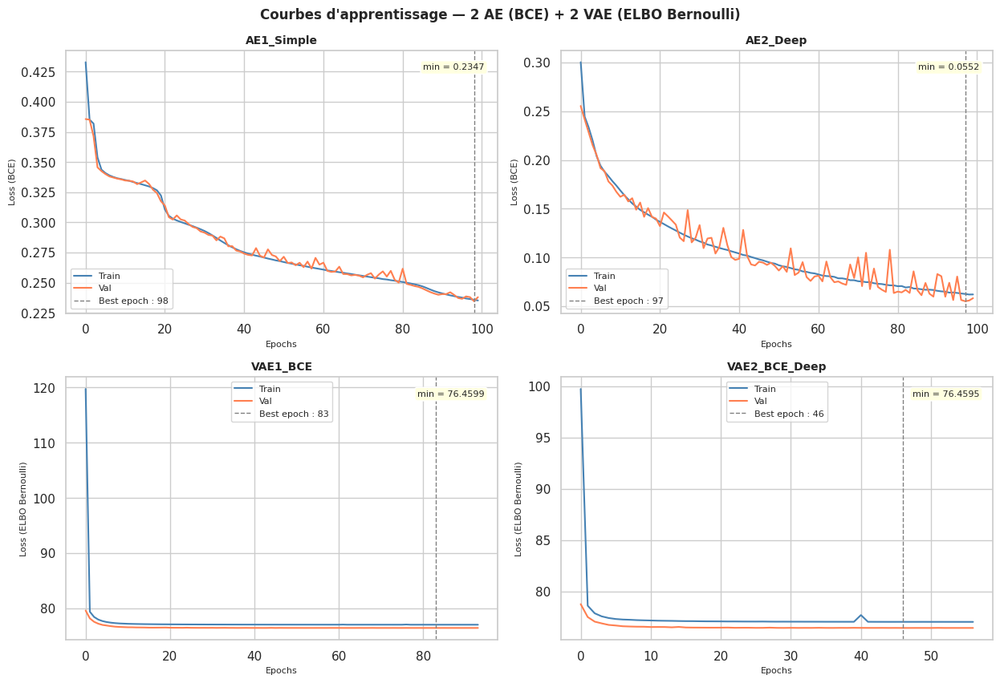

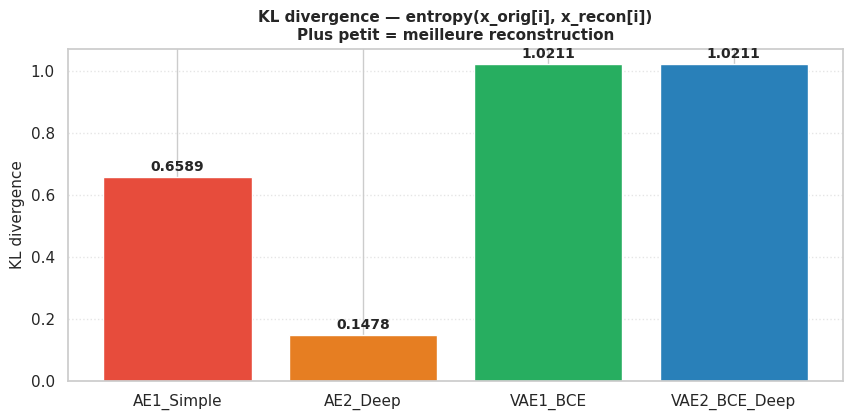

In [ ]:

# ══════════════════════════════════════════════════════════════════
#  13. OHE POUR AE/VAE
#      drop_first=False → TOUTES les colonnes gardées
#      Les AE/VAE doivent reconstruire la distribution complète
# ══════════════════════════════════════════════════════════════════
print("\n" + "="*60)
print("  13. OHE POUR AUTO-ENCODEURS")
print("="*60)

ae_vars = [c for c in [
    'Classe_Age_Situ_Cont', 'Creation_Entr', 'Mode_gestion', 'Zone',
    'Segment', 'Fractionnement', 'Age_du_vehicule', 'franchise',
    'Nombre_vehicule', 'FORMULE', 'Activite', 'Type_Apporteur', 'ValeurPuissance'
] if c in data.columns]

X_ae_df = pd.get_dummies(data[ae_vars], drop_first=False, dtype=float)
X_ae    = X_ae_df.values.astype("float32")
nc      = X_ae.shape[1]
print(f"  OHE shape : {X_ae.shape}  |  nc = {nc}")

X_ae_tr, X_ae_va, X_ae_df_tr, X_ae_df_va = train_test_split(
    X_ae, X_ae_df, test_size=0.2, random_state=SEED)
print(f"  Train : {X_ae_tr.shape[0]:,}  |  Val : {X_ae_va.shape[0]:,}")

# Fréquence globale pondérée pour K-means
freq_glob_ae = np.average(data['Frequence'],
                            weights=data['Exposition_au_risque'])
print(f"  Fréquence globale pondérée : {freq_glob_ae:.4f}")


def make_ae_callbacks(patience=10):
    return [keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=patience,
        restore_best_weights=True, verbose=0)]

def kl_mathias(X_df, recon):
    """
    KL divergence — code exact Mathias :
    entropy(x_orig[i], x_recon[i]) moyenné sur les observations.
    Plus petit = meilleure reconstruction.
    """
    return np.round(np.mean([
        entropy(X_df.iloc[i], recon[i]) for i in range(len(X_df))
    ]), 4)


# ══════════════════════════════════════════════════════════════════
#  14. CLASSE VAE — CODE EXACT DU PROF (Hainaut)
#
#  call()  → z, z_mean, z_log_var, reconstruction
#  encode() → z_mean déterministe pour K-means (pas de bruit)
#
#  ELBO (wgt fourni) :
#    reconstruction_loss = 0.5 * Σ ((x-x̂)/wgt)²   [MSE pondérée]
#    kl_loss             = -0.5 * Σ (1 + log_var - μ² - exp(log_var))
#
#  ELBO (wgt=None) :
#    reconstruction_loss = Σ BCE(x, x̂)              [Bernoulli]
#    kl_loss             = identique
#
#  Ici on utilise wgt=None pour les deux VAE car variables binaires (0/1).
# ══════════════════════════════════════════════════════════════════
class VAE(keras.Model):
    def __init__(self, encoder, decoder, wgt=None, **kwargs):
        super(VAE, self).__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder
        self.wgt     = (tf.constant(wgt, dtype=tf.float32)
                        if wgt is not None else None)
        self.loss_tracker = keras.metrics.Mean(name="loss")

    @property
    def metrics(self):
        return [self.loss_tracker]

    def _sampling(self, z_mean, z_log_var):
        """Reparametrization trick — code exact du prof."""
        epsilon = tf.random.normal(shape=tf.shape(z_mean))
        return z_mean + tf.exp(0.5 * z_log_var) * epsilon

    def _VAE_loss(self, inputs, outputs, z_mean, z_log_var):
        """
        ELBO du prof :
          wgt fourni → reconstruction_loss = 0.5 * Σ((x-x̂)/wgt)²
          wgt=None   → reconstruction_loss = Σ BCE(x, x̂)  [Bernoulli]
          kl_loss    = -0.5 * Σ(1 + log_var - μ² - exp(log_var))
        """
        if self.wgt is not None:
            reconstruction_loss = 0.5 * tf.reduce_sum(
                tf.square((inputs - outputs) / self.wgt))
        else:
            # BCE Bernoulli — pour données binaires (OHE 0/1)
            reconstruction_loss = tf.reduce_sum(
                keras.losses.binary_crossentropy(inputs, outputs))

        kl_loss = -0.5 * tf.reduce_sum(
            1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var))

        return reconstruction_loss + kl_loss

    def call(self, inputs):
        """Retourne z, z_mean, z_log_var, reconstruction."""
        z_mean, z_log_var = self.encoder(inputs)
        z                 = self._sampling(z_mean, z_log_var)
        reconstruction    = self.decoder(z)
        return z, z_mean, z_log_var, reconstruction

    def train_step(self, data):
        x = data[0] if isinstance(data, (tuple, list)) else data
        with tf.GradientTape() as tape:
            z_mean, z_log_var = self.encoder(x)
            z                 = self._sampling(z_mean, z_log_var)
            reconstruction    = self.decoder(z)
            loss              = self._VAE_loss(x, reconstruction,
                                               z_mean, z_log_var)
        grads = tape.gradient(loss, self.trainable_variables)
        self.optimizer.apply_gradients(zip(grads, self.trainable_variables))
        self.loss_tracker.update_state(loss)
        return {"loss": self.loss_tracker.result()}

    def test_step(self, data):
        x                 = data[0] if isinstance(data, (tuple, list)) else data
        z_mean, z_log_var = self.encoder(x)
        z                 = self._sampling(z_mean, z_log_var)
        reconstruction    = self.decoder(z)
        loss              = self._VAE_loss(x, reconstruction, z_mean, z_log_var)
        self.loss_tracker.update_state(loss)
        return {"loss": self.loss_tracker.result()}

    def encode(self, X):
        """z_mean déterministe — pour K-means (pas de reparametrization)."""
        z_mean, _ = self.encoder(X)
        return z_mean


def build_encoder_vae(nc, coding_size, hidden_sizes, name):
    inputs    = layers.Input(shape=[nc])
    x         = inputs
    for h in hidden_sizes:
        x = layers.Dense(h, activation="selu")(x)
    z_mean    = layers.Dense(coding_size, name="z_mean")(x)
    z_log_var = layers.Dense(coding_size, name="z_log_var")(x)
    return keras.Model(inputs, [z_mean, z_log_var], name=name)

def build_decoder_vae(nc, coding_size, hidden_sizes, name):
    inputs = layers.Input(shape=[coding_size])
    x      = inputs
    for h in hidden_sizes:
        x = layers.Dense(h, activation="selu")(x)
    out = layers.Dense(nc, activation="sigmoid")(x)
    return keras.Model(inputs, out, name=name)


# ══════════════════════════════════════════════════════════════════
#  SECTION 2.1 — ENTRAÎNEMENT 4 MODÈLES
# ══════════════════════════════════════════════════════════════════
print("\n" + "="*65)
print("  SECTION 2.1 — QUALITÉ DE RECONSTRUCTION AE & VAE")
print("="*65)

quality_results = []

# ─────────────────────────────────────────────
#  AE1 — [nc→80→40→20→10] Loss : BCE
# ─────────────────────────────────────────────
print("\n  AE1 — [nc→80→40→20→10]  |  Loss : BCE")
coding_size_ae1 = 10

encoder_ae1 = keras.Sequential([
    layers.Dense(80, activation="sigmoid", input_shape=[nc]),
    layers.Dense(40, activation="relu"),
    layers.Dense(20, activation="relu"),
    layers.Dense(coding_size_ae1, activation="sigmoid")
], name="encoder_AE1")

decoder_ae1 = keras.Sequential([
    layers.Dense(80, activation="sigmoid", input_shape=[coding_size_ae1]),
    layers.Dense(40, activation="relu"),
    layers.Dense(20, activation="relu"),
    layers.Dense(nc, activation="sigmoid")
], name="decoder_AE1")

ae1 = keras.Sequential([encoder_ae1, decoder_ae1], name="AE1_Simple")
ae1.compile(optimizer=keras.optimizers.RMSprop(),
            loss=keras.losses.BinaryCrossentropy())
ae1.summary()

history_ae1     = ae1.fit(X_ae_tr, X_ae_tr,
                           validation_data=(X_ae_va, X_ae_va),
                           epochs=100, batch_size=256,
                           callbacks=make_ae_callbacks(),
                           shuffle=True, verbose=0)
X_comp_ae1       = encoder_ae1.predict(X_ae,    verbose=0)
reconstruct_ae1  = ae1.predict(X_ae_va,          verbose=0)
bce_ae1          = min(history_ae1.history['val_loss'])
kl_ae1           = kl_mathias(X_ae_df_va, reconstruct_ae1)
print(f"  BCE val_loss min : {bce_ae1:.4f}  |  KL divergence : {kl_ae1}")

quality_results.append({'Modèle': 'AE1_Simple', 'latent space dim': coding_size_ae1,
                         'loss+ELBO': round(bce_ae1, 4), 'KL divergence': kl_ae1})

# ─────────────────────────────────────────────
#  AE2 — [nc→150→100→50→10→5] Loss : BCE
# ─────────────────────────────────────────────
print("\n  AE2 — [nc→150→100→50→10→5]  |  Loss : BCE")
coding_size_ae2 = 5

encoder_ae2 = keras.Sequential([
    layers.Dense(150, activation="selu", input_shape=[nc]),
    layers.Dense(100, activation="selu"),
    layers.Dense(50,  activation="selu"),
    layers.Dense(10,  activation="selu"),
    layers.Dense(coding_size_ae2, activation="sigmoid")
], name="encoder_AE2")

decoder_ae2 = keras.Sequential([
    layers.Dense(10,  activation="selu", input_shape=[coding_size_ae2]),
    layers.Dense(50,  activation="selu"),
    layers.Dense(100, activation="selu"),
    layers.Dense(150, activation="selu"),
    layers.Dense(nc,  activation="sigmoid")
], name="decoder_AE2")

ae2 = keras.Sequential([encoder_ae2, decoder_ae2], name="AE2_Deep")
ae2.compile(optimizer=keras.optimizers.RMSprop(),
            loss=keras.losses.BinaryCrossentropy())
ae2.summary()

history_ae2     = ae2.fit(X_ae_tr, X_ae_tr,
                           validation_data=(X_ae_va, X_ae_va),
                           epochs=100, batch_size=256,
                           callbacks=make_ae_callbacks(),
                           shuffle=True, verbose=0)
X_comp_ae2       = encoder_ae2.predict(X_ae,    verbose=0)
reconstruct_ae2  = ae2.predict(X_ae_va,          verbose=0)
bce_ae2          = min(history_ae2.history['val_loss'])
kl_ae2           = kl_mathias(X_ae_df_va, reconstruct_ae2)
print(f"  BCE val_loss min : {bce_ae2:.4f}  |  KL divergence : {kl_ae2}")

quality_results.append({'Modèle': 'AE2_Deep', 'latent space dim': coding_size_ae2,
                         'loss+ELBO': round(bce_ae2, 4), 'KL divergence': kl_ae2})

# ─────────────────────────────────────────────
#  VAE1 — [100→50] latent=10  |  ELBO Bernoulli (wgt=None)
# ─────────────────────────────────────────────
print("\n  VAE1 — ELBO Bernoulli  (latent=10)  |  [100→50]")
coding_size_v1 = 10

enc_v1 = build_encoder_vae(nc, coding_size_v1, [100, 50], "enc_VAE1")
dec_v1 = build_decoder_vae(nc, coding_size_v1, [50, 100], "dec_VAE1")

# wgt=None → BCE Bernoulli + KL (données binaires OHE)
vae1 = VAE(enc_v1, dec_v1, wgt=None, name="VAE1_BCE")
vae1.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-3))

history_vae1        = vae1.fit(X_ae_tr, X_ae_tr,
                                validation_data=(X_ae_va, X_ae_va),
                                epochs=100, batch_size=200,
                                callbacks=make_ae_callbacks(),
                                shuffle=True, verbose=0)
elbo_vae1           = min(history_vae1.history['val_loss'])
_, _, _, recon_vae1 = vae1.predict(X_ae_va, verbose=0)
kl_vae1             = kl_mathias(X_ae_df_va, recon_vae1)
X_comp_vae1         = vae1.encode(X_ae).numpy()
print(f"  ELBO val_loss min : {elbo_vae1:.3f}  |  KL divergence : {kl_vae1}")

quality_results.append({'Modèle': 'VAE1_BCE', 'latent space dim': coding_size_v1,
                         'loss+ELBO': round(elbo_vae1, 3), 'KL divergence': kl_vae1})

# ─────────────────────────────────────────────
#  VAE2 — [150→100→50→10] latent=5  |  ELBO Bernoulli (wgt=None)
# ─────────────────────────────────────────────
print("\n  VAE2 — ELBO Bernoulli  (latent=5)  |  [150→100→50→10]")
coding_size_v2 = 5

enc_v2 = build_encoder_vae(nc, coding_size_v2, [150, 100, 50, 10], "enc_VAE2")
dec_v2 = build_decoder_vae(nc, coding_size_v2, [10, 50, 100, 150], "dec_VAE2")

vae2 = VAE(enc_v2, dec_v2, wgt=None, name="VAE2_BCE_Deep")
vae2.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-3))

history_vae2        = vae2.fit(X_ae_tr, X_ae_tr,
                                validation_data=(X_ae_va, X_ae_va),
                                epochs=100, batch_size=200,
                                callbacks=make_ae_callbacks(),
                                shuffle=True, verbose=0)
elbo_vae2           = min(history_vae2.history['val_loss'])
_, _, _, recon_vae2 = vae2.predict(X_ae_va, verbose=0)
kl_vae2             = kl_mathias(X_ae_df_va, recon_vae2)
X_comp_vae2         = vae2.encode(X_ae).numpy()
print(f"  ELBO val_loss min : {elbo_vae2:.3f}  |  KL divergence : {kl_vae2}")

quality_results.append({'Modèle': 'VAE2_BCE_Deep', 'latent space dim': coding_size_v2,
                         'loss+ELBO': round(elbo_vae2, 3), 'KL divergence': kl_vae2})

# ── Tableau 2.1 ──
quality_df = pd.DataFrame(quality_results)
modeles    = quality_df['Modèle'].tolist()

print("\n" + "="*65)
print("  TABLEAU 2.1 — QUALITÉ DE RECONSTRUCTION")
print("="*65)
print(quality_df.to_string(index=False))

# ── Courbes d'apprentissage AE + VAE ──
fig, axes = plt.subplots(2, 2, figsize=(32*cm, 22*cm))
axes = axes.ravel()

for i, (history, name, ylabel) in enumerate([
    (history_ae1,  'AE1_Simple',    'BCE'),
    (history_ae2,  'AE2_Deep',      'BCE'),
    (history_vae1, 'VAE1_BCE',      'ELBO Bernoulli'),
    (history_vae2, 'VAE2_BCE_Deep', 'ELBO Bernoulli'),
]):
    ax    = axes[i]
    vloss = history.history['val_loss']
    best  = int(np.argmin(vloss))
    ax.plot(history.history['loss'], color='steelblue',
            linewidth=1.5, label='Train')
    ax.plot(vloss, color='coral', linewidth=1.5, label='Val')
    ax.axvline(x=best, color='gray', linestyle='--', linewidth=1,
               label=f'Best epoch : {best}')
    ax.set_title(name, fontweight='bold', fontsize=10)
    ax.set_xlabel("Epochs", fontsize=8)
    ax.set_ylabel(f"Loss ({ylabel})", fontsize=8)
    ax.legend(fontsize=8)
    ax.annotate(f"min = {vloss[best]:.4f}",
                xy=(0.97, 0.95), xycoords='axes fraction',
                ha='right', va='top', fontsize=8,
                bbox=dict(boxstyle='round', fc='lightyellow'))

plt.suptitle("Courbes d'apprentissage — 2 AE (BCE) + 2 VAE (ELBO Bernoulli)",
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig("ae_vae_learning_curves.png", dpi=150)
plt.show()

# ── Barplot KL divergence ──
fig, ax = plt.subplots(figsize=(22*cm, 11*cm))
colors_kl = ['#e74c3c', '#e67e22', '#27ae60', '#2980b9']
kl_vals   = [r['KL divergence'] for r in quality_results]
bars_kl   = ax.bar(modeles, kl_vals, color=colors_kl, edgecolor='white')
for bar, val in zip(bars_kl, kl_vals):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + max(kl_vals) * 0.01,
            f"{val:.4f}", ha='center', va='bottom',
            fontsize=10, fontweight='bold')
ax.set_title("KL divergence — entropy(x_orig[i], x_recon[i])\n"
             "Plus petit = meilleure reconstruction",
             fontweight='bold', fontsize=11)
ax.set_ylabel("KL divergence")
ax.yaxis.grid(True, linestyle=':', alpha=0.5)
ax.set_axisbelow(True)
plt.tight_layout()
plt.savefig("ae_vae_kl_table.png", dpi=150)
plt.show()


  SECTION 2.2 — K-MEANS SUR L'ESPACE LATENT

  Dimensions des espaces latents :
    AE1_Simple           → shape (87228, 10)
    AE2_Deep             → shape (87228, 5)
    VAE1_BCE             → shape (87228, 10)
    VAE2_BCE_Deep        → shape (87228, 5)

  K-MEANS — AE1_Simple
  k= 3 | inertia= 39740.805 | dev=0.6739
  k= 5 | inertia= 24278.934 | dev=0.6705
  k=10 | inertia= 13904.516 | dev=0.6680
  k=12 | inertia= 11919.356 | dev=0.6675
  k=15 | inertia=  9661.065 | dev=0.6677
  k=18 | inertia=  8224.208 | dev=0.6671
  k=20 | inertia=  7521.337 | dev=0.6665

  Résumé :
k                 3           5          10          12         15         18         20
inertia   39740.8050  24278.9340  13904.516  11919.3560  9661.0650  8224.2080  7521.3370
deviance      0.6739      0.6705      0.668      0.6675     0.6677     0.6671     0.6665

  → Meilleur k = 20


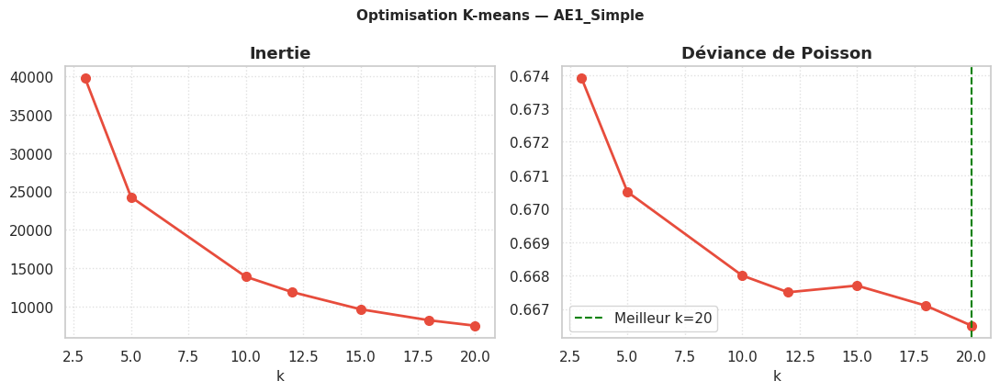

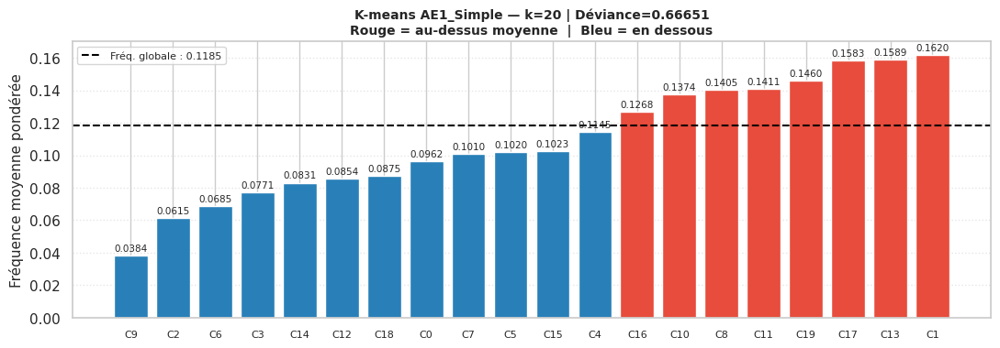


  TABLEAU CLUSTERS (AE1_Simple, k=20) :
 Cluster Classe_Age_Situ_Cont Creation_Entr Mode_gestion Zone Segment Fractionnement Age_du_vehicule    franchise Nombre_vehicule FORMULE Activite Type_Apporteur ValeurPuissance  N_obs Freq_moy     Expo
       9              > 5 ans             1            N    1       2              A         > 5 ans   2. 1 - 200               1       5        3              1               4   1476   0.0384   469.16
       2             <= 1 ans             1            P    3       2              T         > 5 ans   2. 1 - 200               1       3        3              2               4   2004   0.0615  1365.71
       6              > 5 ans             1            N    1       2              T         > 5 ans   2. 1 - 200               1       3        3              1               4   2369   0.0685   700.36
       3              > 5 ans             1            N    1       1              A         > 5 ans   2. 1 - 200               1       3        6 

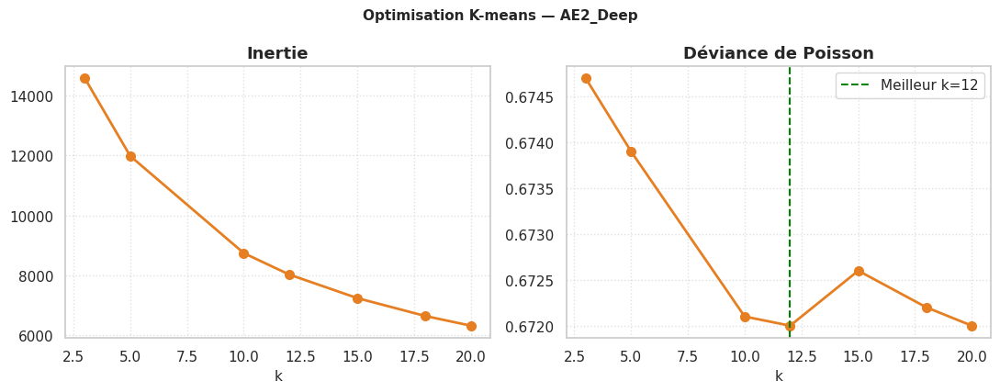

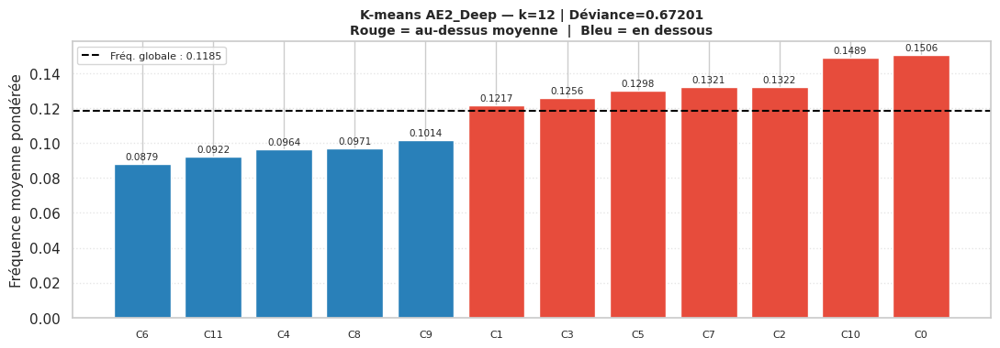


  TABLEAU CLUSTERS (AE2_Deep, k=12) :
 Cluster Classe_Age_Situ_Cont Creation_Entr Mode_gestion Zone Segment Fractionnement Age_du_vehicule    franchise Nombre_vehicule FORMULE Activite Type_Apporteur ValeurPuissance  N_obs Freq_moy     Expo
       6            2 - 3 ans             1            P    1       2              T         > 5 ans 3. 201 - 300               1       3        1              1               7   6365   0.0879  3106.62
      11              > 5 ans             1            N    1       1              T         > 5 ans   2. 1 - 200               1       3        3              1               4   9649   0.0922   3480.5
       4              > 5 ans             1            N    1       1              T         > 5 ans 3. 201 - 300               1       3        6              1               7   6283   0.0964   2106.3
       8              > 5 ans             1            N    1       1              A         > 5 ans   2. 1 - 200               1       3        6   

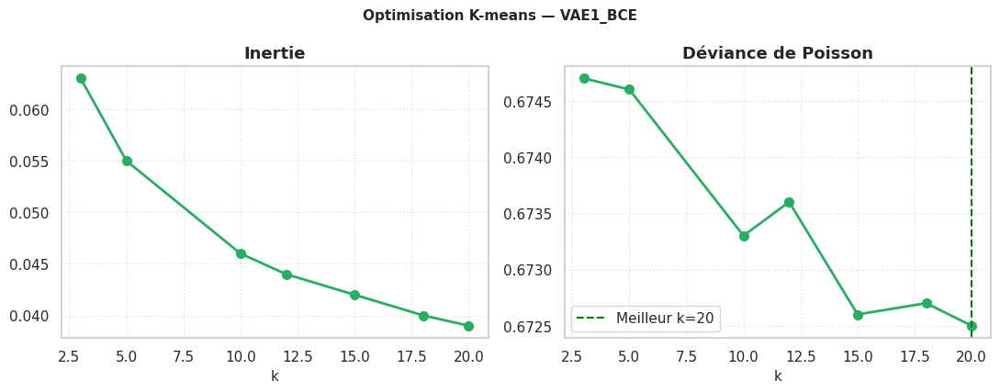

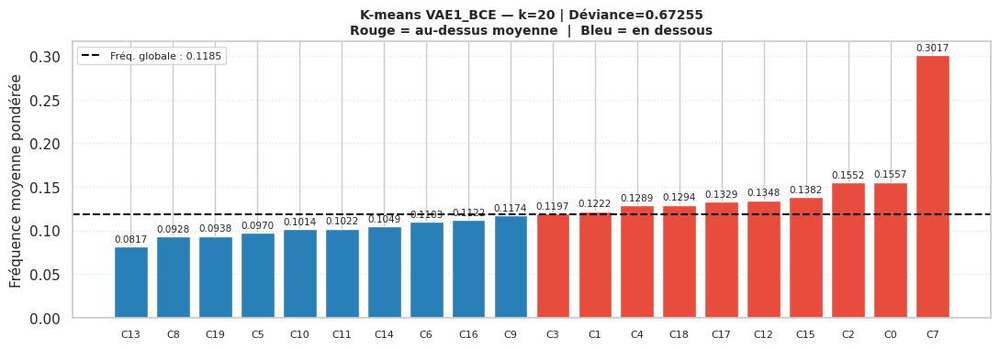


  TABLEAU CLUSTERS (VAE1_BCE, k=20) :
 Cluster Classe_Age_Situ_Cont Creation_Entr Mode_gestion Zone Segment Fractionnement Age_du_vehicule    franchise Nombre_vehicule FORMULE Activite Type_Apporteur ValeurPuissance  N_obs Freq_moy     Expo
      13             <= 1 ans             1            P    2       1              T        <= 5 ans   2. 1 - 200               1       4        1              3               7   1951   0.0817  1125.66
       8            2 - 3 ans             2            P    2       1              S         > 5 ans 5. 401 - 600               1       5        1              1               8   1797   0.0928  1087.98
      19            4 - 5 ans             2            P    3       2              S        <= 5 ans   2. 1 - 200               1       4        1              1               4   3365   0.0938  2250.27
       5            1 - 2 ans             1            N    1       1              T        <= 5 ans   2. 1 - 200               1       3        4   

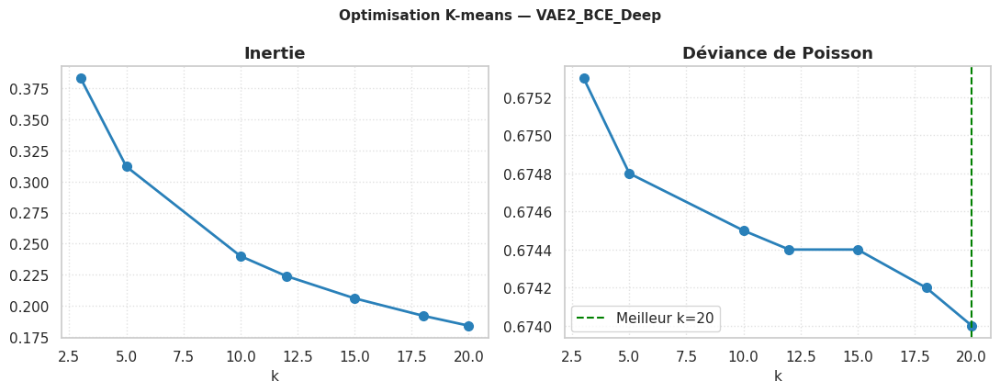

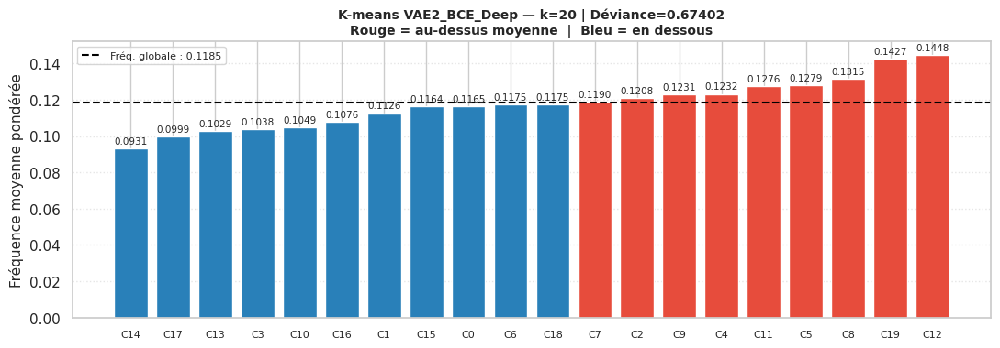


  TABLEAU CLUSTERS (VAE2_BCE_Deep, k=20) :
 Cluster Classe_Age_Situ_Cont Creation_Entr Mode_gestion Zone Segment Fractionnement Age_du_vehicule    franchise Nombre_vehicule FORMULE Activite Type_Apporteur ValeurPuissance  N_obs Freq_moy     Expo
      14              > 5 ans             1            N    3       1              A        <= 5 ans   2. 1 - 200               1       3        1              1               7   4548   0.0931  1773.02
      17            2 - 3 ans             1            P    3       1              S        <= 5 ans 3. 201 - 300               1       3        1              1               7   2202   0.0999  1221.73
      13             <= 1 ans             1            N    3       2              A        <= 5 ans   2. 1 - 200               1       3        1              1               7   3388   0.1029  1409.32
       3             <= 1 ans             1            P    3       2              T        <= 5 ans 3. 201 - 300               1       3       

In [ ]:

# ══════════════════════════════════════════════════════════════════
#  SECTION 2.2 — K-MEANS SUR L'ESPACE LATENT
#
#  Principe du cours :
#  1. Encoder toutes les obs → espace latent z (ou z_mean pour VAE)
#  2. K-means → label cluster cᵢ pour chaque obs
#  3. Pour cluster c : μ̂_c = Σ_{i∈c}(νᵢ·fᵢ) / Σ_{i∈c}(νᵢ)
#  4. Prédiction : f̂ᵢ = μ̂_{cᵢ}
#  5. Déviance sur TOUT le dataset (pas de split ici, comme dans le code)
# ══════════════════════════════════════════════════════════════════
print("\n" + "="*65)
print("  SECTION 2.2 — K-MEANS SUR L'ESPACE LATENT")
print("="*65)

compressions = {
    'AE1_Simple'   : X_comp_ae1,
    'AE2_Deep'     : X_comp_ae2,
    'VAE1_BCE'     : X_comp_vae1,
    'VAE2_BCE_Deep': X_comp_vae2,
}
print("\n  Dimensions des espaces latents :")
for n, c in compressions.items():
    print(f"    {n:<20} → shape {c.shape}")

k_values = [3,5, 10, 12,15,18, 20]


def run_kmeans_complet(X_comp, model_name, color='#2980b9'):
    """
    K-means sur l'espace latent (tout le dataset).
    μ̂_c = fréquence moyenne pondérée du cluster (calculée sur tout le dataset).
    Déviance évaluée sur tout le dataset.
    """
    print(f"\n{'='*55}")
    print(f"  K-MEANS — {model_name}")
    print(f"{'='*55}")

    results_k = []
    for k in k_values:
        km = KMeans(init='random', n_clusters=k,
                    n_init=k + 20, max_iter=300, random_state=SEED)
        km.fit(X_comp)
        lbl = km.labels_

        # Fréquence moyenne pondérée par cluster
        freq_cl = {}
        for c in range(k):
            idx_c = (lbl == c)
            if idx_c.sum() > 0:
                freq_cl[c] = np.average(
                    data['Frequence'].values[idx_c],
                    weights=data['Exposition_au_risque'].values[idx_c])
            else:
                freq_cl[c] = freq_glob_ae

        yp  = np.array([freq_cl[c] for c in lbl])
        dev = mean_poisson_deviance(
            data['Frequence'].values, yp,
            sample_weight=data['Exposition_au_risque'].values)

        results_k.append({'k': k, 'inertia': round(km.inertia_, 3),
                           'deviance': round(dev, 4)})
        print(f"  k={k:>2} | inertia={km.inertia_:>10.3f} | dev={dev:.4f}")

    rdf = pd.DataFrame(results_k).set_index('k').T
    print(f"\n  Résumé :\n{rdf.to_string()}")

    best_k = min(results_k, key=lambda r: r['deviance'])['k']
    print(f"\n  → Meilleur k = {best_k}")

    # Graphiques optimisation
    fig, axes = plt.subplots(1, 2, figsize=(28*cm, 11*cm))
    axes[0].plot(k_values, [r['inertia']  for r in results_k],
                 'o-', color=color, linewidth=2, markersize=7)
    axes[0].set_title("Inertie", fontweight='bold')
    axes[0].set_xlabel("k"); axes[0].grid(True, linestyle=':', alpha=0.6)

    axes[1].plot(k_values, [r['deviance'] for r in results_k],
                 'o-', color=color, linewidth=2, markersize=7)
    axes[1].axvline(x=best_k, color='green', linestyle='--',
                    linewidth=1.5, label=f'Meilleur k={best_k}')
    axes[1].set_title("Déviance de Poisson", fontweight='bold')
    axes[1].set_xlabel("k"); axes[1].legend()
    axes[1].grid(True, linestyle=':', alpha=0.6)

    plt.suptitle(f"Optimisation K-means — {model_name}",
                 fontsize=11, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f"kmeans_optim_{model_name}.png", dpi=150)
    plt.show()

    # K-means final avec best_k
    km_f = KMeans(init='random', n_clusters=best_k,
                  n_init=best_k + 20, max_iter=300, random_state=SEED)
    km_f.fit(X_comp)
    lbl_f = km_f.labels_

    # Tableau descriptif des clusters
    out_names = ['Cluster'] + ae_vars + ['N_obs', 'Freq_moy', 'Expo']
    out_tab   = pd.DataFrame(np.zeros((best_k, len(out_names))),
                              columns=out_names, dtype=object)

    for k in range(best_k):
        idx_c    = (lbl_f == k)
        freq_moy = np.average(data['Frequence'].values[idx_c],
                               weights=data['Exposition_au_risque'].values[idx_c])
        row = [k]
        for col in ae_vars:
            dom = Counter(data[col].astype(str).values[idx_c]).most_common(1)[0][0]
            row.append(dom)
        row += [idx_c.sum(), round(freq_moy, 4),
                round(data['Exposition_au_risque'].values[idx_c].sum(), 2)]
        out_tab.loc[k] = row

    out_tab['Cluster'] = out_tab['Cluster'].astype(int)
    out_tab['N_obs']   = out_tab['N_obs'].astype(int)
    out_tab = out_tab.sort_values('Freq_moy').reset_index(drop=True)

    # Déviance finale
    freq_map = dict(zip(out_tab['Cluster'].astype(int),
                        out_tab['Freq_moy'].astype(float)))
    yp_f     = np.array([freq_map[c] for c in lbl_f])
    dev_f    = mean_poisson_deviance(
        data['Frequence'].values, yp_f,
        sample_weight=data['Exposition_au_risque'].values)

    # Graphique fréquence par cluster
    freq_moy_vals = out_tab['Freq_moy'].astype(float)
    fig, ax = plt.subplots(figsize=(28*cm, 10*cm))
    colors_b = ['#e74c3c' if f > freq_glob_ae else '#2980b9'
                for f in freq_moy_vals]
    bars_km = ax.bar(range(best_k), freq_moy_vals,
                     color=colors_b, edgecolor='white')
    for bar, val in zip(bars_km, freq_moy_vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + freq_moy_vals.max() * 0.01,
                f"{val:.4f}", ha='center', va='bottom', fontsize=7.5)
    ax.axhline(y=freq_glob_ae, color='black', linestyle='--',
               linewidth=1.5, label=f"Fréq. globale : {freq_glob_ae:.4f}")
    ax.set_xticks(range(best_k))
    ax.set_xticklabels([f"C{int(out_tab['Cluster'].iloc[i])}"
                        for i in range(best_k)], fontsize=8)
    ax.set_title(f"K-means {model_name} — k={best_k} | Déviance={dev_f:.5f}\n"
                 "Rouge = au-dessus moyenne  |  Bleu = en dessous",
                 fontweight='bold', fontsize=10)
    ax.set_ylabel("Fréquence moyenne pondérée")
    ax.legend(fontsize=8)
    ax.yaxis.grid(True, linestyle=':', alpha=0.5)
    ax.set_axisbelow(True)
    plt.tight_layout()
    plt.savefig(f"kmeans_freq_{model_name}.png", dpi=150)
    plt.show()

    print(f"\n  TABLEAU CLUSTERS ({model_name}, k={best_k}) :")
    pd.set_option('display.max_columns', None)
    pd.set_option('display.width', 200)
    print(out_tab.to_string(index=False))

    return best_k, lbl_f, out_tab, dev_f


# Lancer K-means pour chaque modèle
colors_km     = ['#e74c3c', '#e67e22', '#27ae60', '#2980b9']
kmeans_results = {}

for (name, X_comp), col in zip(compressions.items(), colors_km):
    bk, lbl, otab, dev = run_kmeans_complet(X_comp, name, col)
    kmeans_results[name] = {'best_k': bk, 'labels': lbl,
                             'out_tab': otab, 'deviance': dev}


  SECTION 2.3 — DÉVIANCE COMPARÉE
                     Modèle  Déviance
              NN4_Tanh_L1L2  0.652969
                GLM_Poisson  0.654823
   KMeans_AE1_Simple (k=20)  0.666507
     KMeans_AE2_Deep (k=12)  0.672005
     KMeans_VAE1_BCE (k=20)  0.672547
KMeans_VAE2_BCE_Deep (k=20)  0.674022

  🏆 Meilleur modèle : NN4_Tanh_L1L2


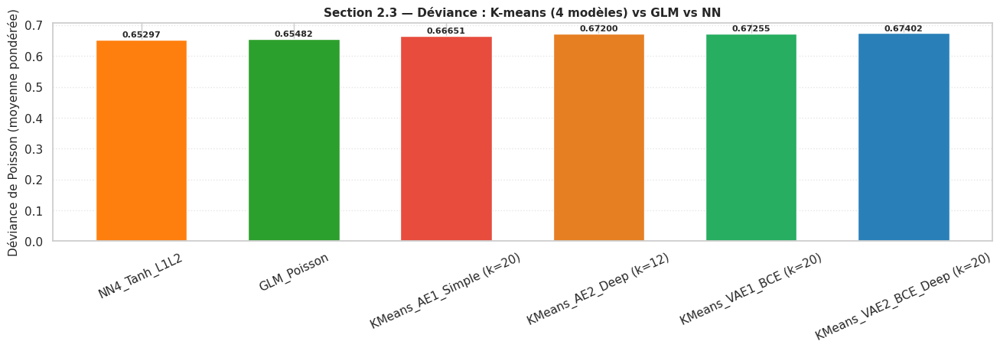


█████████████████████████████████████████████████████████████████
  RÉSUMÉ FINAL — PARTIES 1 & 2
█████████████████████████████████████████████████████████████████

  ── PARTIE 1 — GLM + NN (sur validation) ──
        Modele  Dev_Moy_Train  Dev_Moy_Val  Dev_Tot_Train  Dev_Tot_Val
 NN4_Tanh_L1L2       0.660596     0.622334   20382.902344  4781.364258
   GLM_Poisson       0.662716     0.623126   20448.292969  4787.442383
NN2_L2_Dropout       0.650113     0.625126   20059.423828  4802.813477
    NN1_Simple       0.655818     0.625436   20235.458984  4805.196777
      NN3_Deep       0.649666     0.626657   20045.634766  4814.577148

  ── PARTIE 2 — Qualité reconstruction ──
       Modèle  latent space dim  loss+ELBO  KL divergence
   AE1_Simple                10     0.2347         0.6589
     AE2_Deep                 5     0.0552         0.1478
     VAE1_BCE                10    76.4600         1.0211
VAE2_BCE_Deep                 5    76.4590         1.0211

  ── PARTIE 2 — Comparaison dé

In [ ]:
# ══════════════════════════════════════════════════════════════════
#  SECTION 2.3 — DÉVIANCE COMPARÉE
#  GLM vs Meilleur NN vs K-means (4 modèles)
#  Évaluation sur TOUT le dataset (cohérent avec K-means)
# ══════════════════════════════════════════════════════════════════
print("\n" + "="*55)
print("  SECTION 2.3 — DÉVIANCE COMPARÉE")
print("="*55)

X_all      = X_dummies.values.astype("float32")
y_obs      = data['Frequence'].values
expo_data  = data['Exposition_au_risque'].values

y_pred_glm = glm.predict(X_all)
y_pred_nn  = best_nn['model'].predict(X_all, verbose=0).ravel()
dev_glm    = mean_poisson_deviance(y_obs, y_pred_glm, sample_weight=expo_data)
dev_nn     = mean_poisson_deviance(y_obs, y_pred_nn,  sample_weight=expo_data)

rows_comp = [
    {'Modèle': 'GLM_Poisson',      'Déviance': round(dev_glm, 6)},
    {'Modèle': best_nn['Modele'],  'Déviance': round(dev_nn,  6)},
]
for name, res in kmeans_results.items():
    rows_comp.append({'Modèle': f"KMeans_{name} (k={res['best_k']})",
                      'Déviance': round(res['deviance'], 6)})

comp_df = (pd.DataFrame(rows_comp)
             .sort_values('Déviance').reset_index(drop=True))

print(comp_df.to_string(index=False))
best_model_final = comp_df.iloc[0]['Modèle']
print(f"\n  Meilleur modèle : {best_model_final}")

# Graphique comparatif final
fig, ax = plt.subplots(figsize=(34*cm, 12*cm))
palette_comp = ['#ff7f0e', '#2ca02c', '#e74c3c', '#e67e22', '#27ae60', '#2980b9']
bars_comp = ax.bar(comp_df['Modèle'], comp_df['Déviance'],
                   color=palette_comp[:len(comp_df)], edgecolor='white', width=0.6)
for bar, val in zip(bars_comp, comp_df['Déviance']):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + comp_df['Déviance'].max() * 0.005,
            f"{val:.5f}", ha='center', va='bottom', fontsize=8, fontweight='bold')
ax.set_ylabel("Déviance de Poisson (moyenne pondérée)")
ax.set_title("Section 2.3 — Déviance : K-means (4 modèles) vs GLM vs NN",
             fontweight='bold', fontsize=11)
ax.tick_params(axis='x', rotation=25)
ax.yaxis.grid(True, linestyle=':', alpha=0.5)
ax.set_axisbelow(True)
plt.tight_layout()
plt.savefig("deviance_comparee_all.png", dpi=150)
plt.show()


# ══════════════════════════════════════════════════════════════════
#  RÉSUMÉ FINAL
# ══════════════════════════════════════════════════════════════════
print("\n" + "█"*65)
print("  RÉSUMÉ FINAL — PARTIES 1 & 2")
print("█"*65)

print("\n  ── PARTIE 1 — GLM + NN (sur validation) ──")
print(summary_df.to_string(index=False))

print("\n  ── PARTIE 2 — Qualité reconstruction ──")
print(quality_df.to_string(index=False))

print("\n  ── PARTIE 2 — Comparaison déviances (tout dataset) ──")
print(comp_df.to_string(index=False))

print(f"\n  Meilleur modèle global : {best_model_final}")
print("\n  Script complet terminé ")